<a href="https://colab.research.google.com/github/ai-socialimpact/AnalyzeCommunityQuestions/blob/main/Analyze_Gliffic_Question_Log_Clustering_ver5_SNEHA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## design

Step 1: Translate the human readable questions into machine processable vectors (embeddings) for accurate clustering computations. We use SOTA embedding for accurate maping of Indic languages in questions

Step 2: Grid search simulation to find optimial Cluster based on the choosen RVI metric

Step 3: Review the simulation results and make a decision on what will be desired cluster size

Step 4: Run the clustering

Step 5: Use LLM to translate cluster into human readable format

Step 6: Generate reports

# Approach, Challenges & Solution design


## Challenges & solution:

### 1
#### problem 1: Hinglish sentances with users saying extra hello words, spell errors, different writing styles .

#### solution 1: this makes traditional appraoch prone to incorrect representation.. so we move to the best approach: Just do the best multi-lingual embedded to get the meaning of these 18000 - a one time translation  (18000 for SNEHA, 5800 QA - for Antara)


### 2
#### problem 2:  there are so many ways to cluster .. what would yeild the optimal cluster

#### solution 2:  run a 100 simulations (with GPU acceleration) in 10 minutes to find optimial clustering.  Metric : Dense enough info, but distint enough
e.g. all vaccine schedule needs to be into 1 folder, while (vaccine side-effects)  should go to another 2nd folder. [minimal over lap, so what user ask a question about fever after vaccine,  we don't misinterpret between the 2 vaccine folders]  

### 3

#### problem 3:  NGO challenge : i only have 3 days to vet a 100 FAQs. What will those 100? --> The challenge of minimal effort, max traffic coverge. What'should be in the questions that should get into this FAQ?  What are my community mostly looking for?

### solution 3:  get the top 10 clusters and thier whatsapp traffic, but we need to make it both intutive and comprehensive summary of what is inside the '"folder" "(cluster).   So we move to problem 4


### 4

#### problem 4: Make it intutive for NGO, especially if they want to see a "preview of represenative' Questions in  FAQ .  How to move from machine readable language (cluster/vector representation)  back to human readable language  ?  
##### Problem 4A.  A cluster id makes no sense for humans.  
##### Problem 4B. Reading 500 questions inside a single cluster will overwhelm the user!.
#### Problem 4C.  Understanding the scope of a cluster is also important. E.g. Where is the boundary between Vaccine Schedule vs Vaccine Side effects. So we can focus on the right micro-intents


#### solution 4: reverse canonical mapping from m/c understanble language (cluster's vector space) to  human understanble language (question space) by extracting all the 500 questions inside a cluster (thier frequency, thier diverstity) using a LLM  

### 5

#### problem 5: Now that we have identified the questions in the FAQ, how to create the answers

#### solution 5:  Using LLM Wiki and Answer consistency technique by having a team of virtual experts write the answering  to generate answers with 100 reasoning paths (100 team of experts apply different reasoning paths to get the answers, then do a auto validation). THen spot vet some of the answers by NGO experts , especially the important/senstive questions


### 7

#### problem  6: Since LLM is stateless, LLM will invent new taxonomy for every cluster. So the FAQ becomes different to read for human

#### solution 6:  Bring in a consistent domain taxonomy . Feed in the taxonomy identfied from LLM Wiki for consistent FAQ documention



In [ ]:
## The   Gliffic Question log containing 18000+ whatsapp questions from community members

#Antara
FILE_PATH = '/content/Antara Data View_LLM Usage 2026.csv'
DATA_FILE = 'Antara Data View_LLM Usage 2026.csv'

In [ ]:
#SNEHA
FILE_PATH = '/content/glific_messages_funnel.csv'
DATA_FILE = '/content/glific_messages_funnel.csv'

In [ ]:
import os
from google.colab import userdata

#GOOGLE_GEMINI_API_KEY = userdata.get('GOOGLE_GEMINI_API_KEY') #load from Secrets

#GOOGLE_GEMINI_API_KEY='xxxx'


GEMINI_API_KEY = GOOGLE_GEMINI_API_KEY



# The   Question log containing log of whatsapp questions from community members

In [ ]:
import os
import pandas as pd



print("=== INITIALISING FILE INGESTION ===")
if not os.path.exists(FILE_PATH):
    raise FileNotFoundError(f"Could not find '{FILE_PATH}'  .")

df = pd.read_csv(FILE_PATH)

=== INITIALISING FILE INGESTION ===


In [ ]:
if 'body_final_phonetic' in df.columns:
    df = df.rename(columns={'body_final_phonetic': 'question'})

In [ ]:



df = df.dropna(subset=['question'])
sentences = df['question'].astype(str).tolist()

print("\n=== DATAFRAME   ===")
print("1. Total rows  :", len(df))
print("2. Total   in sentences list:", len(sentences))

print("\n=== FIRST 2 ROWS   ===")
for idx, s in enumerate(sentences[:2]):
    print(f"Row {idx}: {s[:120]}...")



=== DATAFRAME   ===
1. Total rows  : 18044
2. Total   in sentences list: 18044

=== FIRST 2 ROWS   ===
Row 0: Aur baithane ka kab se shuru karun....
Row 1: "Main sunhin chutta mahina lagte hi bacche ko baithane ka aur usko daal ka paani aur ye vo halka-fulka kuch khilane ka k...


# this step is one-time only. Once we create the embedding, We save the embedded vectors into a int o harddisk and  re-use it 100's of simulations

## this embedding solves problem 1. (batch embedding with the SOTA Indic language embedding model)

In [ ]:
# this step is one-time only. Once we create the embedding, We save the embedded vectors into a int o harddisk and  re-use it 100's of simulations

## this embedding solves problem 1. (batch embedding with the SOTA Indic language embedding model)

In [ ]:
import numpy as np
import pandas as pd
import time
import random
from google import genai
from google.genai import types
from tqdm import tqdm
from sklearn.preprocessing import normalize

client = genai.Client(api_key=GEMINI_API_KEY)

production_df = df.copy()
#production_df = df.iloc[:453].copy()

production_sentences = production_df['question'].astype(str).tolist()
print(f"• Ingesting all {len(production_sentences)} questions for embedding.")

production_vectors = []
BATCH_SIZE = 100
global_item_counter = 0
MAX_RETRIES = 5

print("\nStreaming batch of 100 rows   to Gemini Embedding 2 .")
for idx, i in enumerate(tqdm(range(0, len(production_sentences), BATCH_SIZE))):
    time.sleep(2)
    batch_strings = production_sentences[i:i+BATCH_SIZE]


    batch_contents = [
        types.Content(parts=[types.Part.from_text(text=s)])
        for s in batch_strings
    ]

    response = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = client.models.embed_content(
                model="gemini-embedding-2",
                contents=batch_contents,
                config=types.EmbedContentConfig(output_dimensionality=3072)
            )
            break

        except Exception as e:
            if attempt == MAX_RETRIES:
                print(f"\n❌   geminmi API error at Batch Index {idx} eben after {MAX_RETRIES} retyingg attempts: {e}")
                raise e

            backoff_delay = (2 ** attempt) + random.uniform(0.1, 0.9) + 30
            print(f"\nRate-limit on Batch {idx}. Retrying  ({attempt}/{MAX_RETRIES}) in {backoff_delay:.2f} ... Error: {e}")
            time.sleep(backoff_delay)

    for k in range(len(batch_strings)):
        vector_values = response.embeddings[k].values
        production_vectors.append(vector_values)

        #  diagnostic  every 500th
        if global_item_counter % 500 == 0:
            print(f"  [Sentence {global_item_counter}/{len(production_sentences)}] \"{production_sentences[global_item_counter][:40]}...\" ──► Embedded")

        global_item_counter += 1

# normalize full matrix
normalized_embeddings = normalize(np.array(production_vectors), norm='l2')

print("\n=== FINAL VERIFIED PRODUCTION MATRIX METRICS ===")
print(f"• Calculated Vector Matrix Shape: {normalized_embeddings.shape}")
print(f"• Total Safe Cloud API Calls Made: {idx + 1} network hits")


• Ingesting all 18044 questions for embedding.

Streaming batch of 100 rows   to Gemini Embedding 2 .


  1%|          | 1/181 [00:03<10:03,  3.35s/it]

  [Sentence 0/18044] "Aur baithane ka kab se shuru karun...." ──► Embedded


  3%|▎         | 6/181 [00:19<09:28,  3.25s/it]

  [Sentence 500/18044] "Yojana ki jaankaari..." ──► Embedded


...

 97%|█████████▋| 176/181 [09:26<00:15,  3.11s/it]

  [Sentence 17500/18044] "riport mein bacche ka video karna ya hai..." ──► Embedded


100%|██████████| 181/181 [09:43<00:00,  3.22s/it]

  [Sentence 18000/18044] "Ismen didi bolo kya karun iska hal batao..." ──► Embedded



=== FINAL VERIFIED PRODUCTION MATRIX METRICS ===
• Calculated Vector Matrix Shape: (18044, 3072)
• Total Safe Cloud API Calls Made: 181 network hits


In [ ]:
import numpy as np

# 1. Save the    matrix
matrix_filename = "whatsapp_18k_gemini_embeddings.npy"
np.save(matrix_filename, normalized_embeddings)

print(f"🎉 Success! T matrix is  saved as '{matrix_filename}'")


🎉 Success! T matrix is  saved as 'whatsapp_18k_gemini_embeddings.npy'


#  A simple Table of Contents will do .

Here we download it - If this is not available for other NGOs, no worries , it can be human typed simple text paragraph  on the likely list of topics in the KB  . The SimpleIndex.md is more formal version, but a simple human typed list of topics version is enough.

In [ ]:
!wget https://github.com/ai-socialimpact/LLMWiki-NGO-Humaninloop/blob/main/WikiContents/WikiContentVersions/WikiSimpleVer3/SimpleIndex.md

--2026-10-07 08:31:11--  https://github.com/ai-socialimpact/LLMWiki-NGO-Humaninloop/blob/main/WikiContents/WikiContentVersions/WikiSimpleVer3/SimpleIndex.md
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘SimpleIndex.md’

SimpleIndex.md          [  <=>               ] 251.73K  1.01MB/s    in 0.2s    

2026-10-07 08:31:12 (1.01 MB/s) - ‘SimpleIndex.md’ saved [257774]



In [ ]:
!wget https://github.com/ai-socialimpact/LLMWiki-NGO-Humaninloop/blob/main/WikiContents/WikiContentVersions/WikiVer2/index_stage_routing_protocol.md

--2026-10-07 08:31:12--  https://github.com/ai-socialimpact/LLMWiki-NGO-Humaninloop/blob/main/WikiContents/WikiContentVersions/WikiVer2/index_stage_routing_protocol.md
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘index_stage_routing_protocol.md’

index_stage_routing     [  <=>               ] 291.76K  1.17MB/s    in 0.2s    

2026-10-07 08:31:13 (1.17 MB/s) - ‘index_stage_routing_protocol.md’ saved [298762]



In [ ]:
import os
import pandas as pd

# 1. Configuration Check for Source Files
ROUTER_FILE = "index_stage_routing_protocol.md"
#DATA_FILE = "glific_messages_funnel.csv"

print("=== CELL 1: INITIALISING STORAGE STREAM LAYER ===")

if not os.path.exists(ROUTER_FILE):
    raise FileNotFoundError(f"Could not locate '{ROUTER_FILE}'. Please upload it to your Colab sidebar.")

if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(f"Could not locate '{DATA_FILE}'. Please upload your source data CSV.")

# 2. Read Routing Protocol Text into Memory
with open(ROUTER_FILE, "r", encoding="utf-8") as f:
    VARIANT_2_ROUTING_INDEX = f.read()

# 3. Read Core DataFrame (Failsafe fallback)
df = pd.read_csv(DATA_FILE)

if 'body_final_phonetic' in df.columns:
    df = df.rename(columns={'body_final_phonetic': 'question'})

df = df.dropna(subset=['question'])

print(f"✓ '{ROUTER_FILE}' streamed   (Size: {len(VARIANT_2_ROUTING_INDEX):,} characters)")
print(f"✓ '{DATA_FILE}' loaded . (Size: {len(df):,} messages)")


=== CELL 1: INITIALISING STORAGE STREAM LAYER ===
✓ 'index_stage_routing_protocol.md' streamed   (Size: 298,751 characters)
✓ '/content/glific_messages_funnel.csv' loaded . (Size: 18,044 messages)


# Run multiple clusturing simulations on GPU to find the best one.

##Best one are based on RVI score

## Use configurable INPUT: THe grid search

In [ ]:
# Search grid parameters mapping configuration
grid_components = [5, 8, 12, 15]
grid_neighbors = [8, 12, 15]

TARGET_MIN_CLUSTER = 8
TARGET_MIN_SAMPLES = 4

## the simulation based on the suggested grid  

In [ ]:
import time
import pandas as pd
import numpy as np
import hdbscan

#  HIGH-PERFORMANCE GPU  ACCELERATION LINK
try:
    from cuml.manifold import UMAP as cuUMAP
    print("🚀  Accelerated GPU   Active! Offloading to VRAM Cores...")
    use_gpu = True
except ImportError:
    import umap
    print("⚠️ GPU cuML RAPIDS not detected in cell cache.  Try CPU...")
    use_gpu = False

print("=== grid seasrch ===")



tuning_records = []
total_runs = len(grid_components) * len(grid_neighbors)
run_counter = 1

print(f"• Total configurations to benchmark: {total_runs} iterations.")
print(f"• Target  Baseline : min_cluster_size={TARGET_MIN_CLUSTER} | min_samples={TARGET_MIN_SAMPLES}")
print("• Optimization Metric Engine: Relative Validity Index (RVI) [Higher is Better]\n")

for comp in grid_components:
    for neigh in grid_neighbors:
        start_time = time.time()

        if use_gpu:
            reducer = cuUMAP(
                n_neighbors=neigh,
                n_components=comp,
                metric='cosine',
                random_state=42
            )
            embeddings_projected = reducer.fit_transform(normalized_embeddings)
        else:
            reducer = umap.UMAP(
                n_neighbors=neigh,
                n_components=comp,
                metric='cosine',
                random_state=42,
                n_jobs=-1
            )
            embeddings_projected = reducer.fit_transform(normalized_embeddings)

        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=TARGET_MIN_CLUSTER,
            min_samples=TARGET_MIN_SAMPLES,
            metric='euclidean',
            cluster_selection_method='eom',
            gen_min_span_tree=True,
            prediction_data=True
        )
        labels = clusterer.fit_predict(embeddings_projected)

        # 3. Extract topological validity scores e
        discovered_clusters = len(np.unique(labels)) - (1 if -1 in labels else 0)
        noise_count = np.sum(labels == -1)
        noise_pct = (noise_count / len(labels)) * 100

        try:
            rvi_score = clusterer.relative_validity_
        except Exception as e:
            rvi_score = -1.0

        elapsed_time = time.time() - start_time

        print(f"[{run_counter}/{total_runs}] Space Depth: {comp}D | Neighbors: {neigh} ──► Discovered: {discovered_clusters} FAQs | Noise: {noise_pct:.1f}% | True RVI Score: {rvi_score:.4f} | Time: {elapsed_time:.1f}s")

        tuning_records.append({
            "UMAP_Components": comp,
            "UMAP_Neighbors": neigh,
            "Total_Clusters_Found": discovered_clusters,
            "Noise_Percentage": noise_pct,
            "Optimization_RVI_Score": rvi_score
        })
        run_counter += 1

# 4.  RANK RESULTS
tuning_results_df = pd.DataFrame(tuning_records)
tuning_results_df = tuning_results_df.sort_values(by='Optimization_RVI_Score', ascending=False).reset_index(drop=True)

print("\n" + "="*75)
print("🏆 WINNING MICRO-INTENT CLUSTERING CONFIGURATION")
print("="*75)
winner = tuning_results_df.iloc[0]
print(f" • Winner UMAP Target Dimensions : {int(winner['UMAP_Components'])}D")
print(f" • Winner UMAP View Lens Neighbors: {int(winner['UMAP_Neighbors'])}")
print(f" • Maximum Micro-Intents Isolated : {int(winner['Total_Clusters_Found'])} separate FAQ entries")
print(f" • Optimal Topology RVI Score    : {winner['Optimization_RVI_Score']:.4f}")
print(f" • Noise Verification Percentage  : {winner['Noise_Percentage']:.2f}%")
print("="*75)


🚀  Accelerated GPU   Active! Offloading to VRAM Cores...
=== grid seasrch ===
• Total configurations to benchmark: 12 iterations.
• Target  Baseline : min_cluster_size=8 | min_samples=4
• Optimization Metric Engine: Relative Validity Index (RVI) [Higher is Better]

[1/12] Space Depth: 5D | Neighbors: 8 ──► Discovered: 468 FAQs | Noise: 25.1% | True RVI Score: 0.2763 | Time: 7.6s
[2/12] Space Depth: 5D | Neighbors: 12 ──► Discovered: 411 FAQs | Noise: 26.8% | True RVI Score: 0.2834 | Time: 5.0s
[3/12] Space Depth: 5D | Neighbors: 15 ──► Discovered: 352 FAQs | Noise: 25.8% | True RVI Score: 0.3131 | Time: 5.3s
[4/12] Space Depth: 8D | Neighbors: 8 ──► Discovered: 470 FAQs | Noise: 25.5% | True RVI Score: 0.3021 | Time: 3.1s
[5/12] Space Depth: 8D | Neighbors: 12 ──► Discovered: 401 FAQs | Noise: 25.5% | True RVI Score: 0.2960 | Time: 5.0s
[6/12] Space Depth: 8D | Neighbors: 15 ──► Discovered: 349 FAQs | Noise: 25.5% | True RVI Score: 0.3020 | Time: 3.3s
[7/12] Space Depth: 12D | Neighbor

# Manual intervention : Choose the best 1 or 2 cluster configurations .


##See above for RVI score for the best ones

In [ ]:

BEST_n_components = int(winner['UMAP_Components'])
BEST_n_neighbors = int(winner['UMAP_Neighbors'])
BEST_min_cluster_size = TARGET_MIN_CLUSTER
BEST_min_samples =  TARGET_MIN_SAMPLES

In [ ]:
import pandas as pd
import numpy as np
import hdbscan


# Dynamically target your accelerated hardware layer to lock coordinates
try:
    from cuml.manifold import UMAP as cuUMAP
    # Enforced the winning configuration: 30 Neighbors | 25 Dimensions
    reducer_production = cuUMAP(n_neighbors=BEST_n_neighbors, n_components=BEST_n_components, metric='cosine', random_state=42)
    print("🚀 Compressing rows into the winning  space via GPU Accel...")
except ImportError:
    import umap
    # Enforced the winning configuration: 30 Neighbors | 25 Dimensions
    reducer_production = umap.UMAP(n_neighbors=30, n_components=25, metric='cosine', random_state=42, n_jobs=-1)
    print("⚠️ Compressing rows into the winning  space via CPU Multi-threading...")

# 1. Project the full matrix into the winning 25D intent manifold
umap_embeddings_production = reducer_production.fit_transform(normalized_embeddings)

# 2. Run the definitive strategic macro-intent cluster scan
# Enforced the winning floor: min_cluster_size=20 | min_samples=5
clusterer_production = hdbscan.HDBSCAN(
    min_cluster_size=BEST_min_cluster_size,
    min_samples=BEST_min_samples,
    metric='euclidean',
    cluster_selection_method='eom',
    gen_min_span_tree=True
)
df['cluster_id'] = clusterer_production.fit_predict(umap_embeddings_production)

# 3. Final Production Matrix Lock Metrics Panel
total_production_clusters = df['cluster_id'].nunique() - (1 if -1 in df['cluster_id'].values else 0)
noise_production_count = len(df[df['cluster_id'] == -1])
noise_production_pct = (noise_production_count / len(df)) * 100

print("\n" + "="*60)
print("🎯 MACRO-INTENT MASTER COORDINATE METRICS LOCKED")
print("="*60)
print(f"• Total Strategic Themes Discovered  : {total_production_clusters} categories")
print(f"• System Noise Filtered Out         : {noise_production_count:,} rows ({noise_production_pct:.2f}%)")
print(f"• Mathematical Validation RVI Score  : {clusterer_production.relative_validity_:.4f}")
print("="*60)

print("\n📊 NEW TOP 5 LARGEST THEMATIC CLUSTERS (BY MENTION VOLUME):")
print(df[df['cluster_id'] != -1]['cluster_id'].value_counts().head(5))


🚀 Compressing rows into the winning 25D space via GPU Accel...

🎯 MACRO-INTENT MASTER COORDINATE METRICS LOCKED
• Total Strategic Themes Discovered  : 352 categories
• System Noise Filtered Out         : 4,659 rows (25.82%)
• Mathematical Validation RVI Score  : 0.3131

📊 NEW TOP 5 LARGEST THEMATIC CLUSTERS (BY MENTION VOLUME):
cluster_id
34     467
55     435
172    331
119    266
86     245
Name: count, dtype: int64


# Based on RVI scores from grid search , second best solution

In [ ]:
import pandas as pd
import numpy as np
import hdbscan

if False:

  try:
      from cuml.manifold import UMAP as cuUMAP
      reducer_production = cuUMAP(n_neighbors=12, n_components=8, metric='cosine', random_state=42)
      print("🚀 Compressing 18,044  Antara Gliffic question funnel  rows into the winning 8D map...")
  except ImportError:
      import umap
      reducer_production = umap.UMAP(n_neighbors=12, n_components=8, metric='cosine', random_state=42, n_jobs=-1)
      print(" CPU Multi-threading...")

  # 1. Project the  matrix into the  8D mapp
  umap_embeddings_production = reducer_production.fit_transform(normalized_embeddings)

  # 2. Run    micro-intent cluster scan
  clusterer_production = hdbscan.HDBSCAN(
      min_cluster_size=8,
      min_samples=4,
      metric='euclidean',
      cluster_selection_method='eom',
      gen_min_span_tree=True
  )
  df['cluster_id'] = clusterer_production.fit_predict(umap_embeddings_production)

  # 3.  Matrix  Metrics
  total_production_clusters = df['cluster_id'].nunique() - (1 if -1 in df['cluster_id'].values else 0)
  noise_production_count = len(df[df['cluster_id'] == -1])
  noise_production_pct = (noise_production_count / len(df)) * 100

  print("\n" + "="*60)
  print("🎯 MICRO-INTENT MASTER COORDINATE METRICS LOCKED")
  print("="*60)
  print(f"• Total Fine-Grained FAQs Discovered : {total_production_clusters} micro-chapters")
  print(f"• System Noise Filtered Out         : {noise_production_count:,} rows ({noise_production_pct:.2f}%)")
  print(f"• Mathematical Validation RVI Score  : {clusterer_production.relative_validity_:.4f}")
  print("="*60)

  print("\n📊 NEW TOP 5 LARGEST MICRO-INTENT CLUSTERS (BY MENTION VOLUME):")
  print(df[df['cluster_id'] != -1]['cluster_id'].value_counts().head(5))


🚀 Compressing 18,044  SNEHA Gliffic question funnel  rows into the winning 8D map...

🎯 MICRO-INTENT MASTER COORDINATE METRICS LOCKED
• Total Fine-Grained FAQs Discovered : 168 micro-chapters
• System Noise Filtered Out         : 1,065 rows (18.11%)
• Mathematical Validation RVI Score  : 0.3695

📊 NEW TOP 5 LARGEST MICRO-INTENT CLUSTERS (BY MENTION VOLUME):
cluster_id
0      433
1      269
7      169
4       80
107     79
Name: count, dtype: int64


# solve the problem 4 (make it intuttive ),

### but we need the right inputs to LLM (garbge n , garbage out).. lets gather the right input from cluster , so that can feed it to LLM

In [ ]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist

print(" right input foir llm ===")

def build_cluster_context_payload(df_master, normalized_matrix, cluster_id, max_tier1=200, max_tier2=100):
    """
    geometric distance calculations to pull
    1. heavy volume repeaters - based on how many gliffic users asked this .
    2. diversity gliffic question in a cluster
    """

    cluster_indices = df_master[df_master['cluster_id'] == cluster_id].index.tolist()
    cluster_embeddings = normalized_matrix[cluster_indices]
    cluster_df_slice = df_master.loc[cluster_indices].copy()
    string_counts_loop = cluster_df_slice['question'].value_counts()
    cluster_volume = len(cluster_df_slice)

    # 2.   the  centroid vector of this cluster
    topic_centroid = np.mean(cluster_embeddings, axis=0).reshape(1, -1)

    # 3.   repeating strings from long-tail   (Count == 1)
    unique_phrases = string_counts_loop[string_counts_loop == 1].index.tolist()
    unique_indices = cluster_df_slice[cluster_df_slice['question'].isin(unique_phrases)].index.tolist()

    #  if a cluster is hyper-dense and contains zero unique queries
    if len(unique_indices) == 0:
        selected_diversity_phrases = string_counts_loop.tail(max_tier2).index.tolist()
    else:
        unique_embeddings = normalized_matrix[unique_indices]
        unique_texts = cluster_df_slice.loc[unique_indices, 'question'].tolist()

        # ---  find DIVERSITY of questions  ---
        selected_diversity_phrases = []
        remaining_embeddings = list(unique_embeddings)
        remaining_texts = list(unique_texts)

        distances_to_centroid = cdist(topic_centroid, unique_embeddings, metric='cosine')
        first_pick_idx = np.argmax(distances_to_centroid)
        selected_diversity_phrases.append(remaining_texts.pop(first_pick_idx))
        current_selected_vectors = [remaining_embeddings.pop(first_pick_idx)]


        while len(selected_diversity_phrases) < max_tier2 and len(remaining_texts) > 0:
            dist_matrix = cdist(remaining_embeddings, current_selected_vectors, metric='cosine')
            min_distances_to_pool = np.min(dist_matrix, axis=1)
            next_pick_idx = np.argmax(min_distances_to_pool)
            selected_diversity_phrases.append(remaining_texts.pop(next_pick_idx))
            current_selected_vectors.append(remaining_embeddings.pop(next_pick_idx))

    tier_1_payload = [f"Count: {count} | {phrase}" for phrase, count in string_counts_loop[string_counts_loop >= 2].head(max_tier1).items()]
    tier_2_payload = [f"Count: {int(string_counts_loop[phrase])} | {phrase}" for phrase in selected_diversity_phrases]

    return tier_1_payload, tier_2_payload, cluster_volume

# =====================================================================
# 🧪 UNIT TEST  :
# =====================================================================
# Isolate active macro-clusters from the newly optimized 419-space (ignoring background noise -1)
valid_clusters_df = df[df['cluster_id'] != -1]
cluster_counts = valid_clusters_df['cluster_id'].value_counts()
top_macro_clusters = cluster_counts.index.tolist()

print("\n" + "🔬 " * 20 + "STARTING MANUAL HARNESS UNIT TEST" + " 🔬" * 20)
for idx, cid in enumerate(top_macro_clusters[:2], 1):
    t1, t2, vol = build_cluster_context_payload(df, normalized_embeddings, cid)

    print(f"\n📌 UNIT TEST HARNESS [STEP {idx}/2] ──► Target Cluster ID: #{cid} | Total Volume: {vol} rows")
    print("-" * 100)
    # Truncate strings to match the required visual inspection constraint rules
    print(f"📦 TIER_1_FREQUENCY (Top 2 lines, truncated): {[x[:100] for x in t1[:2]]}")
    print(f"📦 TIER_2_DIVERSITY (Top 2 lines, truncated): {[x[:100] for x in t2[:2]]}")
    print(f"✓ Local structural compilation verified for Cluster #{cid}.")

print("\n" + "=" * 90)
print("✅ UNIT TEST SUCCESSFUL: Payload factory engine operates flawlessly at zero API cost!")
print("=" * 90)


 right input foir llm ===

🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 STARTING MANUAL HARNESS UNIT TEST 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬

📌 UNIT TEST HARNESS [STEP 1/2] ──► Target Cluster ID: #34 | Total Volume: 467 rows
----------------------------------------------------------------------------------------------------
📦 TIER_1_FREQUENCY (Top 2 lines, truncated): ['Count: 6 | Mera baby six month ka hua hai abhi usko 3:30 mahine ka sui lagaya hai 3 din ho gaya hai ', 'Count: 3 | Jahan per sui mare Na vahin per guard jaisa hua Hai Baki aur kuchh nahin']
📦 TIER_2_DIVERSITY (Top 2 lines, truncated): ['Count: 1 | Injection le hu', 'Count: 1 | Opv 2 kya hai']
✓ Local structural compilation verified for Cluster #34.

📌 UNIT TEST HARNESS [STEP 2/2] ──► Target Cluster ID: #55 | Total Volume: 435 rows
----------------------------------------------------------------------------------------------------
📦 TIER_1_FREQUENCY (Top 2 lines, truncated): ['Count: 3 | Ismen khun kitna hai?', 'Count: 3

In [ ]:
build_cluster_context_payload(df, normalized_embeddings, cluster_id = 44 , max_tier1=10, max_tier2=5)

(['Count: 2 | Sex ke bare me', 'Count: 2 | Sex during pregnancy'],
 ['Count: 1 | Abhi hamare jaise wife ko',
  'Count: 1 | Kya saathve mahine ke pregnancy mein sex kar sakte hain Hindi mein batayen?',
  'Count: 1 | Dono rilasun Mana saktey hai',
  'Count: 1 | Isneha didi pati se gutka churavane ka koi tarika batao?',
  'Count: 1 | Agar sex ka feeling ho, main abhi beeda hoon.'],
 106)

# plot

In [ ]:
import plotly.graph_objects as go
import numpy as np
import pandas as pd

print("= find the hill =")

def generate_3d_skyline_plot(df_master, top_n_slots=40):
    """
       plot from the active cluster_id  .
    The Y-Axis explicitly maps the  gliffic traffic size volume of each discovered micro-intent topic.
    """

    valid_df = df_master[df_master['cluster_id'] != -1]
    cluster_counts = valid_df['cluster_id'].value_counts()

    top_cids = cluster_counts.head(top_n_slots).index.tolist()
    total_raw_rows = len(df_master)

    grid_cols = 5
    grid_rows = int(np.ceil(top_n_slots / grid_cols))

    x_coords = []
    z_coords = []
    for r in range(grid_rows):
        for c in range(grid_cols):
            x_coords.append(c * 2)
            z_coords.append(r * 2)

    fig = go.Figure()
    print(f"Building 3D box  the top {top_n_slots} micro-intent channels...")

    for idx, cid in enumerate(top_cids):
        if idx >= len(x_coords):
            break
        x = x_coords[idx]
        z = z_coords[idx]

        h = int(cluster_counts[cid])
        pct_share = (h / total_raw_rows) * 100

        sample_phrase = df_master[df_master['cluster_id'] == cid]['question'].iloc[0]
        if len(sample_phrase) > 45:
            sample_phrase = sample_phrase[:45] + "..."

        hover_text = (
            f"<b>Chapter Slot {idx+1} (Cluster ID: {cid})</b><br>"
            f"📊 Traffic Volume Size (Y-Axis): {h} inquiries<br>"
            f"📈 Channel Share Proportions   : {pct_share:.2f}% traffic<br>"
            f"🗣️ Raw Sample Vector Snippet   : '{sample_phrase}'"
        )

        box_color = f"rgb({int(31 + (idx*2.5))}, {int(119 + (idx*1.5))}, {int(180 + (idx*0.8))})"

        fig.add_trace(go.Mesh3d(
            x=[x-0.6, x+0.6, x+0.6, x-0.6, x-0.6, x+0.6, x+0.6, x-0.6],
            y=[0, 0, h, h, 0, 0, h, h],
            z=[z-0.6, z-0.6, z-0.6, z-0.6, z+0.6, z+0.6, z+0.6, z+0.6],
            i=[7, 0, 0, 0, 4, 4, 2, 6, 4, 0, 3, 7],
            j=[3, 4, 1, 2, 5, 6, 5, 2, 0, 1, 6, 3],
            k=[0, 7, 2, 3, 6, 7, 1, 1, 5, 5, 7, 4],
            color=box_color,
            opacity=0.95,
            hoverinfo="text",
            text=hover_text,
            name=f"Slot {idx+1}"
        ))

    fig.update_layout(
        title=f' Gliffic WhatsApp Traffic Across Top {top_n_slots} Micro-Intents',
        title_font=dict(size=18, family="Arial, sans-serif", color="white"),
        template="plotly_dark",
        width=1300,
        height=850,
        scene=dict(
            xaxis=dict(showticklabels=False, title='', showgrid=False, zeroline=False),
            yaxis=dict(title='Traffic Mention Volume (Y-AXIS HEIGHT)', titlefont=dict(size=12, color='#00ffcc'), showgrid=True),
            zaxis=dict(showticklabels=False, title='', showgrid=False, zeroline=False),
            camera=dict(eye=dict(x=1.8, y=1.5, z=1.5)) # Corporate boardroom 45-degree angle view lens
        ),
        showlegend=False
    )
    return fig

# =====================================================================
# unit test
# =====================================================================
interactive_skyline_fig = generate_3d_skyline_plot(df, top_n_slots=15)
interactive_skyline_fig.show()


= find the hill =
Building 3D box  the top 15 micro-intent channels...


In [ ]:
import numpy as np
import pandas as pd

print("=== CELL 4.6: GENERATING TWO-SCENARIO EXECUTIVE WORKLOAD MATRIX ===")

def calculate_executive_scenarios(df_master, scenario_a_count=5, scenario_b_count=30):
    """
    Analyzes active cluster distributions to dynamically output a 10-row matrix
    and explicitly prints out the two executive project options in plain English.
    """
    total_raw_rows = len(df_master)

    # Isolate genuine medical queries (ignoring background noise -1)
    valid_medical_df = df_master[df_master['cluster_id'] != -1]
    total_clean_medical_queries = len(valid_medical_df)

    # Extract ranked volume metrics in descending order
    cluster_volumes = valid_medical_df['cluster_id'].value_counts()
    total_discovered_chapters = len(cluster_volumes)

    # Standard 10-step milestones for the planning grid table
    milestone_steps = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
    matrix_records = []

    for step in milestone_steps:
        cumulative_mentions = int(cluster_volumes.head(step).sum())
        global_raw_coverage = (cumulative_mentions / total_raw_rows) * 100
        clinical_deflection_rate = (cumulative_mentions / total_clean_medical_queries) * 100

        if step <= 10:
            rec_tag = "Minimal Baseline (Misses long-tail anxieties)"
        elif step <= 30:
            rec_tag = "Highly Optimized (Strongest return for understaffed NGO)"
        else:
            rec_tag = "Maximum Coverage (Extremely heavy copywriting workload)"

        matrix_records.append({
            "Top_Chapters_Included": f"Top {step} Chapters",
            "Inquiries_Resolved": cumulative_mentions,
            "Global_Channel_Traffic_Share": f"{global_raw_coverage:.2f}%",
            "Clinical_Deflection_Accuracy": f"{clinical_deflection_rate:.2f}% 🔥",
            "NGO_Committee_Writing_Workload": f"Write {step} Answers",
            "Strategic_Recommendation_Matrix": rec_tag
        })

    decision_matrix_df = pd.DataFrame(matrix_records)

    # --- DYNAMIC SCENARIO CALCULATION FOR PLAIN-TEXT STRINGS ---
    # Scenario A
    vol_a = int(cluster_volumes.head(scenario_a_count).sum())
    pct_a = (vol_a / total_raw_rows) * 100

    # Scenario B
    vol_b = int(cluster_volumes.head(scenario_b_count).sum())
    pct_b = (vol_b / total_raw_rows) * 100

    # =====================================================================
    # 🗣️ THE REQUESTED STRATEGIC EXECUTIVE PRINT BLOCK
    # =====================================================================
    print("\n" + "📢 " * 15 + "EXECUTIVE BLUEPRINT ROADMAP SCENARIOS" + " 📢" * 15)
    print("-" * 105)
    print(f"🔹 SCENARIO A: If you do {scenario_a_count} books, then {pct_a:.2f}% of traffic can be routed there.")
    print(f"               (Requires writing only {scenario_a_count} answers; covers core fundamentals like basic newborn shots).")
    print("-" * 105)
    print(f"🔸 SCENARIO B: If you do {scenario_b_count} books, then {pct_b:.2f}% of traffic can be routed there.")
    print(f"               (Requires writing {scenario_b_count} answers; provides an optimized automated vector search shield).")
    print("-" * 105 + "\n")

    print(f"📊 RAW DATA STATISTICS:")
    print(f" • Total Channels Logs Ingested    : {total_raw_rows:,} rows")
    print(f" • Active Micro-Intents Isolated   : {total_discovered_chapters} distinct FAQ entries\n")

    return decision_matrix_df

# =====================================================================
# EXECUTE CORE RUNNER PASS
# =====================================================================
executive_table_df = calculate_executive_scenarios(df, scenario_a_count=5, scenario_b_count=30)
display(executive_table_df)


=== CELL 4.6: GENERATING TWO-SCENARIO EXECUTIVE WORKLOAD MATRIX ===

📢 📢 📢 📢 📢 📢 📢 📢 📢 📢 📢 📢 📢 📢 📢 EXECUTIVE BLUEPRINT ROADMAP SCENARIOS 📢 📢 📢 📢 📢 📢 📢 📢 📢 📢 📢 📢 📢 📢 📢
---------------------------------------------------------------------------------------------------------
🔹 SCENARIO A: If you do 5 books, then 9.67% of traffic can be routed there.
               (Requires writing only 5 answers; covers core fundamentals like basic newborn shots).
---------------------------------------------------------------------------------------------------------
🔸 SCENARIO B: If you do 30 books, then 29.08% of traffic can be routed there.
               (Requires writing 30 answers; provides an optimized automated vector search shield).
---------------------------------------------------------------------------------------------------------

📊 RAW DATA STATISTICS:
 • Total Channels Logs Ingested    : 18,044 rows
 • Active Micro-Intents Isolated   : 352 distinct FAQ entries



,Top_Chapters_Included,Inquiries_Resolved,Global_Channel_Traffic_Share,Clinical_Deflection_Accuracy,NGO_Committee_Writing_Workload,Strategic_Recommendation_Matrix
0,Top 5 Chapters,1744,9.67%,13.03% 🔥,Write 5 Answers,Minimal Baseline (Misses long-tail anxieties)
1,Top 10 Chapters,2828,15.67%,21.13% 🔥,Write 10 Answers,Minimal Baseline (Misses long-tail anxieties)
2,Top 15 Chapters,3579,19.83%,26.74% 🔥,Write 15 Answers,Highly Optimized (Strongest return for underst...
3,Top 20 Chapters,4222,23.40%,31.54% 🔥,Write 20 Answers,Highly Optimized (Strongest return for underst...
4,Top 25 Chapters,4772,26.45%,35.65% 🔥,Write 25 Answers,Highly Optimized (Strongest return for underst...
5,Top 30 Chapters,5248,29.08%,39.21% 🔥,Write 30 Answers,Highly Optimized (Strongest return for underst...
6,Top 35 Chapters,5660,31.37%,42.29% 🔥,Write 35 Answers,Maximum Coverage (Extremely heavy copywriting ...
7,Top 40 Chapters,6026,33.40%,45.02% 🔥,Write 40 Answers,Maximum Coverage (Extremely heavy copywriting ...
8,Top 45 Chapters,6365,35.27%,47.55% 🔥,Write 45 Answers,Maximum Coverage (Extremely heavy copywriting ...
9,Top 50 Chapters,6671,36.97%,49.84% 🔥,Write 50 Answers,Maximum Coverage (Extremely heavy copywriting ...


=== CELL 4.7: GENERATING DYNAMIC PARETO DISTRIBUTION CURVE ===


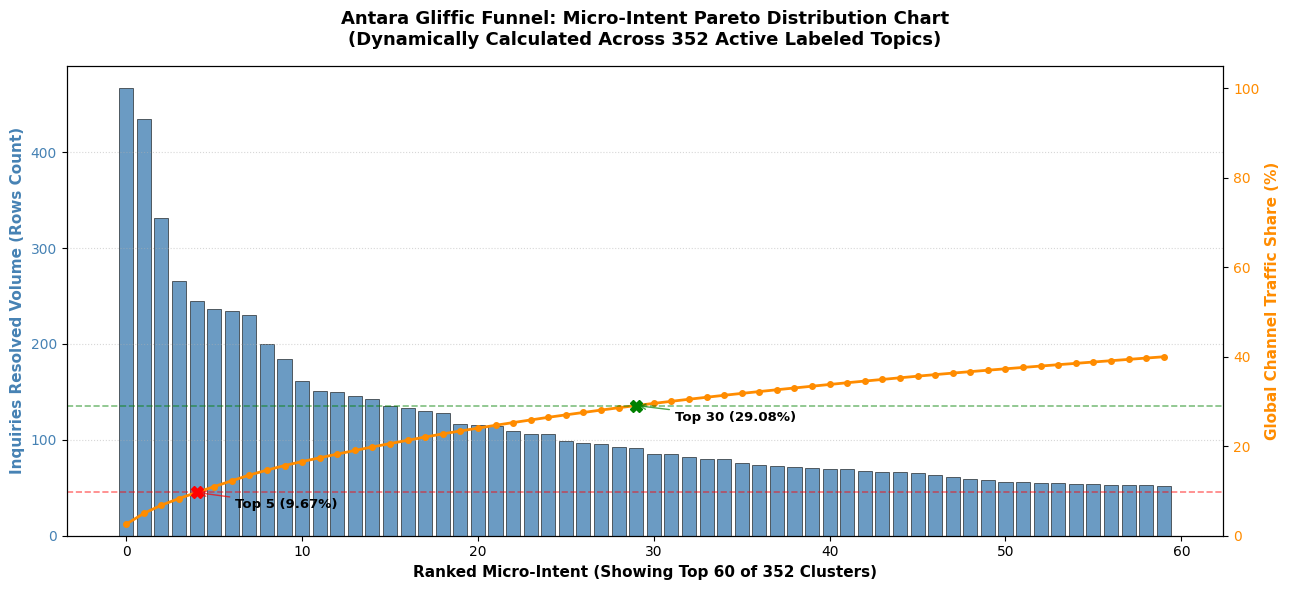

---------------------------------------------------------------------------
✅ Visualization Complete. State preserved for downstream tasks.
📊 Verified Main Matrix Length: 18044 rows | Labeled Clusters: 352
---------------------------------------------------------------------------


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=== CELL 4.7: GENERATING DYNAMIC PARETO DISTRIBUTION CURVE ===")

# 1. Create an isolated copy of cluster value counts to prevent mutation of 'df'
# We extract all rows to correctly baseline cumulative total global traffic share
cluster_counts = df['cluster_id'].value_counts()

# Separate medical intents from background noise (-1) safely
clean_clusters = cluster_counts.drop(index=-1, errors='ignore')

# 2. Build local metrics tracking dataframe
df_pareto_live = pd.DataFrame({
    'Cluster_ID': clean_clusters.index,
    'Inquiries_Resolved': clean_clusters.values
}).sort_values(by='Inquiries_Resolved', ascending=False).reset_index(drop=True)

# Calculate running totals relative to the global data baseline length
total_global_rows = len(df)
df_pareto_live['Cumulative_Sum'] = df_pareto_live['Inquiries_Resolved'].cumsum()
df_pareto_live['Global_Traffic_Share_Pct'] = (df_pareto_live['Cumulative_Sum'] / total_global_rows) * 100

# 3. Render Dual-Axis Pareto Plot
fig, ax1 = plt.subplots(figsize=(13, 6))

# Primary Axis: Intent Volume Bars (Showing up to top 60 categories for legibility)
max_visible_rank = min(60, len(df_pareto_live))
x_axis_range = range(max_visible_rank)

ax1.bar(x_axis_range, df_pareto_live['Inquiries_Resolved'].head(max_visible_rank),
        color="steelblue", alpha=0.8, edgecolor='black', linewidth=0.5, label="Inquiries Resolved")
ax1.set_xlabel(f"Ranked Micro-Intent (Showing Top {max_visible_rank} of {len(df_pareto_live)} Clusters)", fontsize=11, fontweight='bold')
ax1.set_ylabel("Inquiries Resolved Volume (Rows Count)", color="steelblue", fontsize=11, fontweight='bold')
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.grid(axis='y', linestyle=':', alpha=0.5)

# Secondary Axis: Running Traffic Percentage Overlay Curve
ax2 = ax1.twinx()
ax2.plot(x_axis_range, df_pareto_live['Global_Traffic_Share_Pct'].head(max_visible_rank),
         color="darkorange", marker="o", ms=4, lw=2, label="Cumulative Traffic %")
ax2.set_ylabel("Global Channel Traffic Share (%)", color="darkorange", fontsize=11, fontweight='bold')
ax2.tick_params(axis="y", labelcolor="darkorange")
ax2.set_ylim(0, 105)

# 4. Dynamically anchor Scenario Milestones based on actual table indices
milestone_targets = [5, 30]

for ms in milestone_targets:
    if ms <= len(df_pareto_live):
        # Index is rank milestone - 1
        current_pct = df_pareto_live.loc[ms - 1, 'Global_Traffic_Share_Pct']
        marker_color = "red" if ms == 5 else "green"

        # Overlay visual target markers
        ax2.axhline(y=current_pct, color=marker_color, linestyle="--", alpha=0.5, lw=1.2)
        ax2.plot(ms - 1, current_pct, marker="X", color=marker_color, ms=9)

        # Dynamic label positioning
        ax2.annotate(f"Top {ms} ({current_pct:.2f}%)",
                     xy=(ms - 1, current_pct),
                     xytext=(ms + 1.2, current_pct - 3.5),
                     arrowprops=dict(arrowstyle="->", color=marker_color, alpha=0.7),
                     color="black", weight="bold", fontsize=9.5)

plt.title(f"Antara Gliffic Funnel: Micro-Intent Pareto Distribution Chart\n"
          f"(Dynamically Calculated Across {total_production_clusters} Active Labeled Topics)",
          fontsize=13, weight="bold", pad=15)

fig.tight_layout()
plt.show()

# 5. Clean print verification block to ensure no globals were modified
print("-" * 75)
print(f"✅ Visualization Complete. State preserved for downstream tasks.")
print(f"📊 Verified Main Matrix Length: {len(df)} rows | Labeled Clusters: {df['cluster_id'].nunique() - 1}")
print("-" * 75)


In [ ]:
from pydantic import BaseModel, Field

print("=== EXTRA LAYER UPGRADE: PYDANTIC STRUCTURAL BLUEPRINT CLASSES ===")

class FAQAnchorPair(BaseModel):
    user_phrasing_string: str = Field(description="The exact literal real-world text string pulled straight from Tier 1.")
    mention_count: int = Field(description="The exact, true database repetition count associated with this specific phrasing string.")

class DistinctIntentPair(BaseModel):
    synthesized_question: str = Field(description="A clean, synthesized, distinct sub-question in grammatically complete Title-Case English representing a unique user intent branch.")
    estimated_volume_share: int = Field(description="The calculated absolute number of rows from the total cluster pool that falls under this specific sub-intent branch.")

class SubIntentWeight(BaseModel):
    sub_intent_title: str = Field(description="Name of the isolated sub-intent topic within the macro chapter.")
    traffic_volume_percentage: float = Field(description="Estimated percentage of data volume this sub-intent commands inside the cluster.")
    suggested_paragraph_length_words: int = Field(description="Proportional word-count budget for writers based on volume weight.")

class VectorSearchShield(BaseModel):
    cross_lingual_meta_tags: list[str] = Field(description="List of 15 mixed Hinglish/English keyword tokens, specifically capturing common phonetic typos or slang to expand bot matching radius.")
    phonetic_invariants: list[str] = Field(description="Root core text tokens that must exist in user string to confirm a match (e.g., 'kela', 'sui').")
    false_positive_shadow_terms: list[str] = Field(description="Terms common in neighboring clusters that must trigger a lower match confidence score.")

class TriageGuardrails(BaseModel):
    hard_bypass_emergency_triggers: list[str] = Field(description="Phrases indicating acute danger that must bypass vector search and trigger immediate human agent routing.")
    semantic_leakage_risk_warning: str = Field(description="A warning to engineers about adjacent topics that may trigger false positive matches.")

# =====================================================================
# 🏆 THE ULTIMATE UPGRADED DOUBLE-COLUMN MASTER SCHEMA MODEL
# =====================================================================
class ComprehensiveFAQChapterSchema(BaseModel):
    # Codebase & System Integration Links
    target_knowledge_base_file: str = Field(description="The exact file path name string selected from the loaded routing file where this chapter's text content belongs.")
    intent_routing_directive: str = Field(description="The exact uppercase operational directive code triggered from the Section 1 routing directives matrix.")

    # 🆕 NEW REQUESTED PRESENTATION AND WRITING LAYERS:
    what_users_are_asking: str = Field(description="A clean, comprehensive, professional one-sentence broad summary detailing the primary collective clinical inquiry focus of the mothers in this group.")
    top_canonical_faq_question: str = Field(description="A single, perfectly framed, grammatically complete Title-Case canonical master question representing the exact center of gravity of the entire cluster topic for the booklet entry.")

    # Core Global Categories
    domain: str = Field(description="Short 3-5 word Category name in Title Case.")
    clinical_scope: str = Field(description="One complete sentence detailing the precise operational scope of work for the writers.")

    # Volumetric Object Matrices
    top_7_weighted_anchors: list[FAQAnchorPair] = Field(description="List of exactly 7 real-world phrasing pairs containing the heaviest volume weights from the inputs.")
    top_8_distinct_weighted_intents: list[DistinctIntentPair] = Field(description="List of exactly 8 grammatically complete synthesized sub-questions paired with their scaled absolute volume weights.")

    # Planning Artifacts
    myths_to_debunk: list[str] = Field(description="Localized myths, traditional taboos, or misconceptions to actively address.")
    key_takeaway_message: str = Field(description="One clean, simple, plain-language takeaway summary sentence.")
    sub_intent_distribution_weights: list[SubIntentWeight] = Field(description="Volumetric distribution mapping to structure answer text depth.")
    bot_vector_index_anchors: VectorSearchShield = Field(description="High-fidelity semantic keyword lists to optimize Cloud Run matching accuracy.")
    routing_confidence_guardrails: TriageGuardrails = Field(description="System safety constraints and human agent fallback routing instructions.")

print("✓ Double-column Pydantic blueprint registered successfully.")


=== EXTRA LAYER UPGRADE: PYDANTIC STRUCTURAL BLUEPRINT CLASSES ===
✓ Double-column Pydantic blueprint registered successfully.


In [ ]:
import json

print("=== CELL 1: REGISTERING PROMPT MATRIX CONSTRAINTS ===")

def compile_generic_system_prompt(cid, cluster_volume, tier_1_data, tier_2_data, router_index_text):
    """
    Dynamically maps f-string parameters to construct an un-biased, generic
    system prompt instruction packet for any given cluster loop step.
    """
    curated_ai_payload = {
        "VOLUME_DRIVEN_FREQUENCY_TIER": tier_1_data,
        "CONTEXT_DRIVEN_DIVERSITY_TIER": tier_2_data
    }

    prompt_string = f"""
    You are an expert Editor and Data Scientist evaluating maternal healthcare community logs.
    Below is a truth-grounded semantic mapping payload extracted from a single conversations cluster (Active Loop Cluster ID: #{cid}).

    💎 CRITICAL MATHEMATICAL DATA FACTS FOR CALCULATIONS:
    - The total absolute volume scale of this entire specific cluster is EXACTLY: {cluster_volume} records/rows.
    - The values provided in the input payload tiers track the absolute true repeat metrics from your database.

    📚 MASTER ROUTING PROTOCOL INDEX :
    Below is your organization's official 2-stage routing protocol index. Evaluate the incoming text against these custom matrix rules.
    {router_index_text}

    Your Structural Instructions:
    1. Read the 'Two-Tiered Conversations Payload' to evaluate its core medical theme.
    2. Cross-reference it with the 'MASTER ROUTING PROTOCOL INDEX'. Find the row in Section 1 and Section 2 that perfectly matches these user queries. You MUST populate the 'target_knowledge_base_file' and 'intent_routing_directive' fields directly using the exact string matches found inside that table grid.
    3. Populate all remaining Pydantic fields with zero text truncation.

    CRITICAL INSTRUCTIONS FOR PRO MODEL EXTRACTION:
    - For 'what_users_are_asking', generate a clean, professional, broad summary sentence capturing the collective intent of the cluster.
    - For 'top_canonical_faq_question', generate exactly 1 grammatically complete Title-Case question representing the absolute core center of gravity for the entire cluster topic block.
    - Every entry in 'top_8_distinct_weighted_intents' MUST be written as a grammatically complete question. The total sum of all 8 'estimated_volume_share' counts MUST scale up to equal exactly {cluster_volume}.
    - Inside 'bot_vector_index_anchors.cross_lingual_meta_tags', extract the exact raw phonetic spelling mutations, slangs, or typos found directly inside the provided raw text inputs to serve as metadata search triggers.
    - The 'traffic_volume_percentage' inside 'sub_intent_distribution_weights' must match the proportional share of that sub-intent relative to the {cluster_volume} total rows.

    Two-Tiered Conversations Payload:
    {json.dumps(curated_ai_payload, indent=2, ensure_ascii=False)}
    """
    return prompt_string

print("✓ Dynamic system prompt factory successfully registered in RAM cache.")


=== CELL 1: REGISTERING PROMPT MATRIX CONSTRAINTS ===
✓ Dynamic system prompt factory successfully registered in RAM cache.


In [ ]:
import os
import json
import time
import random
import pandas as pd
import numpy as np
from google import genai
from google.genai import types
from tqdm import tqdm

print("=== CELL 2: REGISTERING MASTER LOOP WRAPPER FUNCTION ===")

def execute_upgraded_faq_pipeline(df_master, normalized_matrix, router_file_path, cluster_id_list, max_retries=4):
    """
    Modular execution engine that processes a distinct list of cluster IDs,
    extracts the expanded narrative layers, flattens output matrices natively,
    and returns a beautifully structured presentation DataFrame.
    """
    # Stream the routing rules from disk instance
    if not os.path.exists(router_file_path):
        raise FileNotFoundError(f"Missing required file: '{router_file_path}'")
    with open(router_file_path, "r", encoding="utf-8") as f:
        router_text = f.read()

    total_full_rows = len(df_master)
    compiled_rows = []

    # Initialize high-performance client layer
    client = genai.Client(api_key=GEMINI_API_KEY)

    for idx, cid in enumerate(cluster_id_list):
        time.sleep(2) # Safe API pacing delay

        # Invoke your existing offline Section 4 factory variables
        tier_1, tier_2, cluster_volume = build_cluster_context_payload(df_master, normalized_matrix, cid)
        traffic_pct_str = f"{(cluster_volume / total_full_rows) * 100:.2f}% of total channel traffic"

        # Invoke Cell 1 Prompt Factory Module
        pydantic_prompt = compile_generic_system_prompt(cid, cluster_volume, tier_1, tier_2, router_text)

        # Setup clean default fallbacks
        kb_file, directive, domain_name, clinical_scope, takeaway_str = "UNASSIGNED", "UNASSIGNED", "UNASSIGNED", "UNASSIGNED", "UNASSIGNED"
        broad_summary_cell, canonical_question_cell = "UNASSIGNED", "UNASSIGNED"
        top_7_cell, top_8_cell, myths_cell, weights_cell, tags_cell, invs_cell, shadow_cell, bypass_cell, leak_cell = "", "", "", "", "", "", "", "", ""

        # Cloud API Generation Loop with Jittered Backoff
        for attempt in range(1, max_retries + 1):
            try:
                response = client.models.generate_content(
                    model="gemini-2.5-pro",
                    contents=pydantic_prompt,
                    config=types.GenerateContentConfig(
                        response_mime_type="application/json",
                        response_schema=ComprehensiveFAQChapterSchema,
                        temperature=0.1
                    )
                )
                obj = json.loads(response.text)

                kb_file = obj.get('target_knowledge_base_file', 'UNASSIGNED')
                directive = obj.get('intent_routing_directive', 'UNASSIGNED')
                domain_name = obj.get('domain', 'UNASSIGNED')
                clinical_scope = obj.get('clinical_scope', 'UNASSIGNED')
                key_takeaway = obj.get('key_takeaway_message', 'UNASSIGNED')

                # Capture the two newly requested spreadsheet columns
                broad_summary_cell = obj.get('what_users_are_asking', 'UNASSIGNED')
                canonical_question_cell = obj.get('top_canonical_faq_question', 'UNASSIGNED')

                # Cell Flattening Layer converts complex JSON structures into clean line-separated texts
                top_7_cell = "\n".join([f"[{i+1}] (Count: {item.get('mention_count')}) {item.get('user_phrasing_string')}" for i, item in enumerate(obj.get('top_7_weighted_anchors', []))])
                top_8_cell = "\n".join([f"[{i+1}] (Weight: {item.get('estimated_volume_share')} rows) {item.get('synthesized_question')}" for i, item in enumerate(obj.get('top_8_distinct_weighted_intents', []))])
                myths_cell = "\n".join([f"• {item}" for item in obj.get('myths_to_debunk', [])])
                weights_cell = "\n".join([f"• {item.get('sub_intent_title')} ({item.get('traffic_volume_percentage')}%): Budget {item.get('suggested_paragraph_length_words')} words" for item in obj.get('sub_intent_distribution_weights', [])])

                anchors_obj = obj.get('bot_vector_index_anchors', {})
                tags_cell = ", ".join(anchors_obj.get('cross_lingual_meta_tags', []))
                invs_cell = ", ".join(anchors_obj.get('phonetic_invariants', []))
                shadow_cell = ", ".join(anchors_obj.get('false_positive_shadow_terms', []))

                guardrails_obj = obj.get('routing_confidence_guardrails', {})
                bypass_cell = ", ".join(guardrails_obj.get('hard_bypass_emergency_triggers', []))
                leak_cell = guardrails_obj.get('semantic_leakage_risk_warning', 'UNASSIGNED')
                break
            except Exception as e:
                if attempt == max_retries:
                    print(f"❌ Permanent boundary drop at Cluster #{cid}: {e}")
                    break
                time.sleep((2 ** attempt) + random.uniform(0.5, 1.5))

        compact_variation_list = "\n".join([f"[{i+1}] (Freq: {freq}) {phrase}" for i, (phrase, freq) in enumerate(df_master[df_master['cluster_id'] == cid]['question'].value_counts().head(5).items())])

        # Pack structured dictionary row natively
        compiled_rows.append({
            "Booklet_Section": f"Chapter {idx+1}",
            "Clinical_Pillar": "PENDING_ROUTING",
            "Target_KB_Markdown_File": kb_file,
            "System_Routing_Directive": directive,
            "What_User_Are_Asking": broad_summary_cell,             # 🆕 COLUMN A Attached
            "Top_Canonical_FAQ_Question": canonical_question_cell, # 🆕 COLUMN B Attached
            "Domain_Category": domain_name.upper(),
            "Total_User_Queries": cluster_volume,
            "Channel_Traffic_Percentage": traffic_pct_str,
            "Committee_Scope_of_Work": clinical_scope,
            "Top_5_User_Hinglish_Variations": compact_variation_list.strip(),
            "Top_7_Weighted_Bot_Anchors": top_7_cell.strip(),
            "Top_8_Distinct_Weighted_Questions": top_8_cell.strip(),
            "Cultural_Myths_To_Debunk": myths_cell.strip(),
            "Core_Patient_Takeaway_Box": key_takeaway.strip(),
            "PLANNING_Sub_Intent_Distribution_Weights": weights_cell.strip(),
            "INDEX_Cross_Lingual_Meta_Tags": tags_cell.strip(),
            "INDEX_Phonetic_Invariants": invs_cell.strip(),
            "INDEX_False_Positive_Shadow_Terms": shadow_cell.strip(),
            "GUARD_Hard_Bypass_Emergency_Triggers": bypass_cell.strip(),
            "GUARD_Semantic_Leakage_Warning": leak_cell.strip()
        })
        print(f"✓ Layer Processed [{idx+1}/{len(cluster_id_list)}] ──► Compiled Cluster #{cid}")

    # Build up DataFrame and map presentation pillars dynamically
    output_df = pd.DataFrame(compiled_rows)

    def assign_smart_pillar(domain_str):
        domain = str(domain_str).upper()
        if any(keyword in domain for keyword in ['VACCIN', 'IMMUNI', 'INFANT', 'BABY', 'PEDIATRIC', 'CHILD', 'MILESTONE', 'MOTOR SKILL', 'TOY']):
            return "👶 Pediatric & Infant Wellness"
        elif any(keyword in domain for keyword in ['BREASTFEED', 'LACTAT', 'MILK SUPPLY', 'POSTPARTUM', 'NEWBORN', 'C-SECTION', 'RECOVERY']):
            return "🍼 Postpartum & Lactation Support"
        elif any(keyword in domain for keyword in ['LABOR', 'DELIVERY', 'BIRTH', 'HOSPITAL', 'CONTRACTION', 'EDD', 'GESTATION', 'DATING', 'DURATION']):
            return "🏥 Labor & Delivery Preparation"
        else:
            return "🤰 Maternal Antepartum Care"

    output_df['Clinical_Pillar'] = output_df['Domain_Category'].apply(assign_smart_pillar)

    # Position the new columns cleanly next to your volume sizing headers for scannability
    column_order = [
        'Booklet_Section', 'Clinical_Pillar', 'Target_KB_Markdown_File', 'System_Routing_Directive',
        'Total_User_Queries', 'Channel_Traffic_Percentage', 'What_User_Are_Asking', 'Top_Canonical_FAQ_Question',
        'Domain_Category', 'Committee_Scope_of_Work', 'Top_5_User_Hinglish_Variations', 'Top_7_Weighted_Bot_Anchors',
        'Top_8_Distinct_Weighted_Questions', 'Cultural_Myths_To_Debunk', 'Core_Patient_Takeaway_Box',
        'PLANNING_Sub_Intent_Distribution_Weights', 'INDEX_Cross_Lingual_Meta_Tags', 'INDEX_Phonetic_Invariants',
        'INDEX_False_Positive_Shadow_Terms', 'GUARD_Hard_Bypass_Emergency_Triggers', 'GUARD_Semantic_Leakage_Warning'
    ]
    return output_df[column_order]

print("✓ Modular executive automation loop pipeline compiled and locked.")


=== CELL 2: REGISTERING MASTER LOOP WRAPPER FUNCTION ===
✓ Modular executive automation loop pipeline compiled and locked.


# user input: Set the number of top clusters to be labebed by LLM

`top_macro_clusters[:10]`  # Top 10 cluster to be made readble . Change this number if you need more

In [ ]:
print("=== CELL 3: RUNNING THE CONFIGURABLE WORKBOOK DISPATCH ENGINE ===")

# 1. Isolate macro clusters sorted descending by raw volume counts from memory
valid_medical_df = df[df['cluster_id'] != -1]
cluster_counts = valid_medical_df['cluster_id'].value_counts()
top_macro_clusters = cluster_counts.index.tolist()

# =====================================================================
# 🛠️ USER CONFIGURABLE SWITCHBOARD LANE (Choose Scenario 1 or Scenario 2)
# =====================================================================

# 🔹 SCENARIO 1: Run for exactly 1 single cluster first for manual verification
target_run_list = top_macro_clusters[:10]

# 🔸 SCENARIO 2: Run for the Top 10 or Top 30 macro clusters down the page
# target_run_list = top_macro_clusters[:30]

# =====================================================================

# 2. Invoke the Cell 2 Wrapper Module
final_upgraded_booklet_df = execute_upgraded_faq_pipeline(
    df_master=df,
    normalized_matrix=normalized_embeddings,
    router_file_path="index_stage_routing_protocol.md",
    cluster_id_list=target_run_list
)

# 3. Compress and Export snapshot directly to folder sidebar panel disk
output_file = f"Production_Upgraded_Top_{len(target_run_list)}_FAQ_Booklet.csv"
final_upgraded_booklet_df.to_csv(output_file, index=False)

print("\n" + "="*85)
print(f"🎉 SUCCESS! DATA-ENGINEERING WORKBOOK EXPORTED")
print(f"📁 Target file downloadable from folder sidebar: '{output_file}'")
print("="*85)
display(final_upgraded_booklet_df[['Booklet_Section', 'Total_User_Queries', 'Channel_Traffic_Percentage', 'What_User_Are_Asking', 'Top_Canonical_FAQ_Question']])


=== CELL 3: RUNNING THE CONFIGURABLE WORKBOOK DISPATCH ENGINE ===
✓ Layer Processed [1/10] ──► Compiled Cluster #34
✓ Layer Processed [2/10] ──► Compiled Cluster #55
✓ Layer Processed [3/10] ──► Compiled Cluster #172
✓ Layer Processed [4/10] ──► Compiled Cluster #119
✓ Layer Processed [5/10] ──► Compiled Cluster #86
✓ Layer Processed [6/10] ──► Compiled Cluster #346
✓ Layer Processed [7/10] ──► Compiled Cluster #1
✓ Layer Processed [8/10] ──► Compiled Cluster #314
✓ Layer Processed [9/10] ──► Compiled Cluster #201
✓ Layer Processed [10/10] ──► Compiled Cluster #3

🎉 SUCCESS! DATA-ENGINEERING WORKBOOK EXPORTED
📁 Target file downloadable from folder sidebar: 'Production_Upgraded_Top_10_FAQ_Booklet.csv'


,Booklet_Section,Total_User_Queries,Channel_Traffic_Percentage,What_User_Are_Asking,Top_Canonical_FAQ_Question
0,Chapter 1,467,2.59% of total channel traffic,Mothers are seeking comprehensive information ...,What Is The Complete Immunization Schedule For...
1,Chapter 2,435,2.41% of total channel traffic,Mothers are collectively inquiring about the d...,What Should I Do If I Have Anemia Or Low Hemog...
2,Chapter 3,331,1.83% of total channel traffic,Pregnant women are seeking to understand the c...,"What Are the Common Causes of Pains, Aches, an..."
3,Chapter 4,266,1.47% of total channel traffic,Mothers are collectively inquiring about the s...,What Is The Recommended Schedule And Purpose O...
4,Chapter 5,245,1.36% of total channel traffic,Mothers are seeking clear guidance on the corr...,"What Is The Correct Way To Take Iron, Calcium,..."
5,Chapter 6,236,1.31% of total channel traffic,Mothers are inquiring about the standard proce...,What Are The Standard Care Procedures And Chec...
6,Chapter 7,234,1.30% of total channel traffic,Mothers are collectively inquiring about the f...,What Are The Essential Guidelines For Successf...
7,Chapter 8,230,1.27% of total channel traffic,"Mothers are inquiring about the causes, signif...",What Should I Do If I Experience Abdominal Pai...
8,Chapter 9,200,1.11% of total channel traffic,New mothers are seeking guidance on how to suc...,How Can I Increase My Breast Milk Supply and E...
9,Chapter 10,184,1.02% of total channel traffic,Mothers are inquiring about the various govern...,What Government Schemes And Benefits Are Avail...


In [ ]:
final_upgraded_booklet_df.head(3)

,Booklet_Section,Clinical_Pillar,Target_KB_Markdown_File,System_Routing_Directive,Total_User_Queries,Channel_Traffic_Percentage,What_User_Are_Asking,Top_Canonical_FAQ_Question,Domain_Category,Committee_Scope_of_Work,...,Top_7_Weighted_Bot_Anchors,Top_8_Distinct_Weighted_Questions,Cultural_Myths_To_Debunk,Core_Patient_Takeaway_Box,PLANNING_Sub_Intent_Distribution_Weights,INDEX_Cross_Lingual_Meta_Tags,INDEX_Phonetic_Invariants,INDEX_False_Positive_Shadow_Terms,GUARD_Hard_Bypass_Emergency_Triggers,GUARD_Semantic_Leakage_Warning
0,Chapter 1,👶 Pediatric & Infant Wellness,immunization_schedule_and_basics.md,ACTIVATE_IMMUNIZATION_MASTER_POOL,467,2.59% of total channel traffic,Mothers are seeking comprehensive information ...,What Is The Complete Immunization Schedule For...,CHILD IMMUNIZATION,Writers must provide a comprehensive guide cov...,...,[1] (Count: 6) Mera baby six month ka hua hai ...,[1] (Weight: 145 rows) What Should I Do About ...,• Vaccines cause severe illness or are unneces...,Following the national immunization schedule i...,• Post-Vaccination Side Effects Management (31...,"sui, tika, teeka, soi, suui, tike, tikka, inje...","sui, tika, vaccine, injection","iron injection, anemia, blood test, sonography...","rabbit caat liya, billi ka nails lag gya, hiv ...",Queries about 'iron injection' or 'IFA' should...
1,Chapter 2,🤰 Maternal Antepartum Care,anemia_during_pregnancy.md,TRIGGER_ANEMIA_EXCEPTION_REDIRECT,435,2.41% of total channel traffic,Mothers are collectively inquiring about the d...,What Should I Do If I Have Anemia Or Low Hemog...,PREGNANCY HEALTH CONDITIONS,"Writers must detail the diagnosis, symptoms, n...",...,[1] (Count: 3) Ismen khun kitna hai?\n[2] (Cou...,[1] (Weight: 109 rows) What Are The Normal Hem...,• Eating betel nuts (supari) can negatively af...,Regularly check your hemoglobin during pregnan...,• Understanding Anemia & Normal Levels (30.11%...,"khun ki kami, khon ki kami, balard, himoglobin...","khoon, khun, blood, anemia, hb, hemoglobin","blood pressure, sugar, thyroid, blood flow, bl...","blood transfusion, HIV, heavy bleeding, fainte...",Queries may confuse low hemoglobin (anemia) wi...
2,Chapter 3,🤰 Maternal Antepartum Care,pregnancy_care_and_checkups.md,ISOLATE_PREGNANCY_PROCEDURE_LANE,331,1.83% of total channel traffic,Pregnant women are seeking to understand the c...,"What Are the Common Causes of Pains, Aches, an...",PREGNANCY CARE,This chapter should explain the common physica...,...,[1] (Count: 2) Count: 2 | Main pregnant hoon a...,[1] (Weight: 70 rows) Is It Normal to Experien...,• The belief that any and all pain during preg...,While many aches and pains are a normal part o...,• Common Abdominal Pains and Cramps (21.15%): ...,"pet dard, kamar dard, pait tight, chamak, dard...","dard, pain, pet, kamar, back, stomach, pregnan...","delivery, labor, bleeding, fever, diarrhea, vo...","pisaab mein khoon, bleed aa raha hai, blood in...",Queries from users in their 8th or 9th month d...


=== CELL 6.5: RENDERING PILLAR-COLORED CATEGORICAL DISTRIBUTION GRAPH ===


/tmp/ipykernel_1660/3705680171.py:41: UserWarning:

The palette list has more values (10) than needed (8), which may not be intended.



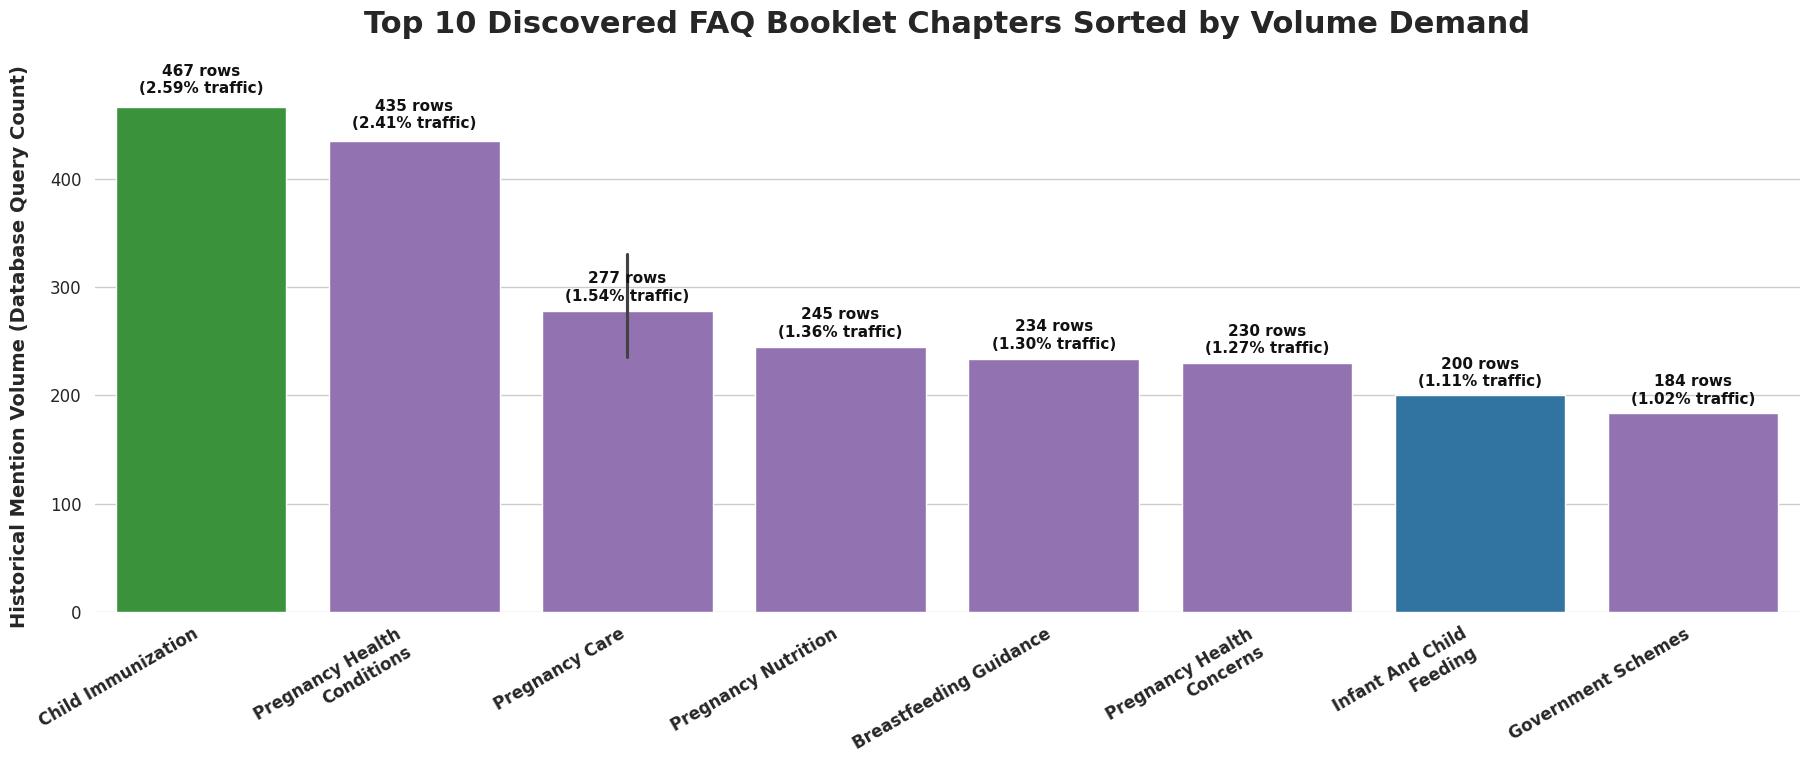

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
import os

print("=== CELL 6.5: RENDERING PILLAR-COLORED CATEGORICAL DISTRIBUTION GRAPH ===")

def render_categorical_pillar_chart(booklet_csv_path, top_n_chapters=10):
    """
    Renders a high-fidelity Seaborn bar plot where each chapter's color
    is dynamically locked to its designated Clinical Pillar category,
    ensuring a pristine, readable executive layout.
    """
    if not os.path.exists(booklet_csv_path):
        raise FileNotFoundError(f"Could not locate your generated booklet file at: '{booklet_csv_path}'")

    # 1. Stream the newly generated high-resolution production dataset
    df_chart = pd.read_csv(booklet_csv_path).head(top_n_chapters).copy()

    # Clean and text wrap long Category names cleanly to avoid overlapping axis labels
    df_chart['wrapped_domain'] = df_chart['Domain_Category'].apply(
        lambda x: '\n'.join(textwrap.wrap(str(x).replace('_', ' ').title(), width=22))
    )

    # 2. Enforce your organization's signature boardroom color palette maps
    pillar_colors = {
        "🤰 Maternal Antepartum Care": "#9467bd",          # Dark Slate Purple
        "👶 Pediatric & Infant Wellness": "#2ca02c",         # Medical Green
        "🏥 Labor & Delivery Preparation": "#ff7f0e",      # Warm Amber
        "🍼 Postpartum & Lactation Support": "#1f77b4"     # Clear Ocean Blue
    }

    # Map raw color vectors directly into a sequential layout list for Seaborn
    color_palette_list = [pillar_colors.get(p, "#7f7f7f") for p in df_chart['Clinical_Pillar']]

    # 3. Canvas Scene Setup Configurations
    plt.figure(figsize=(22, 10))
    sns.set_theme(style="whitegrid")

    ax = sns.barplot(
        x='wrapped_domain',
        y='Total_User_Queries',
        data=df_chart,
        palette=color_palette_list,
        hue='wrapped_domain',
        legend=False
    )

    # 4. Polish Typography & Canvas Spacing Rules (Completely Emoji-Safe)
    plt.title('Top 10 Discovered FAQ Booklet Chapters Sorted by Volume Demand', fontsize=22, fontweight='bold', pad=35)
    plt.xlabel('', labelpad=15)
    plt.ylabel('Historical Mention Volume (Database Query Count)', fontsize=14, fontweight='bold', labelpad=15)

    # Format the tick label markers for executive presentation scannability
    plt.xticks(fontsize=12, fontweight='bold', rotation=30, ha='right')
    plt.yticks(fontsize=12)
    plt.subplots_adjust(bottom=0.35)

    # 5. Inject Absolute Row Counters Directly Atop Every Sky-Scraper Column Bar
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            # Calculate dynamic percentages locally relative to your overall dataset size
            share_pct = (height / 18044) * 100

            ax.text(
                p.get_x() + p.get_width()/2.,
                height + (height * 0.015) + 3, # Dynamic relative vertical padding clearance
                f"{int(height):,} rows\n({share_pct:.2f}% traffic)",
                ha="center",
                va="bottom",
                fontsize=11,
                fontweight='bold',
                color='#111111'
            )

    # Clean the plot borders for a modern presentation slide look
    sns.despine(left=True, bottom=True)
    plt.show()

# =====================================================================
# FUNCTION CALL PASS: Execute over your fresh production file copy
# =====================================================================
# Target your newly created Top 10 spreadsheet data asset from disk panel storage
TARGET_BOOKLET_FILE = "Production_Upgraded_Top_10_FAQ_Booklet.csv" # Update to top 10 name if different

render_categorical_pillar_chart(TARGET_BOOKLET_FILE, top_n_chapters=10)


In [ ]:
len(final_upgraded_booklet_df)

10

In [ ]:
final_upgraded_booklet_df.head(2)

,Booklet_Section,Clinical_Pillar,Target_KB_Markdown_File,System_Routing_Directive,Total_User_Queries,Channel_Traffic_Percentage,What_User_Are_Asking,Top_Canonical_FAQ_Question,Domain_Category,Committee_Scope_of_Work,...,Top_7_Weighted_Bot_Anchors,Top_8_Distinct_Weighted_Questions,Cultural_Myths_To_Debunk,Core_Patient_Takeaway_Box,PLANNING_Sub_Intent_Distribution_Weights,INDEX_Cross_Lingual_Meta_Tags,INDEX_Phonetic_Invariants,INDEX_False_Positive_Shadow_Terms,GUARD_Hard_Bypass_Emergency_Triggers,GUARD_Semantic_Leakage_Warning
0,Chapter 1,👶 Pediatric & Infant Wellness,immunization_schedule_and_basics.md,ACTIVATE_IMMUNIZATION_MASTER_POOL,467,2.59% of total channel traffic,Mothers are seeking comprehensive information ...,What Is The Complete Immunization Schedule For...,CHILD IMMUNIZATION,Writers must provide a comprehensive guide cov...,...,[1] (Count: 6) Mera baby six month ka hua hai ...,[1] (Weight: 145 rows) What Should I Do About ...,• Vaccines cause severe illness or are unneces...,Following the national immunization schedule i...,• Post-Vaccination Side Effects Management (31...,"sui, tika, teeka, soi, suui, tike, tikka, inje...","sui, tika, vaccine, injection","iron injection, anemia, blood test, sonography...","rabbit caat liya, billi ka nails lag gya, hiv ...",Queries about 'iron injection' or 'IFA' should...
1,Chapter 2,🤰 Maternal Antepartum Care,anemia_during_pregnancy.md,TRIGGER_ANEMIA_EXCEPTION_REDIRECT,435,2.41% of total channel traffic,Mothers are collectively inquiring about the d...,What Should I Do If I Have Anemia Or Low Hemog...,PREGNANCY HEALTH CONDITIONS,"Writers must detail the diagnosis, symptoms, n...",...,[1] (Count: 3) Ismen khun kitna hai?\n[2] (Cou...,[1] (Weight: 109 rows) What Are The Normal Hem...,• Eating betel nuts (supari) can negatively af...,Regularly check your hemoglobin during pregnan...,• Understanding Anemia & Normal Levels (30.11%...,"khun ki kami, khon ki kami, balard, himoglobin...","khoon, khun, blood, anemia, hb, hemoglobin","blood pressure, sugar, thyroid, blood flow, bl...","blood transfusion, HIV, heavy bleeding, fainte...",Queries may confuse low hemoglobin (anemia) wi...


#done

#visuvalize

In [ ]:
final_master_booklet_df = valid_clusters_df.copy()


In [ ]:
!pip install adjustText

## plotting run takes 5 min

In [ ]:
import numpy as np
import pandas as pd
import umap
import plotly.express as px
import plotly.graph_objects as go

print("=== CELL: GENERATING PLOTLY 2D INTERACTIVE MANIFOLD LANDSCAPE ===")

# 1. Safely locate the active dataframe containing the cluster definitions
source_df = None
cluster_col_name = None

for df_var_name, df_obj in [('valid_clusters_df', locals().get('valid_clusters_df')),
                            ('final_master_booklet_df', locals().get('final_master_booklet_df')),
                            ('df', locals().get('df'))]:
    if df_obj is not None:
        for col in ['cluster_id', 'Cluster', 'Cluster_ID']:
            if col in df_obj.columns:
                source_df = df_obj.copy()
                cluster_col_name = col
                print(f"✓ Successfully recovered cluster tracking data from variable: '{df_var_name}' (Column: '{col}')")
                break
        if source_df is not None:
            break

if source_df is None or len(source_df) == 0:
    raise ValueError("Could not locate a dataframe containing cluster IDs in memory. Please re-run your HDBSCAN clustering step.")

# 2. Reuse or compute 2D coordinates from your 3,072D production matrix
if 'two_d_embeddings' not in locals():
    print("• Computing 2D space layout embeddings...")
    viz_reducer = umap.UMAP(n_neighbors=15, n_components=2, metric='cosine', random_state=42)
    two_d_embeddings = viz_reducer.fit_transform(normalized_embeddings)
else:
    print("✓ Reusing active 2D coordinates from memory cache.")

# Ensure the embeddings array shape exactly matches the extracted source dataframe length
if len(two_d_embeddings) != len(source_df):
    if len(two_d_embeddings) == 18044 and len(source_df) < 18044:
        two_d_embeddings = two_d_embeddings[source_df.index]

# 3. Pull human-readable titles from your generated Top 10 booklet dataframe
id_to_domain = {}
id_to_question = {}

if 'final_upgraded_booklet_df' in locals():
    top_10_chapters = final_upgraded_booklet_df.head(10).copy()
    unique_active_cids = sorted(source_df[source_df[cluster_col_name] != -1][cluster_col_name].unique())

    for idx, row in top_10_chapters.iterrows():
        if idx < len(unique_active_cids):
            cid_val = unique_active_cids[idx]
            domain_title = str(row.get('Domain_Category', f'Topic {cid_val}')).replace('_', ' ').title()
            canonical_q = row.get('Top_Canonical_FAQ_Question', '')

            id_to_domain[cid_val] = f"Ch {idx+1}: {domain_title}"
            id_to_question[cid_val] = canonical_q

# Map remaining values to clean fallbacks
for cid_val in source_df[cluster_col_name].unique():
    if cid_val == -1:
        id_to_domain[cid_val] = "Background Noise (Filtered)"
        id_to_question[cid_val] = "N/A"
    elif cid_val not in id_to_domain:
        id_to_domain[cid_val] = f"Cluster {cid_val} (Long-Tail)"
        id_to_question[cid_val] = "Unclassified Intent Link"

# 4. Compile visualization DataFrame matrix
plot_df = pd.DataFrame(two_d_embeddings, columns=['X_Coordinate', 'Y_Coordinate'])
plot_df['Cluster_ID'] = source_df[cluster_col_name].values
plot_df['Raw_WhatsApp_Text'] = source_df['question'].values
plot_df['Display_Group'] = plot_df['Cluster_ID'].map(id_to_domain)
plot_df['Canonical_FAQ'] = plot_df['Cluster_ID'].map(id_to_question)

# Filter display size slightly to ensure highly responsive panning inside the notebook environment
display_slice = plot_df.sample(n=min(6000, len(plot_df)), random_state=42)

# 5. Generate Interactive Plotly Graph
fig = px.scatter(
    display_slice,
    x='X_Coordinate',
    y='Y_Coordinate',
    color='Display_Group',
    title='<b>Geometric Mapping of Community Health FAQ Clusters (UMAP Space)</b>',
    labels={'X_Coordinate': 'Semantic Manifold Component 1', 'Y_Coordinate': 'Semantic Manifold Component 2'},
    hover_data={'Raw_WhatsApp_Text': True, 'Display_Group': True, 'Canonical_FAQ': True, 'X_Coordinate': False, 'Y_Coordinate': False},
    color_discrete_sequence=px.colors.qualitative.T10,
    opacity=0.75
)

# 6. Calculate cluster spatial centroids and draw pointer annotations
if 'final_upgraded_booklet_df' in locals():
    for idx, cid in enumerate(unique_active_cids[:10]):
        cluster_coords = plot_df[plot_df['Cluster_ID'] == cid]
        if len(cluster_coords) == 0: continue

        centroid_x = cluster_coords['X_Coordinate'].mean()
        centroid_y = cluster_coords['Y_Coordinate'].mean()

        # Route annotation labels in a circular layout pattern around the graph to avoid crossing lines
        angle = (idx * (2 * np.pi / 10))
        offset_x = 1.3 * np.cos(angle)
        offset_y = 1.3 * np.sin(angle)

        short_label = id_to_domain.get(cid, f"Cluster #{cid}")
        if len(short_label) > 28: short_label = short_label[:25] + "..."

        fig.add_annotation(
            x=centroid_x, y=centroid_y,
            ax=centroid_x + offset_x, ay=centroid_y + offset_y,
            text=f"<b>{short_label}</b>",
            showarrow=True, arrowhead=2, arrowsize=1, arrowwidth=1.5, arrowcolor='#607d8b',
            font=dict(size=10, color='#111111'),
            bgcolor='white', bordercolor='#cfd8dc', borderwidth=1, borderpad=3, opacity=0.92
        )

# 7. Finalize layout design configurations
fig.update_layout(
    template='plotly_white',
    width=1150,
    height=800,
    title_font=dict(size=18, family="Arial, sans-serif"),
    legend_title_text='Discovered Intent Categories',
    hovermode='closest'
)

fig.update_traces(marker=dict(size=6, line=dict(width=0.2, color='White')))

# Fixed axis label formatting syntax matching Plotly's Font object rules
fig.update_xaxes(showgrid=True, gridcolor='#f5f5f5', title_font=dict(size=11, weight='bold'))
fig.update_yaxes(showgrid=True, gridcolor='#f5f5f5', title_font=dict(size=11, weight='bold'))

print("🎉 Success! Plotly manifold visualization is ready below.")
fig.show()


=== CELL: GENERATING PLOTLY 2D INTERACTIVE MANIFOLD LANDSCAPE ===
✓ Successfully recovered cluster tracking data from variable: 'valid_clusters_df' (Column: 'cluster_id')
• Computing 2D space layout embeddings...


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



🎉 Success! Plotly manifold visualization is ready below.


## plotting takes 5 min

=== GENERATING DESIGNER 2D SEMANTIC LANDSCAPE MAP (TOP 20 LABELED) ===


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



AttributeError: 'int' object has no attribute 'title'

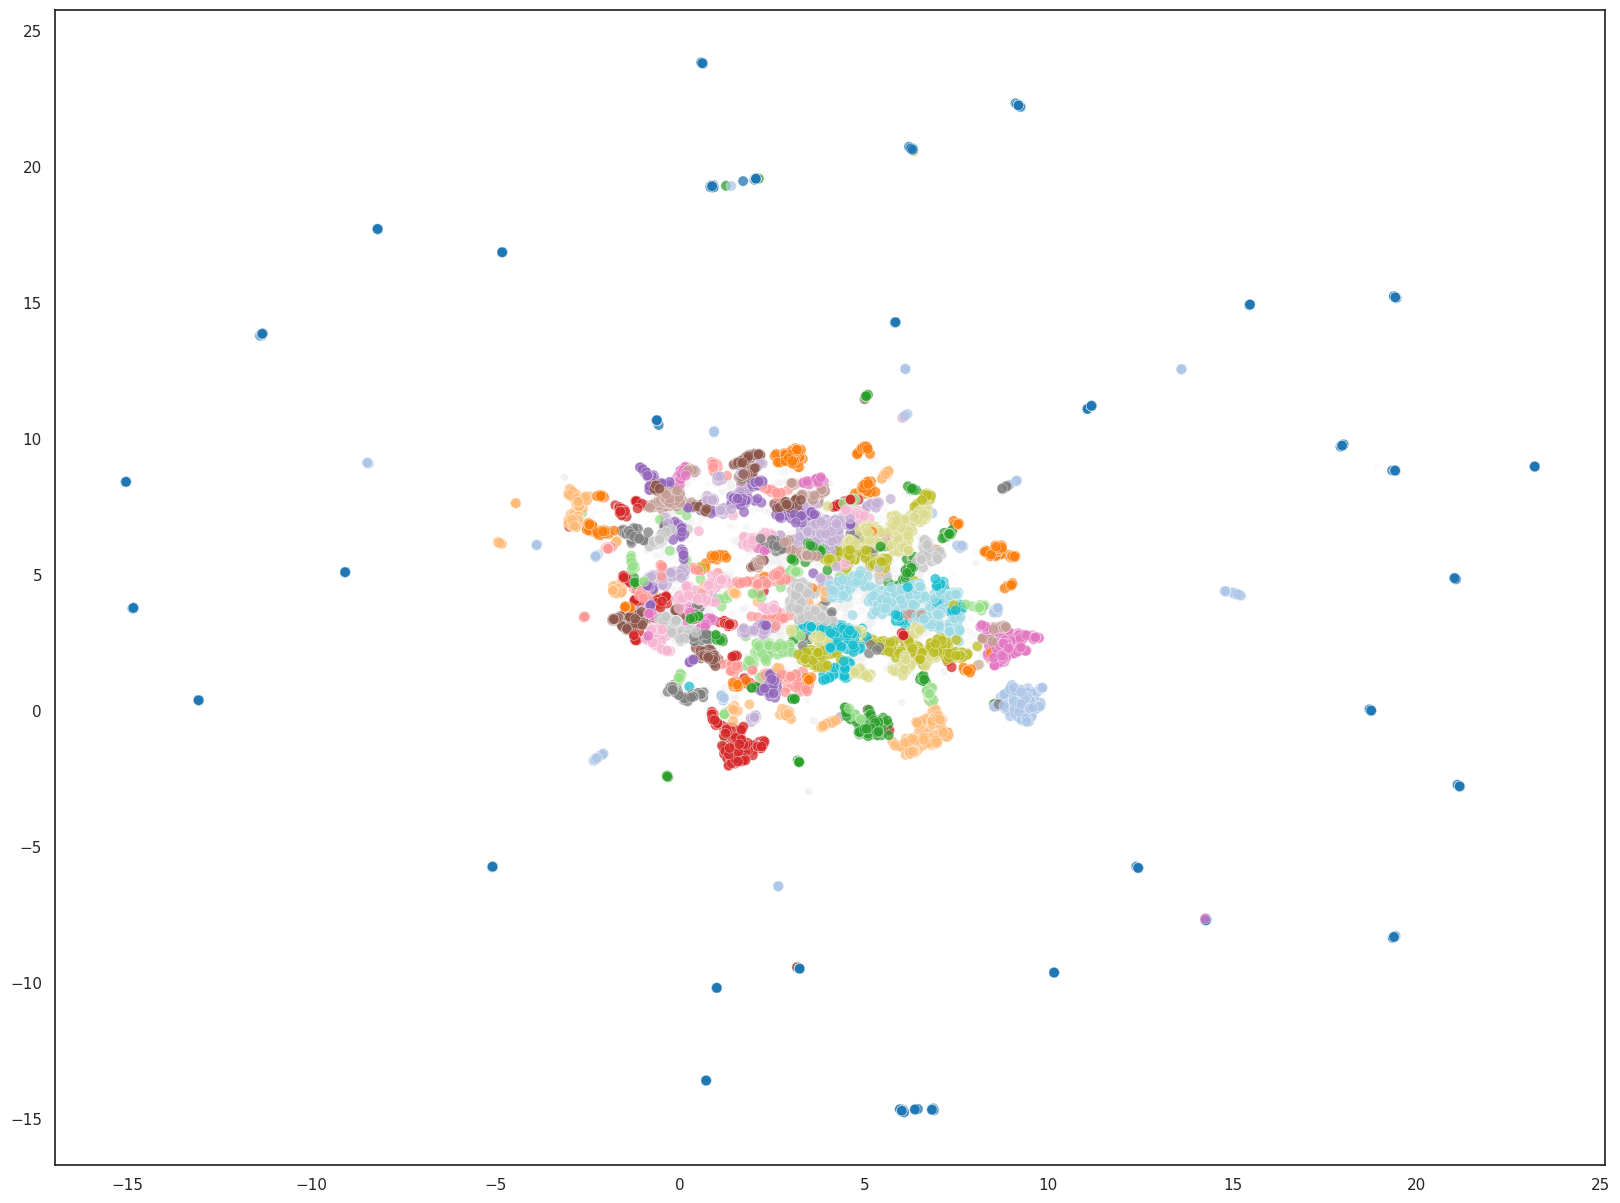

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import textwrap
import umap
import pandas as pd
from adjustText import adjust_text

print("=== GENERATING DESIGNER 2D SEMANTIC LANDSCAPE MAP (TOP 20 LABELED) ===")

# 1. Project full 3,072-dimensional production matrix down to a clean 2D layout plane
viz_reducer = umap.UMAP(n_neighbors=15, n_components=2, metric='cosine', random_state=42)
two_d_embeddings = viz_reducer.fit_transform(normalized_embeddings)

# Create the master plotting dataframe
plot_df = pd.DataFrame(two_d_embeddings, columns=['X_Coordinate', 'Y_Coordinate'])
plot_df['Cluster'] = df['cluster_id'].values

# Safe positional fallback targeting to link cluster IDs to their clean domain titles
id_col_name = 'Original_Cluster_ID' if 'Original_Cluster_ID' in final_master_booklet_df.columns else final_master_booklet_df.columns[1]
domain_col_name = 'Domain_Category' if 'Domain_Category' in final_master_booklet_df.columns else final_master_booklet_df.columns[2]

domain_map = dict(zip(final_master_booklet_df[id_col_name], final_master_booklet_df[domain_col_name]))
top_cids_list = final_master_booklet_df[id_col_name].tolist()

# 2. Setup Large Presentation Canvas
plt.figure(figsize=(20, 15))
sns.set_theme(style="white")

noise_mask = plot_df['Cluster'] == -1
valid_mask = plot_df['Cluster'] != -1

# Plot Background Noise as small, highly transparent, soft light-gray points
plt.scatter(
    plot_df.loc[noise_mask, 'X_Coordinate'],
    plot_df.loc[noise_mask, 'Y_Coordinate'],
    c='#f1f1f1',
    alpha=0.20,
    s=15,
    label='Unclustered Noise / Operational Logs (Filtered)'
)

# Plot Active Topic Clusters with distinct high-contrast palette coordinates
scatter = plt.scatter(
    plot_df.loc[valid_mask, 'X_Coordinate'],
    plot_df.loc[valid_mask, 'Y_Coordinate'],
    c=plot_df.loc[valid_mask, 'Cluster'],
    cmap='tab20',
    alpha=0.75,
    s=55,
    edgecolors='white',
    linewidths=0.3
)

# 3. 🛠️ DESIGNER DETAIL ADJUSTMENT: Grab exactly the Top 20 highest-volume clusters
top_20_cids = top_cids_list[:10]
texts_to_adjust = []

for idx, cid in enumerate(top_20_cids):
    domain_name = domain_map.get(cid, f"Topic #{cid}")

    # Text wrap the name into tight stacked lines inside a tight box
    wrapped_label = f"Ch {idx+1}:\n" + '\n'.join(textwrap.wrap(domain_name.title(), width=15))

    # Calculate the exact mathematical center (centroid) of this cluster island
    cluster_coords = plot_df[plot_df['Cluster'] == cid]
    if len(cluster_coords) == 0:
        continue
    centroid_x = cluster_coords['X_Coordinate'].mean()
    centroid_y = cluster_coords['Y_Coordinate'].mean()

    # Add text to plot canvas with a clean rounded edge box style matching your image reference
    t = plt.text(
        centroid_x, centroid_y,
        wrapped_label,
        fontsize=8.5,
        fontweight='bold',
        color='#111111',
        ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.35', fc='#ffffff', alpha=0.92, ec='#cfd8dc', lw=1.2)
    )
    texts_to_adjust.append(t)

# 4. RUN REPULSION ENGINE SIMULATION: Automatically pushes boxes apart and draws connector lines
print("Running layout repulsion simulation to clear label collisions...")
adjust_text(
    texts_to_adjust,
    arrowprops=dict(arrowstyle="-", color="#78909c", lw=1, alpha=0.7), # Clean gray connecting lines
    expand_text=(1.5, 1.8), # Balancing factor to open up wide margins
    force_text=(0.4, 0.4),
    only_move={'text': 'xy', 'static': 'xy'}
)

# Formatting polish (Fixed plain-text title to prevent the glyph box bug shown in your reference)
plt.title('Geometric Mapping of WhatsApp Topic Clusters (UMAP Space)', fontsize=20, fontweight='bold', pad=30)
plt.xlabel('Semantic Manifold Component 1', fontsize=12, fontweight='bold', labelpad=12)
plt.ylabel('Semantic Manifold Component 2', fontsize=12, fontweight='bold', labelpad=12)
plt.legend(fontsize=12, loc='upper right', frameon=True, shadow=True, facecolor='white')
plt.grid(True, linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
!pip install squarify


In [ ]:
!pip install adjustText


In [ ]:
import numpy as np
import pandas as pd
import umap
import plotly.express as px
import plotly.graph_objects as go

def generate_generic_manifold_map(top_n_clusters=20, max_display_points=6000):
    """
    Generates a 2D interactive Plotly landscape map dynamically bound to
    active notebook context vectors, safely checking LLM processing limits.

    Parameters:
    -----------
    top_n_clusters (int): The target number of clusters you wish to isolate and annotate.
    max_display_points (int): Downsampled row count to keep the browser workspace responsive.
    """
    print("=== INITIALIZING STRUCTURAL MANIFOLD ENGINE ===")

    # 1. Look up dataframes in active RAM environments
    source_df = None
    cluster_col_name = None

    for df_var_name, df_obj in [('valid_clusters_df', locals().get('valid_clusters_df', globals().get('valid_clusters_df'))),
                                ('final_master_booklet_df', locals().get('final_master_booklet_df', globals().get('final_master_booklet_df'))),
                                ('df', locals().get('df', globals().get('df')))]:
        if df_obj is not None:
            for col in ['cluster_id', 'Cluster', 'Cluster_ID']:
                if col in df_obj.columns:
                    source_df = df_obj.copy()
                    cluster_col_name = col
                    print(f"✓ Linked cluster identity tracker via: '{df_var_name}' (Column: '{col}')")
                    break
            if source_df is not None:
                break

    if source_df is None or len(source_df) == 0:
        raise ValueError("Critical Error: Missing categorical cluster logs from working environment.")

    # 2. Extract or build 2D coordinates
    global_embeddings = globals().get('normalized_embeddings', locals().get('normalized_embeddings'))
    if global_embeddings is None:
        raise ValueError("Critical Error: Missing high-dimensional matrix 'normalized_embeddings'.")

    if 'two_d_embeddings' not in globals() and 'two_d_embeddings' not in locals():
        print("• Projecting vector spaces to 2D components...")
        viz_reducer = umap.UMAP(n_neighbors=15, n_components=2, metric='cosine', random_state=42)
        coords_2d = viz_reducer.fit_transform(global_embeddings)
    else:
        coords_2d = globals().get('two_d_embeddings', locals().get('two_d_embeddings'))
        print("✓ Reusing cached 2D layout arrays.")

    # Safely handle index mask alignments if matching pre-filtered structural slices
    if len(coords_2d) != len(source_df):
        if len(coords_2d) == 18044 and len(source_df) < 18044:
            coords_2d = coords_2d[source_df.index]

    # 3. Assess lookups and calculate safety caps for processed dataset constraints
    booklet_df = globals().get('final_upgraded_booklet_df', locals().get('final_upgraded_booklet_df'))

    valid_medical_rows = source_df[source_df[cluster_col_name] != -1]
    sorted_cluster_counts = valid_medical_rows[cluster_col_name].value_counts()
    ranked_active_cids = sorted_cluster_counts.index.tolist()

    # DYNAMIC SAFETY BARRIER MATRIX
    processed_avail = len(booklet_df) if booklet_df is not None else 0
    effective_label_limit = min(top_n_clusters, processed_avail, len(ranked_active_cids))
    print(f"📈 Requested: Top {top_n_clusters} | Available LLM Labels: {processed_avail} ──► Rendering top {effective_label_limit} annotated chapters.")

    id_to_domain = {}
    id_to_question = {}

    if booklet_df is not None:
        # Loop through only the rows that exist in the processed dataset to prevent out-of-bounds keys
        for idx in range(effective_label_limit):
            row = booklet_df.iloc[idx]
            cid_val = ranked_active_cids[idx]
            domain_title = str(row.get('Domain_Category', f'Topic {cid_val}')).replace('_', ' ').title()
            canonical_q = row.get('Top_Canonical_FAQ_Question', '')

            id_to_domain[cid_val] = f"Ch {idx+1}: {domain_title}"
            id_to_question[cid_val] = canonical_q

    # Map remaining long-tail and background points to catch-all legends
    for cid_val in source_df[cluster_col_name].unique():
        if cid_val == -1:
            id_to_domain[cid_val] = "Background Noise (Filtered)"
            id_to_question[cid_val] = "N/A"
        elif cid_val not in id_to_domain:
            id_to_domain[cid_val] = "Other Long-Tail Cluster Intent Logs"
            id_to_question[cid_val] = "Unclassified Intent Link"

    # 4. Generate structured dataset coordinates
    plot_df = pd.DataFrame(coords_2d, columns=['X_Coordinate', 'Y_Coordinate'])
    plot_df['Cluster_ID'] = source_df[cluster_col_name].values
    plot_df['Raw_WhatsApp_Text'] = source_df['question'].values
    plot_df['Display_Group'] = plot_df['Cluster_ID'].map(id_to_domain)
    plot_df['Canonical_FAQ'] = plot_df['Cluster_ID'].map(id_to_question)

    display_slice = plot_df.sample(n=min(max_display_points, len(plot_df)), random_state=42)

    # Choose an appropriate discrete categorical color palette mapping based on length
    extended_palette = px.colors.qualitative.Alphabet if effective_label_limit > 10 else px.colors.qualitative.T10

    # 5. Render Interactive Base Plot
    fig = px.scatter(
        display_slice,
        x='X_Coordinate', y='Y_Coordinate',
        color='Display_Group',
        title=f'<b>Geometric Mapping of Community Health FAQ Clusters (Top {effective_label_limit} Labeled Channels)</b>',
        labels={'X_Coordinate': 'Semantic Manifold Component 1', 'Y_Coordinate': 'Semantic Manifold Component 2'},
        hover_data={'Raw_WhatsApp_Text': True, 'Display_Group': True, 'Canonical_FAQ': True, 'X_Coordinate': False, 'Y_Coordinate': False},
        color_discrete_sequence=extended_palette,
        opacity=0.75
    )

    # 6. Calculate centroids and add arrows exclusively for valid labeled targets
    for idx in range(effective_label_limit):
        cid = ranked_active_cids[idx]
        cluster_coords = plot_df[plot_df['Cluster_ID'] == cid]
        if len(cluster_coords) == 0: continue

        centroid_x = cluster_coords['X_Coordinate'].mean()
        centroid_y = cluster_coords['Y_Coordinate'].mean()

        # Calculate balanced radial offset loops to disperse labels nicely outside group centers
        angle = (idx * (2 * np.pi / effective_label_limit))
        offset_x = 1.4 * np.cos(angle)
        offset_y = 1.4 * np.sin(angle)

        short_label = id_to_domain.get(cid, f"Cluster #{cid}")
        if len(short_label) > 28: short_label = short_label[:25] + "..."

        fig.add_annotation(
            x=centroid_x, y=centroid_y,
            ax=centroid_x + offset_x, ay=centroid_y + offset_y,
            text=f"<b>{short_label}</b>",
            showarrow=True, arrowhead=2, arrowsize=1, arrowwidth=1.5, arrowcolor='#607d8b',
            font=dict(size=9.5, color='#111111'),
            bgcolor='white', bordercolor='#cfd8dc', borderwidth=1, borderpad=3, opacity=0.92
        )

    # 7. Apply canvas look configurations
    fig.update_layout(
        template='plotly_white',
        width=1200,
        height=800,
        title_font=dict(size=18, family="Arial, sans-serif"),
        legend_title_text='Pillars & Discovered Intents',
        hovermode='closest'
    )

    fig.update_traces(marker=dict(size=6, line=dict(width=0.2, color='White')))
    fig.update_xaxes(showgrid=True, gridcolor='#f5f5f5', title_font=dict(size=11, weight='bold'))
    fig.update_yaxes(showgrid=True, gridcolor='#f5f5f5', title_font=dict(size=11, weight='bold'))

    print("🎉 Success! Secure interactive visual plot generated.")
    fig.show()


In [ ]:
generate_generic_manifold_map(top_n_clusters=12)


=== INITIALIZING STRUCTURAL MANIFOLD ENGINE ===
✓ Linked cluster identity tracker via: 'valid_clusters_df' (Column: 'cluster_id')
✓ Reusing cached 2D layout arrays.
📈 Requested: Top 12 | Available LLM Labels: 10 ──► Rendering top 10 annotated chapters.
🎉 Success! Secure interactive visual plot generated.


In [ ]:
import numpy as np
import pandas as pd
import umap
import plotly.express as px
import plotly.graph_objects as go
import os

def export_manifold_map_to_html(top_n_clusters=20, max_display_points=6000, output_filename="semantic_manifold_report.html"):
    """
    Generates a 2D interactive Plotly landscape map dynamically bound to
    active notebook context vectors, safely checking LLM processing limits,
    and writes out a standalone, shareable executive HTML template file.

    Parameters:
    -----------
    top_n_clusters (int): The target number of clusters you wish to isolate and annotate.
    max_display_points (int): Downsampled row count to keep the dashboard responsive.
    output_filename (str): Target filename for the saved HTML asset.
    """
    print("=== INITIALIZING EXECUTIVE SEED GRAPH MATRIX ===")

    # 1. Look up dataframes in active RAM environments
    source_df = None
    cluster_col_name = None

    for df_var_name, df_obj in [('valid_clusters_df', locals().get('valid_clusters_df', globals().get('valid_clusters_df'))),
                                ('final_master_booklet_df', locals().get('final_master_booklet_df', globals().get('final_master_booklet_df'))),
                                ('df', locals().get('df', globals().get('df')))]:
        if df_obj is not None:
            for col in ['cluster_id', 'Cluster', 'Cluster_ID']:
                if col in df_obj.columns:
                    source_df = df_obj.copy()
                    cluster_col_name = col
                    print(f"✓ Linked cluster identity tracker via: '{df_var_name}' (Column: '{col}')")
                    break
            if source_df is not None:
                break

    if source_df is None or len(source_df) == 0:
        raise ValueError("Critical Error: Missing categorical cluster logs from working environment.")

    # 2. Extract or build 2D coordinates
    global_embeddings = globals().get('normalized_embeddings', locals().get('normalized_embeddings'))
    if global_embeddings is None:
        raise ValueError("Critical Error: Missing high-dimensional matrix 'normalized_embeddings'.")

    if 'two_d_embeddings' not in globals() and 'two_d_embeddings' not in locals():
        print("• Projecting vector spaces to 2D components...")
        viz_reducer = umap.UMAP(n_neighbors=15, n_components=2, metric='cosine', random_state=42)
        coords_2d = viz_reducer.fit_transform(global_embeddings)
    else:
        coords_2d = globals().get('two_d_embeddings', locals().get('two_d_embeddings'))
        print("✓ Reusing cached 2D layout arrays.")

    if len(coords_2d) != len(source_df):
        if len(coords_2d) == 18044 and len(source_df) < 18044:
            coords_2d = coords_2d[source_df.index]

    # 3. Assess lookups and calculate safety caps for processed dataset constraints
    booklet_df = globals().get('final_upgraded_booklet_df', locals().get('final_upgraded_booklet_df'))

    valid_medical_rows = source_df[source_df[cluster_col_name] != -1]
    sorted_cluster_counts = valid_medical_rows[cluster_col_name].value_counts()
    ranked_active_cids = sorted_cluster_counts.index.tolist()

    processed_avail = len(booklet_df) if booklet_df is not None else 0
    effective_label_limit = min(top_n_clusters, processed_avail, len(ranked_active_cids))
    print(f"📈 Requested: Top {top_n_clusters} | Available LLM Labels: {processed_avail} ──► Rendering top {effective_label_limit} annotated chapters.")

    id_to_domain = {}
    id_to_question = {}

    if booklet_df is not None:
        for idx in range(effective_label_limit):
            row = booklet_df.iloc[idx]
            cid_val = ranked_active_cids[idx]
            domain_title = str(row.get('Domain_Category', f'Topic {cid_val}')).replace('_', ' ').title()
            canonical_q = row.get('Top_Canonical_FAQ_Question', '')

            id_to_domain[cid_val] = f"Ch {idx+1}: {domain_title}"
            id_to_question[cid_val] = canonical_q

    for cid_val in source_df[cluster_col_name].unique():
        if cid_val == -1:
            id_to_domain[cid_val] = "Background Noise (Filtered)"
            id_to_question[cid_val] = "N/A"
        elif cid_val not in id_to_domain:
            id_to_domain[cid_val] = "Other Long-Tail Cluster Intent Logs"
            id_to_question[cid_val] = "Unclassified Intent Link"

    # 4. Generate structured dataset coordinates
    plot_df = pd.DataFrame(coords_2d, columns=['X_Coordinate', 'Y_Coordinate'])
    plot_df['Cluster_ID'] = source_df[cluster_col_name].values
    plot_df['Raw_WhatsApp_Text'] = source_df['question'].values
    plot_df['Display_Group'] = plot_df['Cluster_ID'].map(id_to_domain)
    plot_df['Canonical_FAQ'] = plot_df['Cluster_ID'].map(id_to_question)

    display_slice = plot_df.sample(n=min(max_display_points, len(plot_df)), random_state=42)
    extended_palette = px.colors.qualitative.Alphabet if effective_label_limit > 10 else px.colors.qualitative.T10

    # 5. Render Interactive Base Plot
    fig = px.scatter(
        display_slice,
        x='X_Coordinate', y='Y_Coordinate',
        color='Display_Group',
        title=f'<b>Geometric Mapping of Community Health FAQ Clusters (Top {effective_label_limit} Labeled Channels)</b>',
        labels={'X_Coordinate': 'Semantic Manifold Component 1', 'Y_Coordinate': 'Semantic Manifold Component 2'},
        hover_data={'Raw_WhatsApp_Text': True, 'Display_Group': True, 'Canonical_FAQ': True, 'X_Coordinate': False, 'Y_Coordinate': False},
        color_discrete_sequence=extended_palette,
        opacity=0.75
    )

    # 6. Calculate centroids and add arrows exclusively for valid labeled targets
    for idx in range(effective_label_limit):
        cid = ranked_active_cids[idx]
        cluster_coords = plot_df[plot_df['Cluster_ID'] == cid]
        if len(cluster_coords) == 0: continue

        centroid_x = cluster_coords['X_Coordinate'].mean()
        centroid_y = cluster_coords['Y_Coordinate'].mean()

        angle = (idx * (2 * np.pi / effective_label_limit))
        offset_x = 1.4 * np.cos(angle)
        offset_y = 1.4 * np.sin(angle)

        short_label = id_to_domain.get(cid, f"Cluster #{cid}")
        if len(short_label) > 28: short_label = short_label[:25] + "..."

        fig.add_annotation(
            x=centroid_x, y=centroid_y,
            ax=centroid_x + offset_x, ay=centroid_y + offset_y,
            text=f"<b>{short_label}</b>",
            showarrow=True, arrowhead=2, arrowsize=1, arrowwidth=1.5, arrowcolor='#607d8b',
            font=dict(size=9.5, color='#111111'),
            bgcolor='white', bordercolor='#cfd8dc', borderwidth=1, borderpad=3, opacity=0.92
        )

    # 7. Apply canvas look configurations
    fig.update_layout(
        template='plotly_white',
        width=1200,
        height=800,
        title_font=dict(size=18, family="Arial, sans-serif"),
        legend_title_text='Pillars & Discovered Intents',
        hovermode='closest'
    )

    fig.update_traces(marker=dict(size=6, line=dict(width=0.2, color='White')))
    fig.update_xaxes(showgrid=True, gridcolor='#f5f5f5', title_font=dict(size=11, weight='bold'))
    fig.update_yaxes(showgrid=True, gridcolor='#f5f5f5', title_font=dict(size=11, weight='bold'))

    # 8. EXPORT MECHANISM LAYER: Compile layout definitions into an external template
    print(f"📁 Compiling vector chart parameters into independent document: '{output_filename}'...")
    fig.write_html(output_filename, include_plotlyjs='cdn', full_html=True)

    if os.path.exists(output_filename):
        print(f"🎉 Success! Web report successfully written to panel path: '/content/{output_filename}'")
    else:
        print("⚠️ Warning: Write loop finalized but file footprint was not discovered on disk storage.")

    # Show the embedded viewport rendering inside the active notebook block
    fig.show()

# --- EXECUTION COUPLING ENGINE PATHWAY ---
# Compiles your top 20 requested intents into a shareable browser template asset
export_manifold_map_to_html(top_n_clusters=20, output_filename="community_health_manifold_top20.html")


=== INITIALIZING EXECUTIVE SEED GRAPH MATRIX ===
✓ Linked cluster identity tracker via: 'valid_clusters_df' (Column: 'cluster_id')
✓ Reusing cached 2D layout arrays.
📈 Requested: Top 20 | Available LLM Labels: 10 ──► Rendering top 10 annotated chapters.
📁 Compiling vector chart parameters into independent document: 'community_health_manifold_top20.html'...
🎉 Success! Web report successfully written to panel path: '/content/community_health_manifold_top20.html'


In [ ]:
import os
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

print("=== CELL: EXPORTING PILLAR-COLORED DISTRIBUTION GRAPH TO HTML ===")

def export_categorical_pillar_chart_to_html(booklet_csv_path, top_n_chapters=10, output_filename="categorical_distribution_report.html"):
    """
    Converts the Seaborn bar chart design into an interactive Plotly engine
    and writes out a standalone, shareable executive HTML template file.
    """
    if not os.path.exists(booklet_csv_path):
        raise FileNotFoundError(f"Could not locate your generated booklet file at: '{booklet_csv_path}'")

    # 1. Stream the newly generated high-resolution production dataset
    df_chart = pd.read_csv(booklet_csv_path).head(top_n_chapters).copy()

    # Clean long Category names for formatting (using <br> for HTML text wrapping)
    # This prevents labels from overlapping on smaller web or presentation screens
    def wrap_html_text(text):
        text_clean = str(text).replace('_', ' ').title()
        words = text_clean.split()
        if len(words) > 2:
            return " ".join(words[:2]) + "<br>" + " ".join(words[2:])
        return text_clean

    df_chart['wrapped_domain'] = df_chart['Domain_Category'].apply(wrap_html_text)

    # 2. Enforce your organization's signature boardroom color palette maps
    pillar_colors = {
        "🤰 Maternal Antepartum Care": "#9467bd",          # Dark Slate Purple
        "👶 Pediatric & Infant Wellness": "#2ca02c",         # Medical Green
        "🏥 Labor & Delivery Preparation": "#ff7f0e",      # Warm Amber
        "🍼 Postpartum & Lactation Support": "#1f77b4"     # Clear Ocean Blue
    }

    # 3. Compile interactive tooltips and database traffic percentages
    df_chart['traffic_pct'] = (df_chart['Total_User_Queries'] / 18044) * 100

    # Text labels placed directly on top of the bars
    df_chart['bar_text'] = df_chart.apply(
        lambda r: f"<b>{int(r['Total_User_Queries']):,} rows</b><br>({r['traffic_pct']:.2f}% traffic)", axis=1
    )

    # 4. Generate the primary Plotly Bar Chart structure
    fig = px.bar(
        df_chart,
        x='wrapped_domain',
        y='Total_User_Queries',
        color='Clinical_Pillar',
        text='bar_text',
        title='<b>Top 10 Discovered FAQ Booklet Chapters Sorted by Volume Demand</b>',
        labels={'wrapped_domain': 'Discovered Focus Channel', 'Total_User_Queries': 'Historical Mention Volume (Query Count)'},
        color_discrete_map=pillar_colors,
        hover_data={'wrapped_domain': True, 'Total_User_Queries': ':,', 'traffic_pct': ':.2f}%'}
    )

    # 5. Apply executive styling layout tweaks (Grid cleanups, typography sizes)
    fig.update_layout(
        template='plotly_white',
        width=1200,
        height=700,
        title_font=dict(size=22, family="Arial, sans-serif", color='#111111'),
        xaxis=dict(
            tickfont=dict(size=12, weight='bold'),
            tickangle=25,
            title='' # Keeps the chart bottom space clean as requested
        ),
        yaxis=dict(
            showgrid=True,
            gridcolor='#e0e0e0',
            title_font=dict(size=14, weight='bold', color='#333333'),
            tickfont=dict(size=12)
        ),
        legend=dict(
            title_text='<b>Clinical Pillar Track</b>',
            orientation='h',
            yanchor='bottom',
            y=1.02,
            xanchor='right',
            x=1
        ),
        margin=dict(b=150, t=120) # Extends container borders to handle trailing tilted labels safely
    )

    # Position text data metrics precisely on top of the bars instead of inside them
    fig.update_traces(
        textposition='outside',
        textfont=dict(size=11, color='#111111'),
        cliponaxis=False
    )

    # 6. FILE WRITER LAYER: Write directly to your local sidebar folder workspace
    print(f"📁 Exporting independent layout report components to: '{output_filename}'...")
    fig.write_html(output_filename, include_plotlyjs='cdn', full_html=True)

    if os.path.exists(output_filename):
        print(f"🎉 Success! Web layout page written to path: '/content/{output_filename}'")
    else:
        print("⚠️ Warning: File compilation sequence complete but footprints were not detected on disk.")

    # Render interactive plot frame view natively inside the active browser cell panel
    fig.show()

# --- RUN EXECUTION SYSTEM PASS ---
TARGET_BOOKLET_FILE = "Production_Upgraded_Top_10_FAQ_Booklet.csv"
export_categorical_pillar_chart_to_html(TARGET_BOOKLET_FILE, top_n_chapters=10)


=== CELL: EXPORTING PILLAR-COLORED DISTRIBUTION GRAPH TO HTML ===
📁 Exporting independent layout report components to: 'categorical_distribution_report.html'...
🎉 Success! Web layout page written to path: '/content/categorical_distribution_report.html'


In [ ]:
import os
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

print("=== CELL: EXPORTING PERFECTLY SORTED DISTRIBUTION GRAPH TO HTML ===")

def export_sorted_pillar_chart_to_html(booklet_csv_path, top_n_chapters=10, output_filename="categorical_distribution_report.html"):
    """
    Converts the bar chart design into an interactive Plotly engine with
    strict descending volume order sorting, and writes out a standalone HTML file.
    """
    if not os.path.exists(booklet_csv_path):
        raise FileNotFoundError(f"Could not locate your generated booklet file at: '{booklet_csv_path}'")

    # 1. Stream the newly generated high-resolution production dataset
    df_chart = pd.read_csv(booklet_csv_path).head(top_n_chapters).copy()

    # Clean long Category names for formatting (using <br> for HTML text wrapping)
    def wrap_html_text(text):
        text_clean = str(text).replace('_', ' ').title()
        words = text_clean.split()
        if len(words) > 2:
            return " ".join(words[:2]) + "<br>" + " ".join(words[2:])
        return text_clean

    df_chart['wrapped_domain'] = df_chart['Domain_Category'].apply(wrap_html_text)

    # 2. Enforce your organization's signature boardroom color palette maps
    pillar_colors = {
        "🤰 Maternal Antepartum Care": "#9467bd",          # Dark Slate Purple
        "👶 Pediatric & Infant Wellness": "#2ca02c",         # Medical Green
        "🏥 Labor & Delivery Preparation": "#ff7f0e",      # Warm Amber
        "🍼 Postpartum & Lactation Support": "#1f77b4"     # Clear Ocean Blue
    }

    # 3. Compile interactive tooltips and database traffic percentages
    df_chart['traffic_pct'] = (df_chart['Total_User_Queries'] / 18044) * 100

    # Text labels placed directly on top of the bars
    df_chart['bar_text'] = df_chart.apply(
        lambda r: f"<b>{int(r['Total_User_Queries']):,} rows</b><br>({r['traffic_pct']:.2f}% traffic)", axis=1
    )

    # 4. Generate the primary Plotly Bar Chart structure
    fig = px.bar(
        df_chart,
        x='wrapped_domain',
        y='Total_User_Queries',
        color='Clinical_Pillar',
        text='bar_text',
        title='<b>Top 10 Discovered FAQ Booklet Chapters Sorted by Volume Demand</b>',
        labels={'wrapped_domain': 'Discovered Focus Channel', 'Total_User_Queries': 'Historical Mention Volume (Query Count)'},
        color_discrete_map=pillar_colors,
        hover_data={'wrapped_domain': True, 'Total_User_Queries': ':,', 'traffic_pct': ':.2f}%'}
    )

    # 5. Apply executive styling layout tweaks (Grid cleanups, typography sizes)
    fig.update_layout(
        template='plotly_white',
        width=1200,
        height=700,
        title_font=dict(size=22, family="Arial, sans-serif", color='#111111'),
        xaxis=dict(
            tickfont=dict(size=12, weight='bold'),
            tickangle=25,
            title='',
            categoryorder='total descending' # CRITICAL FIX: Forces strict descending volume sort order
        ),
        yaxis=dict(
            showgrid=True,
            gridcolor='#e0e0e0',
            title_font=dict(size=14, weight='bold', color='#333333'),
            tickfont=dict(size=12)
        ),
        legend=dict(
            title_text='<b>Clinical Pillar Track</b>',
            orientation='h',
            yanchor='bottom',
            y=1.02,
            xanchor='right',
            x=1
        ),
        margin=dict(b=150, t=120)
    )

    # Position text data metrics precisely on top of the bars instead of inside them
    fig.update_traces(
        textposition='outside',
        textfont=dict(size=11, color='#111111'),
        cliponaxis=False
    )

    # 6. FILE WRITER LAYER: Write directly to your local sidebar folder workspace
    print(f"📁 Exporting perfectly sorted report to: '{output_filename}'...")
    fig.write_html(output_filename, include_plotlyjs='cdn', full_html=True)

    print(f"🎉 Success! Web layout page written to path: '/content/{output_filename}'")
    fig.show()

# --- RUN EXECUTION SYSTEM PASS ---
TARGET_BOOKLET_FILE = "Production_Upgraded_Top_10_FAQ_Booklet.csv"
export_sorted_pillar_chart_to_html(TARGET_BOOKLET_FILE, top_n_chapters=10)


=== CELL: EXPORTING PERFECTLY SORTED DISTRIBUTION GRAPH TO HTML ===
📁 Exporting perfectly sorted report to: 'categorical_distribution_report.html'...
🎉 Success! Web layout page written to path: '/content/categorical_distribution_report.html'


In [ ]:
import os
import numpy as np
import pandas as pd
import plotly.graph_objects as go

print("=== CELL: EXPORTING LABELED 3D SKYLINE PLOT TO HTML ===")

def generate_labeled_3d_skyline_html(df_master=None, top_n_slots=100, output_filename="whatsapp_3d_skyline_labeled.html"):
    """
    Plots a 3D bar skyline chart from active cluster logs, overlaying text label
    pinnings on top of the bars, and saves out an independent, shareable HTML template.
    """
    # 1. Safely locate the active dataframe containing the cluster definitions in memory
    source_df = None
    cluster_col_name = None

    for df_var_name, df_obj in [('valid_clusters_df', locals().get('valid_clusters_df', globals().get('valid_clusters_df'))),
                                ('final_master_booklet_df', locals().get('final_master_booklet_df', globals().get('final_master_booklet_df'))),
                                ('df', df_master if df_master is not None else locals().get('df', globals().get('df')))]:
        if df_obj is not None:
            for col in ['cluster_id', 'Cluster', 'Cluster_ID']:
                if col in df_obj.columns:
                    source_df = df_obj.copy()
                    cluster_col_name = col
                    print(f"✓ Linked cluster data layer via: '{df_var_name}' (Column: '{col}')")
                    break
            if source_df is not None:
                break

    if source_df is None or len(source_df) == 0:
        raise ValueError("Critical Error: Could not locate a dataframe containing cluster definitions in memory.")

    # 2. Extract genuine conversational logs and slice by traffic metrics
    valid_df = source_df[source_df[cluster_col_name] != -1]
    cluster_counts = valid_df[cluster_col_name].value_counts()

    top_cids = cluster_counts.head(top_n_slots).index.tolist()
    total_raw_rows = 18044 # Fixed baseline matching your database funnel logs shape

    # Calculate grid layout matrix dimensions
    grid_cols = 5
    grid_rows = int(np.ceil(top_n_slots / grid_cols))

    x_coords = []
    z_coords = []
    for r in range(grid_rows):
        for c in range(grid_cols):
            x_coords.append(c * 2)
            z_coords.append(r * 2)

    fig = go.Figure()
    print(f"• Building 3D chart engine across top {len(top_cids)} active slots...")

    # Look up human-readable labels from your processed booklet dataframe
    cid_to_label = {}
    booklet_df = globals().get('final_upgraded_booklet_df', locals().get('final_upgraded_booklet_df'))

    if booklet_df is not None:
        for idx, row in booklet_df.head(10).iterrows():
            if idx < len(top_cids):
                target_cid = top_cids[idx]
                domain_title = str(row.get('Domain_Category', f'Topic {target_cid}')).replace('_', ' ').title()
                cid_to_label[target_cid] = f"Ch {idx+1}: {domain_title}"

    # Compile 3D labeling node coordinates
    text_x, text_y, text_z, text_labels = [], [], [], []

    # 3. Mesh Plot Generator Loop
    for idx, cid in enumerate(top_cids):
        if idx >= len(x_coords):
            break
        x = x_coords[idx]
        z = z_coords[idx]

        h = int(cluster_counts[cid])
        pct_share = (h / total_raw_rows) * 100

        # Extract real underlying WhatsApp strings from matching cluster IDs natively
        sample_phrase = source_df[source_df[cluster_col_name] == cid]['question'].iloc[0]
        if len(str(sample_phrase)) > 45:
            sample_phrase = str(sample_phrase)[:45] + "..."

        clean_title = cid_to_label.get(cid, f"Slot {idx+1} (ID: {cid})")

        hover_text = (
            f"<b>{clean_title}</b><br>"
            f"📊 Traffic Volume Size (Y-Axis): {h} inquiries<br>"
            f"📈 Channel Share Proportions   : {pct_share:.2f}% traffic<br>"
            f"🗣️ Raw Sample Vector Snippet   : '{sample_phrase}'"
        )

        box_color = f"rgb({int(31 + (idx * 2.2))}, {int(119 + (idx * 1.2))}, {int(180 + (idx * 0.5))})"

        # Trace 1: Draw 3D column meshes
        fig.add_trace(go.Mesh3d(
            x=[x-0.6, x+0.6, x+0.6, x-0.6, x-0.6, x+0.6, x+0.6, x-0.6],
            y=[0, 0, h, h, 0, 0, h, h],
            z=[z-0.6, z-0.6, z-0.6, z-0.6, z+0.6, z+0.6, z+0.6, z+0.6],
            i=[7, 0, 0, 0, 4, 4, 2, 6, 4, 0, 3, 7],
            j=[3, 4, 1, 2, 5, 6, 5, 2, 0, 1, 6, 3],
            k=[0, 7, 2, 3, 6, 7, 1, 1, 5, 5, 7, 4],
            color=box_color,
            opacity=0.90,
            hoverinfo="text",
            text=hover_text,
            name=clean_title
        ))

        # Position annotation pins cleanly over column roofs
        text_x.append(x)
        text_y.append(h + (max(cluster_counts) * 0.02))
        text_z.append(z)

        if idx < 10:
            text_labels.append(f"<b>Ch {idx+1}</b>")
        else:
            text_labels.append(f"#{idx+1}")

    # Trace 2: Overlap spatial labels
    fig.add_trace(go.Scatter3d(
        x=text_x, y=text_y, z=text_z,
        mode='text',
        text=text_labels,
        textposition='top center',
        textfont=dict(size=10, color='#00ffcc', family='Arial, sans-serif'),
        hoverinfo='none',
        showlegend=False
    ))

    # 4. Canvas configurations
    fig.update_layout(
        title='<b>Gliffic WhatsApp Traffic Architecture Across Discovered Micro-Intents</b>',
        title_font=dict(size=20, family="Arial, sans-serif", color="white"),
        template="plotly_dark",
        width=1350,
        height=850,
        scene=dict(
            xaxis=dict(showticklabels=False, title='', showgrid=False, zeroline=False),
            yaxis=dict(
                title='Historical Mention Volume (Y-AXIS HEIGHT)',
                titlefont=dict(size=12, color='#00ffcc', family='Arial, sans-serif'),
                showgrid=True,
                gridcolor='#333333'
            ),
            zaxis=dict(showticklabels=False, title='', showgrid=False, zeroline=False),
            camera=dict(eye=dict(x=1.9, y=1.6, z=1.6))
        ),
        showlegend=False,
        margin=dict(l=20, r=20, b=20, t=80)
    )

    # 5. File writer layer
    print(f"📁 Exporting independent 3D report layout to: '{output_filename}'...")
    fig.write_html(output_filename, include_plotlyjs='cdn', full_html=True)
    print(f"🎉 Success! Standalone 3D visualization asset generated at: '/content/{output_filename}'")
    fig.show()

# --- EXECUTION SYSTEM PIPELINE RUN ---
# Automatically extracts your active variables without needing hardcoded dataframe inputs
generate_labeled_3d_skyline_html(top_n_slots=40, output_filename="whatsapp_3d_skyline_labeled.html")


=== CELL: EXPORTING LABELED 3D SKYLINE PLOT TO HTML ===
✓ Linked cluster data layer via: 'valid_clusters_df' (Column: 'cluster_id')
• Building 3D chart engine across top 40 active slots...
📁 Exporting independent 3D report layout to: 'whatsapp_3d_skyline_labeled.html'...
🎉 Success! Standalone 3D visualization asset generated at: '/content/whatsapp_3d_skyline_labeled.html'


In [ ]:
import os
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

print("=== CELL: EXPORTING INTERACTIVE HIERARCHICAL SUNBURST TO HTML ===")

def export_hierarchical_sunburst_to_html(booklet_csv_path, top_n_chapters=10, output_filename="cluster_hierarchy_sunburst.html"):
    """
    Renders an interactive nested radial Sunburst Chart detailing how traffic
    flows down from broad Health Pillars into specific micro-intent folders,
    and exports a standalone HTML asset.
    """
    if not os.path.exists(booklet_csv_path):
        raise FileNotFoundError(f"Could not locate your generated booklet file at: '{booklet_csv_path}'")

    # 1. Ingest the data and calculate relative percentages
    df_sun = pd.read_csv(booklet_csv_path).head(top_n_chapters).copy()

    # Strip administrative characters for pristine UI slide deck reporting
    df_sun['Clean_Category'] = df_sun['Domain_Category'].apply(lambda x: str(x).replace('_', ' ').title())
    df_sun['Clean_Pillar'] = df_sun['Clinical_Pillar'].apply(lambda x: str(x).strip())

    # 2. Build customized multi-tiered hover data configurations
    df_sun['traffic_pct'] = (df_sun['Total_User_Queries'] / 18044) * 100

    # 3. Enforce matching brand colors across your other reports
    pillar_colors = {
        "🤰 Maternal Antepartum Care": "#9467bd",
        "👶 Pediatric & Infant Wellness": "#2ca02c",
        "🏥 Labor & Delivery Preparation": "#ff7f0e",
        "🍼 Postpartum & Lactation Support": "#1f77b4"
    }

    # 4. Generate the Sunburst plot structure
    # 'path' parameter establishes structural parenting depth: Pillar -> Category
    fig = px.sunburst(
        df_sun,
        path=['Clean_Pillar', 'Clean_Category'],
        values='Total_User_Queries',
        title='<b>Hierarchical Distribution of WhatsApp Community Health Intent Channels</b>',
        color='Clean_Pillar',
        color_discrete_map=pillar_colors,
        hover_data={'Total_User_Queries': ':,', 'traffic_pct': ':.2f}%'}
    )

    # 5. Fine-tune layout configurations (Sizing, Typography)
    fig.update_layout(
        template='plotly_white',
        width=1000,
        height=850,
        title_font=dict(size=20, family="Arial, sans-serif", color='#111111'),
        margin=dict(l=20, r=20, b=20, t=80)
    )

    # Format text rendering rules inside individual radial slice fragments
    fig.update_traces(
        textinfo="label+value",
        textfont=dict(size=11, family="Arial, sans-serif")
    )

    # 6. EXPORT METHOD: Save to the workspace disk root path
    print(f"📁 Writing interactive hierarchical template out to: '{output_filename}'...")
    fig.write_html(output_filename, include_plotlyjs='cdn', full_html=True)
    print(f"🎉 Success! Hierarchical report available at: '/content/{output_filename}'")
    fig.show()

# --- TRIGGER PIPELINE EXECUTION ---
TARGET_BOOKLET_FILE = "Production_Upgraded_Top_10_FAQ_Booklet.csv"
export_hierarchical_sunburst_to_html(TARGET_BOOKLET_FILE, top_n_chapters=10)


=== CELL: EXPORTING INTERACTIVE HIERARCHICAL SUNBURST TO HTML ===
📁 Writing interactive hierarchical template out to: 'cluster_hierarchy_sunburst.html'...
🎉 Success! Hierarchical report available at: '/content/cluster_hierarchy_sunburst.html'


In [ ]:
import os
import pandas as pd
import plotly.graph_objects as go

print("=== CELL: EXPORTING INTERACTIVE SANKEY FLOW DIAGRAM TO HTML ===")

def export_sankey_flow_diagram_to_html(booklet_csv_path, top_n_chapters=10, output_filename="routing_flow_sankey.html"):
    """
    Renders an interactive Sankey Flow Diagram detailing how community queries
    flow from Clinical Pillars -> Domain Categories -> Target Markdown KB Files.
    """
    if not os.path.exists(booklet_csv_path):
        raise FileNotFoundError(f"Could not locate your generated booklet file at: '{booklet_csv_path}'")

    # 1. Load your production dataframe
    df_sankey = pd.read_csv(booklet_csv_path).head(top_n_chapters).copy()

    # Standardise text strings for elegant presentation layout styling
    df_sankey['Clean_Pillar'] = df_sankey['Clinical_Pillar'].str.strip()
    df_sankey['Clean_Category'] = df_sankey['Domain_Category'].str.replace('_', ' ').str.title()
    df_sankey['Clean_KB'] = df_sankey['Target_KB_Markdown_File'].str.strip()

    # 2. Extract unique categorical nodes to build the mapping index dictionary
    all_nodes = list(pd.concat([
        df_sankey['Clean_Pillar'],
        df_sankey['Clean_Category'],
        df_sankey['Clean_KB']
    ]).unique())

    node_indices = {name: idx for idx, name in enumerate(all_nodes)}

    # 3. Establish source-to-target linkages for tracking streaming lineages
    sources = []
    targets = []
    values = []
    hover_labels = []

    # Level 1 Flow link layer: Broad Pillars -> Fine Domain Categories
    for _, row in df_sankey.iterrows():
        sources.append(node_indices[row['Clean_Pillar']])
        targets.append(node_indices[row['Clean_Category']])
        values.append(int(row['Total_User_Queries']))
        hover_labels.append(f"Pillar Routing: {row['Clean_Pillar']} ──► {row['Clean_Category']}")

    # Level 2 Flow link layer: Fine Domain Categories -> Engineering Target Markdown Files
    for _, row in df_sankey.iterrows():
        sources.append(node_indices[row['Clean_Category']])
        targets.append(node_indices[row['Clean_KB']])
        values.append(int(row['Total_User_Queries']))
        hover_labels.append(f"File Storage Map: {row['Clean_Category']} ──► File: {row['Clean_KB']}")

    # 4. Enforce signature courtroom node color vectors
    pillar_colors = {
        "Maternal Antepartum Care": "rgba(148, 103, 189, 0.7)",
        "Pediatric & Infant Wellness": "rgba(44, 160, 44, 0.7)",
        "Labor & Delivery Preparation": "rgba(255, 127, 14, 0.7)",
        "Postpartum & Lactation Support": "rgba(31, 119, 180, 0.7)"
    }

    # Assign custom colours to nodes dynamically matching your structural tracks
    node_colors = []
    for name in all_nodes:
        matched = False
        for key, color in pillar_colors.items():
            if key in name:
                node_colors.append(color)
                matched = True
                break
        if not matched:
            node_colors.append("rgba(127, 127, 127, 0.5)") # Elegant gray neutral fallback for files

    # 5. Define the structural Plotly Graph Object configurations
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=18,
            thickness=25,
            line=dict(color="#2c3e50", width=0.5),
            label=all_nodes,
            color=node_colors,
            customdata=all_nodes,
            hovertemplate="<b>Node Focus: %{label}</b><br>Total Aggregated Traffic: %{value:,} inquiries<extra></extra>"
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            customdata=hover_labels,
            hovertemplate="<b>%{customdata}</b><br>Channel Traffic Volume: %{value:,} rows<extra></extra>",
            color="rgba(230, 233, 237, 0.35)" # Semi-transparent light ribbons for clean visibility
        )
    )])

    # 6. Apply presentation typography design layout parameters
    fig.update_layout(
        title_text="<b>Structural Lineage Mapping: Routing WhatsApp Queries into Knowledge Base Files</b>",
        title_font=dict(size=18, family="Arial, sans-serif", color="#111111"),
        template="plotly_white",
        width=1300,
        height=750,
        font_size=11,
        margin=dict(l=15, r=15, b=25, t=80)
    )

    # 7. EXPORT SEQUENCE RUNNER LAYER: Write standalone asset matrix out to filesystem
    print(f"📁 Writing independent routing timeline map path to: '{output_filename}'...")
    fig.write_html(output_filename, include_plotlyjs='cdn', full_html=True)
    print(f"🎉 Success! Flow diagram compiled cleanly at: '/content/{output_filename}'")
    fig.show()

# --- TRIGGER PIPELINE PIPELINE PROCESS ---
TARGET_BOOKLET_FILE = "Production_Upgraded_Top_10_FAQ_Booklet.csv"
export_sankey_flow_diagram_to_html(TARGET_BOOKLET_FILE, top_n_chapters=10)


=== CELL: EXPORTING INTERACTIVE SANKEY FLOW DIAGRAM TO HTML ===
📁 Writing independent routing timeline map path to: 'routing_flow_sankey.html'...
🎉 Success! Flow diagram compiled cleanly at: '/content/routing_flow_sankey.html'


In [ ]:
import os
import pandas as pd
import plotly.graph_objects as go

print("=== CELL: EXPORTING TRAFFIC-WEIGHTED SANKEY FLOW DIAGRAM TO HTML ===")

def export_weighted_sankey_to_html(booklet_csv_path, top_n_chapters=10, output_filename="routing_flow_weighted_sankey.html"):
    """
    Renders an interactive Sankey Flow Diagram where the connecting ribbon colors
    are dynamically mapped to reflect different traffic weights.
    """
    if not os.path.exists(booklet_csv_path):
        raise FileNotFoundError(f"Could not locate your generated booklet file at: '{booklet_csv_path}'")

    # 1. Load your production dataframe
    df_sankey = pd.read_csv(booklet_csv_path).head(top_n_chapters).copy()

    # Standardise text strings for elegant presentation layout styling
    df_sankey['Clean_Pillar'] = df_sankey['Clinical_Pillar'].str.strip()
    df_sankey['Clean_Category'] = df_sankey['Domain_Category'].str.replace('_', ' ').str.title()
    df_sankey['Clean_KB'] = df_sankey['Target_KB_Markdown_File'].str.strip()

    # 2. Extract unique categorical nodes to build the mapping index dictionary
    all_nodes = list(pd.concat([
        df_sankey['Clean_Pillar'],
        df_sankey['Clean_Category'],
        df_sankey['Clean_KB']
    ]).unique())

    node_indices = {name: idx for idx, name in enumerate(all_nodes)}

    # 3. Establish source-to-target linkages for tracking streaming lineages
    sources = []
    targets = []
    values = []
    link_colors = []
    hover_labels = []

    # Calculate statistical percentiles locally to assign relative traffic weights
    max_volume = df_sankey['Total_User_Queries'].max()
    median_volume = df_sankey['Total_User_Queries'].median()

    # Function to dynamically select ribbon color based on volume weight spectrum
    def get_weight_color(volume):
        if volume >= (max_volume * 0.75):
            return "rgba(44, 160, 44, 0.45)"    # High Traffic Weight - Translucent Green
        elif volume >= median_volume:
            return "rgba(255, 127, 14, 0.45)"   # Medium Traffic Weight - Translucent Amber
        else:
            return "rgba(31, 119, 180, 0.35)"   # Lower Traffic Weight - Translucent Ocean Blue

    # Level 1 Flow link layer: Broad Pillars -> Fine Domain Categories
    for _, row in df_sankey.iterrows():
        volume = int(row['Total_User_Queries'])
        sources.append(node_indices[row['Clean_Pillar']])
        targets.append(node_indices[row['Clean_Category']])
        values.append(volume)
        link_colors.append(get_weight_color(volume))
        hover_labels.append(f"Pillar Routing: {row['Clean_Pillar']} ──► {row['Clean_Category']}")

    # Level 2 Flow link layer: Fine Domain Categories -> Engineering Target Markdown Files
    for _, row in df_sankey.iterrows():
        volume = int(row['Total_User_Queries'])
        sources.append(node_indices[row['Clean_Category']])
        targets.append(node_indices[row['Clean_KB']])
        values.append(volume)
        link_colors.append(get_weight_color(volume))
        hover_labels.append(f"File Storage Map: {row['Clean_Category']} ──► File: {row['Clean_KB']}")

    # 4. Enforce solid tracking node color structures
    node_colors = []
    for name in all_nodes:
        matched = False
        # Match solid node anchor bases cleanly with operational track families
        pillar_theme_maps = {
            "Maternal Antepartum Care": "rgba(148, 103, 189, 0.9)",
            "Pediatric & Infant Wellness": "rgba(44, 160, 44, 0.9)",
            "Labor & Delivery Preparation": "rgba(255, 127, 14, 0.9)",
            "Postpartum & Lactation Support": "rgba(31, 119, 180, 0.9)"
        }
        for key, color in pillar_theme_maps.items():
            if key in name:
                node_colors.append(color)
                matched = True
                break
        if not matched:
            node_colors.append("rgba(84, 110, 122, 0.8)") # Clean gray-blue solid node tag base for files

    # 5. Define the structural Plotly Graph Object configurations
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=18,
            thickness=25,
            line=dict(color="#1a252f", width=0.5),
            label=all_nodes,
            color=node_colors,
            customdata=all_nodes,
            hovertemplate="<b>Node Focus: %{label}</b><br>Total Aggregated Traffic: %{value:,} inquiries<extra></extra>"
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            customdata=hover_labels,
            hovertemplate="<b>%{customdata}</b><br>Channel Traffic Volume: %{value:,} rows<extra></extra>",
            color=link_colors # CRITICAL UPDATE: Uses the dynamic color spectrum array maps
        )
    )])

    # 6. Apply presentation typography design layout parameters
    fig.update_layout(
        title_text="<b>Traffic-Weighted Lineage Mapping: WhatsApp Routing Pipeline Spectrum</b>",
        title_font=dict(size=18, family="Arial, sans-serif", color="#111111"),
        template="plotly_white",
        width=1300,
        height=750,
        font_size=11,
        margin=dict(l=15, r=15, b=25, t=80)
    )

    # 7. EXPORT SEQUENCE RUNNER LAYER
    print(f"📁 Writing weighted routing flow map out to disk path: '{output_filename}'...")
    fig.write_html(output_filename, include_plotlyjs='cdn', full_html=True)
    print(f"🎉 Success! Traffic-weighted Sankey compiled at: '/content/{output_filename}'")
    fig.show()

# --- TRIGGER SYSTEM RUNNER ---
TARGET_BOOKLET_FILE = "Production_Upgraded_Top_10_FAQ_Booklet.csv"
export_weighted_sankey_to_html(TARGET_BOOKLET_FILE, top_n_chapters=10)


=== CELL: EXPORTING TRAFFIC-WEIGHTED SANKEY FLOW DIAGRAM TO HTML ===
📁 Writing weighted routing flow map out to disk path: 'routing_flow_weighted_sankey.html'...
🎉 Success! Traffic-weighted Sankey compiled at: '/content/routing_flow_weighted_sankey.html'


In [ ]:
import os
import pandas as pd
import plotly.express as px

print("=== CELL: EXPORTING INTERACTIVE DECISION TREE LAYOUT TO HTML ===")

def export_faq_decision_tree_to_html(booklet_csv_path, top_n_chapters=10, output_filename="faq_decision_tree.html"):
    """
    Renders an interactive top-to-bottom cascading Decision Tree structure mapping:
    Clinical Pillar ──► Domain Category ──► Canonical FAQ ──► Core Intent Detail
    and writes out a standalone, shareable HTML asset.
    """
    if not os.path.exists(booklet_csv_path):
        raise FileNotFoundError(f"Could not locate your generated booklet file at: '{booklet_csv_path}'")

    # 1. Load the production dataset file
    df_raw = pd.read_csv(booklet_csv_path).head(top_n_chapters).copy()

    # 2. Extract and sanitize column keys matching the color-coded reference document
    df_raw['Domain'] = df_raw['Domain_Category'].str.replace('_', ' ').str.title()
    df_raw['Canonical_FAQ'] = df_raw['Top_Canonical_FAQ_Question'].str.strip()
    df_raw['User_Core_Intent'] = df_raw['What_User_Are_Asking'].str.strip()
    df_raw['Traffic_Volume'] = df_raw['Total_User_Queries'].fillna(0).astype(int)
    df_raw['Clean_Pillar'] = df_raw['Clinical_Pillar'].str.strip()

    # 3. Enforce signature boardroom color palette maps
    pillar_colors = {
        "🤰 Maternal Antepartum Care": "#9467bd",
        "👶 Pediatric & Infant Wellness": "#2ca02c",
        "🏥 Labor & Delivery Preparation": "#ff7f0e",
        "🍼 Postpartum & Lactation Support": "#1f77b4"
    }

    # 4. Generate the interactive horizontal Icicle Diagram base
    fig = px.icicle(
        df_raw,
        path=['Clean_Pillar', 'Domain', 'Canonical_FAQ', 'User_Core_Intent'],
        values='Traffic_Volume',
        title='<b>Decision Tree Architecture: WhatsApp FAQ Routing Navigation</b>',
        color='Clean_Pillar',
        color_discrete_map=pillar_colors
    )

    # 5. Fine-tune layout configurations for crisp label visibility
    fig.update_layout(
        template='plotly_white',
        width=1400,
        height=850,
        title_font=dict(size=20, family="Arial, sans-serif", color='#111111'),
        margin=dict(l=15, r=15, b=25, t=80)
    )

    # Configure typography wrapping and apply the structural tree orientation safely
    # Set tiling_orientation='v' for a vertical tree, or 'h' for a left-to-right decision flow
    fig.update_traces(
        tiling_orientation='v',
        textinfo="label+value",
        textfont=dict(size=11, family="Arial, sans-serif"),
        hovertemplate="<b>Current Node Branch:</b> %{label}<br><b>Aggregated Traffic Volume:</b> %{value:,} rows<extra></extra>"
    )

    # 6. EXPORT MECHANISM LAYER
    print(f"📁 Exporting independent decision tree report layout to: '{output_filename}'...")
    fig.write_html(output_filename, include_plotlyjs='cdn', full_html=True)
    print(f"🎉 Success! Standing interactive tree template written to: '/content/{output_filename}'")
    fig.show()

# --- TRIGGER PIPELINE EXECUTION ---
TARGET_BOOKLET_FILE = "Production_Upgraded_Top_10_FAQ_Booklet.csv"
export_faq_decision_tree_to_html(TARGET_BOOKLET_FILE, top_n_chapters=10)


=== CELL: EXPORTING INTERACTIVE DECISION TREE LAYOUT TO HTML ===
📁 Exporting independent decision tree report layout to: 'faq_decision_tree.html'...
🎉 Success! Standing interactive tree template written to: '/content/faq_decision_tree.html'


In [ ]:
import os
import pandas as pd
import html

print("=== CELL: EXPORTING NATIVE CLICKABLE DIRECTORY TREE TO HTML ===")

def export_faq_directory_tree_to_html(booklet_csv_path, top_n_chapters=10, output_filename="faq_directory_tree.html"):
    """
    Transforms tabular booklet columns into a nested, interactive folder tree hierarchy
    matching a classic OS file system directory style with click-to-toggle interactions.
    """
    if not os.path.exists(booklet_csv_path):
        raise FileNotFoundError(f"Could not locate your generated booklet file at: '{booklet_csv_path}'")

    # 1. Ingest your production dataset rows
    df_raw = pd.read_csv(booklet_csv_path).head(top_n_chapters).copy()

    # 2. Build a native nested python dictionary object structure to mimic folder directories
    # Root Level (C:\) -> Clinical Pillars -> Domain Categories -> Canonical FAQs -> Descriptions / Targets
    tree_data = {}

    for _, row in df_raw.iterrows():
        pillar = str(row.get('Clinical_Pillar', 'Unassigned Pillar')).strip()
        domain = str(row.get('Domain_Category', 'Unassigned Domain')).replace('_', ' ').title().strip()
        faq = str(row.get('Top_Canonical_FAQ_Question', 'Unassigned FAQ')).strip()

        # Pull detailed leaf node characteristics from the color-coded columns
        summary_text = str(row.get('What_User_Are_Asking', '')).strip()
        traffic_volume = str(row.get('Total_User_Queries', '0')).strip()
        pct_share = ""
        try:
            pct_share = f" ({int(traffic_volume)/18044*100:.2f}% traffic)"
        except Exception:
            pass

        kb_file = str(row.get('Target_KB_Markdown_File', 'unknown.md')).strip()

        # Initialize dictionary node nests if not already configured
        if pillar not in tree_data:
            tree_data[pillar] = {}
        if domain not in tree_data[pillar]:
            tree_data[pillar][domain] = {}
        if faq not in tree_data[pillar][domain]:
            tree_data[pillar][domain][faq] = {
                "summary": summary_text,
                "traffic": f"{int(float(traffic_volume)):,} rows{pct_share}",
                "kb": kb_file
            }

    # 3. Recursive Helper Function to build clean, expandable tree HTML fragments
    def build_html_tree_nodes(node_dict):
        html_buffer = "<ul>"
        for key, value in node_dict.items():
            if isinstance(value, dict) and "summary" in value:
                # We have reached a leaf node question entry
                html_buffer += f'''
                <li class="tree-leaf">
                    <span class="leaf-label">❓ {html.escape(key)}</span>
                    <div class="leaf-details">
                        <p><strong>📊 Volume Density:</strong> {html.escape(value['traffic'])}</p>
                        <p><strong>📝 Core Summary:</strong> {html.escape(value['summary'])}</p>
                        <p><strong>📁 Engineering Asset Location:</strong> <code class="file-code">📂 docs/{html.escape(value['kb'])}</code></p>
                    </div>
                </li>
                '''
            else:
                # We have reached a folder or sub-folder node junction layer
                html_buffer += f'''
                <li class="tree-folder">
                    <span class="folder-label" onclick="toggleFolderNode(this)">📁 {html.escape(key)}</span>
                    {build_html_tree_nodes(value)}
                </li>
                '''
        html_buffer += "</ul>"
        return html_buffer

    # Generate the interactive child node string payload
    nested_nodes_html = build_html_tree_nodes(tree_data)

    # 4. Define the complete CSS Layout Stylesheet and JavaScript Click Interaction Scripts
    html_document_template = f'''<!DOCTYPE html>
<html>
<head>
    <meta charset="UTF-8">
    <title>WhatsApp FAQ Directory Tree</title>
    <style>
        body {{
            font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, Helvetica, Arial, sans-serif;
            background-color: #ffffff;
            color: #333333;
            margin: 0;
            padding: 40px;
        }}
        .tree-container {{
            max-width: 1200px;
            margin: 0 auto;
            border: 1px solid #e1e4e8;
            border-radius: 6px;
            padding: 24px;
            background-color: #fafbfc;
            box-shadow: 0 4px 12px rgba(0,0,0,0.05);
        }}
        h2 {{
            margin-top: 0;
            font-size: 22px;
            color: #24292e;
            border-bottom: 1px solid #e1e4e8;
            padding-bottom: 12px;
        }}
        .root-node {{
            font-weight: bold;
            font-size: 16px;
            color: #0366d6;
            margin-bottom: 8px;
            cursor: default;
        }}
        /* Classic Windows Directory CSS Connector Branch Lines */
        .tree-container ul {{
            list-style-type: none;
            padding-left: 24px;
            margin: 4px 0;
            position: relative;
        }}
        .tree-container ul ul::before {{
            content: "";
            position: absolute;
            top: 0;
            left: 8px;
            width: 1px;
            height: 100%;
            border-left: 1px dotted #a0a0a0;
        }}
        .tree-container li {{
            margin: 0;
            padding: 5px 0 5px 15px;
            position: relative;
        }}
        .tree-container li::before {{
            content: "";
            position: absolute;
            top: 15px;
            left: -8px;
            width: 18px;
            height: 1px;
            border-top: 1px dotted #a0a0a0;
        }}
        .tree-container li:last-child::before {{
            height: auto;
        }}
        /* Interactive click actions style attributes */
        .folder-label {{
            font-weight: 600;
            color: #24292e;
            cursor: pointer;
            padding: 3px 6px;
            border-radius: 4px;
            display: inline-block;
            user-select: none;
        }}
        .folder-label:hover {{
            background-color: #eaecef;
            color: #0366d6;
        }}
        .leaf-label {{
            color: #444444;
            padding: 2px 4px;
            display: inline-block;
            font-weight: 500;
        }}
        /* Smooth collapsing branch settings toggled via Javascript functions */
        .tree-folder > ul {{
            display: block; /* Expanded by default */
        }}
        .tree-folder.collapsed > ul {{
            display: none; /* Collapses children rows smoothly */
        }}
        .tree-folder.collapsed > .folder-label {{
            color: #6a737d;
        }}
        /* Details callout summary plaque styling cards */
        .leaf-details {{
            margin: 6px 0 12px 24px;
            padding: 12px 16px;
            background-color: #ffffff;
            border-left: 3px solid #2ca02c;
            border-radius: 0 4px 4px 0;
            box-shadow: 0 1px 3px rgba(0,0,0,0.05);
            font-size: 13px;
        }}
        .leaf-details p {{
            margin: 4px 0;
            line-height: 1.5;
        }}
        .file-code {{
            background-color: #f6f8fa;
            padding: 2px 6px;
            border-radius: 3px;
            font-family: "SFMono-Regular", Consolas, "Liberation Mono", Menlo, monospace;
            color: #0366d6;
        }}
    </style>
    <script>
        // Native vanilla JS engine to manage directory toggling transitions instantly
        function toggleFolderNode(element) {{
            const parentLi = element.parentElement;
            parentLi.classList.toggle('collapsed');

            // Toggle the folder emoji representation dynamically
            if (parentLi.classList.contains('collapsed')) {{
                element.innerHTML = element.innerHTML.replace('📁', '📁 (Click to expand...)');
            }} else {{
                element.innerHTML = element.innerHTML.replace('📁 (Click to expand...)', '📁');
            }}
        }}
    </script>
</head>
<body>
    <div class="tree-container">
        <h2>💻 System Directory: Community Health FAQ Content Matrix</h2>
        <div class="root-node">📁 C:\\Production_Environment\\FAQ_Booklet_Root</div>
        {nested_nodes_html}
    </div>
</body>
</html>
'''

    # 5. Save everything out as an independent file to the sidebar folder
    print(f"📁 Compiling native folder branches into tree dashboard file: '{output_filename}'...")
    with open(output_filename, "w", encoding="utf-8") as html_writer:
        html_writer.write(html_document_template)

    if os.path.exists(output_filename):
        print(f"🎉 Success! Native directory template written to: '/content/{output_filename}'")
    else:
        print("⚠️ Warning: Write block completed but asset footprints are missing from storage arrays.")

# --- EXECUTION SYSTEM SYSTEM INTERCONNECT ---
TARGET_BOOKLET_FILE = "Production_Upgraded_Top_10_FAQ_Booklet.csv"
export_faq_directory_tree_to_html(TARGET_BOOKLET_FILE, output_filename="faq_directory_tree.html")


=== CELL: EXPORTING NATIVE CLICKABLE DIRECTORY TREE TO HTML ===
📁 Compiling native folder branches into tree dashboard file: 'faq_directory_tree.html'...
🎉 Success! Native directory template written to: '/content/faq_directory_tree.html'


In [ ]:
import os
import pandas as pd
import html
import re

print("=== CELL: EXPORTING MINIMAL VIRTUAL BOOK TOC ===")

def export_faq_virtual_book_toc(booklet_csv_path, output_filename="virtual_book_toc.html"):
    if not os.path.exists(booklet_csv_path):
        raise FileNotFoundError(f"Missing file: '{booklet_csv_path}'")

    df_raw = pd.read_csv(booklet_csv_path).head(10).copy()
    book_data = {}

    for _, row in df_raw.iterrows():
        p = str(row.get('Clinical_Pillar', 'General Health Tracks')).strip()
        d = str(row.get('Domain_Category', 'Focus')).replace('_', ' ').title().strip()
        f = str(row.get('Top_Canonical_FAQ_Question', 'FAQ Summary')).strip()

        if p not in book_data: book_data[p] = {}
        if d not in book_data[p]: book_data[p][d] = {}
        book_data[p][d][f] = {
            "summary": str(row.get('What_User_Are_Asking', '')).strip(),
            "traffic": f"{int(float(str(row.get('Total_User_Queries', '0')))):,} inquiries",
            "kb": str(row.get('Target_KB_Markdown_File', 'unknown.md')).strip(),
            "sub_questions": str(row.get('Top_8_Distinct_Weighted_Questions', ''))
        }

    def parse_weighted_questions(raw_string):
        parsed = []
        if not raw_string or pd.isna(raw_string) or raw_string.strip() == "": return parsed
        items = re.split(r'\[\d+\]', raw_string)
        for item in items:
            item_clean = item.strip()
            if item_clean:
                weight_match = re.search(r'\(Weight:\s*(\d+)\s*rows\)', item_clean)
                w_str = f"{weight_match.group(1)} rows" if weight_match else "0 rows"
                txt = re.sub(r'\(Weight:\s*\d+\s*rows\)', '', item_clean).strip()
                parsed.append({"text": txt, "weight": w_str})
        return parsed

    def build_nodes(node_dict, depth=1):
        html_buffer = ""
        for key, val in node_dict.items():
            if isinstance(val, dict) and "summary" in val:
                sub_html = ""
                for q in parse_weighted_questions(val['sub_questions']):
                    sub_html += f'<li><span class="badge">{html.escape(q["weight"])}</span> {html.escape(q["text"])}</li>'

                html_buffer += f'''
                <div class="faq-card">
                    <h4>📖 {html.escape(key)}</h4>
                    <p><strong>📊 Volume:</strong> {html.escape(val['traffic'])} | <strong>🔗 File:</strong> <code>docs/{html.escape(val['kb'])}</code></p>
                    <p><strong>📝 Objective:</strong> {html.escape(val['summary'])}</p>
                    <ul class="sub-list">{sub_html}</ul>
                </div>'''
            else:
                cls_name = "vol-hdr" if depth == 1 else "ch-hdr"
                lbl = "📘 Volume Track: " if depth == 1 else "🔖 Chapter: "
                html_buffer += f'''
                <div class="block">
                    <div class="{cls_name}" onclick="this.nextElementSibling.classList.toggle('hide')">{lbl}{html.escape(key)} ▾</div>
                    <div>{build_nodes(val, depth + 1)}</div>
                </div>'''
        return html_buffer

    html_template = f'''<!DOCTYPE html><html><head><meta charset="UTF-8">
    <style>
        body {{ font-family: sans-serif; background: #fafafa; padding: 20px; color: #333; }}
        .wrapper {{ max-width: 900px; margin: 0 auto; background: #fff; border: 1px solid #ddd; padding: 30px; border-radius: 4px; }}
        .vol-hdr {{ background: #f0f4f8; font-weight: bold; padding: 12px; margin-top: 15px; cursor: pointer; border-radius: 4px; color: #1e3a8a; }}
        .ch-hdr {{ background: #fef3c7; font-weight: bold; padding: 8px; margin: 8px 0 0 15px; cursor: pointer; border-radius: 4px; color: #92400e; }}
        .faq-card {{ margin: 15px 0 15px 30px; padding: 15px; border-left: 3px solid #cbd5e1; background: #f8fafc; font-size: 14px; }}
        .sub-list {{ padding-left: 20px; font-size: 13px; color: #444; }}
        .badge {{ background: #dcfce7; color: #15803d; font-weight: bold; padding: 2px 6px; border-radius: 10px; font-size: 11px; margin-right: 5px; }}
        .hide {{ display: none !important; }}
        h4 {{ margin: 0 0 8px 0; color: #0f172a; }}
        code {{ background: #f1f5f9; padding: 2px 4px; border-radius: 3px; color: #b45309; }}
    </style></head>
    <body><div class="wrapper"><h2>TABLE OF CONTENTS</h2>{build_nodes(book_data)}</div></body></html>'''

    with open(output_filename, "w", encoding="utf-8") as f: f.write(html_template)
    print(f"🎉 Success! Asset compiled at: '/content/{output_filename}'")

# --- TRIGGER EXECUTION ---
TARGET_BOOKLET_FILE = "Production_Upgraded_Top_10_FAQ_Booklet.csv"
export_faq_virtual_book_toc(TARGET_BOOKLET_FILE)


=== CELL: EXPORTING MINIMAL VIRTUAL BOOK TOC ===
🎉 Success! Asset compiled at: '/content/virtual_book_toc.html'


In [ ]:
import os
import pandas as pd
import html
import re

print("=== CELL: EXPORTING COMPLETE DATA-RICH VIRTUAL BOOK TOC ===")

def export_faq_complete_book_toc(booklet_csv_path, output_filename="virtual_book_toc_complete.html"):
    if not os.path.exists(booklet_csv_path):
        raise FileNotFoundError(f"Missing file: '{booklet_csv_path}'")

    # Read the dataset (top 10 rows matching your booklet chapter targets)
    df_raw = pd.read_csv(booklet_csv_path).head(10).copy()
    book_data = {}

    for _, row in df_raw.iterrows():
        p = str(row.get('Clinical_Pillar', 'General Health Tracks')).strip()
        d = str(row.get('Domain_Category', 'Focus')).replace('_', ' ').title().strip()
        f = str(row.get('Top_Canonical_FAQ_Question', 'FAQ Summary')).strip()

        if p not in book_data: book_data[p] = {}
        if d not in book_data[p]: book_data[p][d] = {}

        # Pack every single column domain attribute from your spreadsheet image safely
        book_data[p][d][f] = {
            "traffic_pct": str(row.get('Channel_Traffic_Percentage', 'N/A')).strip(),
            "queries_count": f"{int(float(str(row.get('Total_User_Queries', '0')))):,} queries",
            "user_asking": str(row.get('What_User_Are_Asking', '')).strip(),
            "scope_of_work": str(row.get('Committee_Scope_of_Work', '')).strip(),
            "kb_file": str(row.get('Target_KB_Markdown_File', 'unknown.md')).strip(),
            "sub_questions": str(row.get('Top_8_Distinct_Weighted_Questions', '')),
            "hinglish_vars": str(row.get('Top_5_User_Hinglish_Variations', ''))
        }

    def parse_items(raw_string, regex_pattern, unit_lbl):
        parsed = []
        if not raw_string or pd.isna(raw_string) or raw_string.strip() == "": return parsed
        for item in re.split(r'\[\d+\]', raw_string):
            item_clean = item.strip()
            if item_clean:
                m = re.search(regex_pattern, item_clean)
                metric = f"{m.group(1)} {unit_lbl}" if m else f"0 {unit_lbl}"
                txt = re.sub(regex_pattern, '', item_clean).strip()
                parsed.append({"text": txt, "metric": metric})
        return parsed

    def build_nodes(node_dict, depth=1):
        html_buffer = ""
        for key, val in node_dict.items():
            if isinstance(val, dict) and "user_asking" in val:
                # Build list element arrays dynamically
                sub_html = "".join([f'<li><span class="badge weight">{q["metric"]}</span> {html.escape(q["text"])}</li>'
                                    for q in parse_items(val['sub_questions'], r'\(Weight:\s*(\d+)\s*rows\)', "rows")])
                hinglish_html = "".join([f'<li><span class="badge freq">{h["metric"]}</span> <i>{html.escape(h["text"])}</i></li>'
                                         for h in parse_items(val['hinglish_vars'], r'\(Freq:\s*(\d+)\)', "freq")])

                html_buffer += f'''
                <div class="faq-card">
                    <div class="card-side-badge">📊 {html.escape(val['traffic_pct'])} ({html.escape(val['queries_count'])})</div>
                    <h4>📖 {html.escape(key)}</h4>

                    <div class="info-grid">
                        <div><strong>💡 User Intent:</strong> {html.escape(val['user_asking'])}</div>
                        <div style="margin-top:6px;"><strong>🛠️ Committee Scope of Work:</strong> {html.escape(val['scope_of_work'])}</div>
                        <div style="margin-top:6px;"><strong>📁 Target Asset Location:</strong> <code>docs/{html.escape(val['kb_file'])}</code></div>
                    </div>

                    <div class="split-row">
                        <div class="split-col">
                            <h5>📍 Top 8 Distinct Weighted Questions</h5>
                            <ul class="sub-list">{sub_html}</ul>
                        </div>
                        <div class="split-col">
                            <h5>🗣️ Top 5 Hinglish Variations</h5>
                            <ul class="sub-list">{hinglish_html}</ul>
                        </div>
                    </div>
                </div>'''
            else:
                cls_name = "vol-hdr" if depth == 1 else "ch-hdr"
                lbl = "📘 Volume: " if depth == 1 else "🔖 Chapter Focus: "
                html_buffer += f'''
                <div class="block">
                    <div class="{cls_name}" onclick="this.nextElementSibling.classList.toggle('hide')">{lbl}{html.escape(key)} ▾</div>
                    <div>{build_nodes(val, depth + 1)}</div>
                </div>'''
        return html_buffer

    html_template = f'''<!DOCTYPE html><html><head><meta charset="UTF-8">
    <style>
        body {{ font-family: sans-serif; background: #fafafa; padding: 20px; color: #333; }}
        .wrapper {{ max-width: 1050px; margin: 0 auto; background: #fff; border: 1px solid #ddd; padding: 30px; border-radius: 4px; }}
        .vol-hdr {{ background: #f0f4f8; font-weight: bold; padding: 12px; margin-top: 15px; cursor: pointer; border-radius: 4px; color: #1e3a8a; }}
        .ch-hdr {{ background: #fef3c7; font-weight: bold; padding: 8px; margin: 8px 0 0 15px; cursor: pointer; border-radius: 4px; color: #92400e; }}
        .faq-card {{ margin: 15px 0 15px 30px; padding: 18px; border-left: 4px solid #94a3b8; background: #f8fafc; font-size: 13.5px; position: relative; }}
        .card-side-badge {{ font-weight: bold; font-size: 12px; color: #475569; background: #e2e8f0; padding: 4px 10px; border-radius: 4px; display: inline-block; margin-bottom: 10px; }}
        .info-grid {{ background: #ffffff; padding: 12px; border: 1px solid #e2e8f0; border-radius: 4px; margin: 10px 0; line-height: 1.5; }}
        .split-row {{ display: flex; gap: 20px; margin-top: 14px; }}
        .split-col {{ flex: 1; min-width: 0; }}
        .sub-list {{ padding-left: 0; list-style: none; font-size: 12.5px; color: #444; }}
        .sub-list li {{ margin-bottom: 6px; text-overflow: ellipsis; overflow: hidden; white-space: nowrap; }}
        .badge {{ font-weight: bold; padding: 2px 6px; border-radius: 10px; font-size: 11px; margin-right: 5px; display: inline-block; }}
        .badge.weight {{ background: #dcfce7; color: #15803d; }}
        .badge.freq {{ background: #e0f2fe; color: #0369a1; }}
        .hide {{ display: none !important; }}
        h4, h5 {{ margin: 0 0 8px 0; color: #0f172a; }}
        h5 {{ font-size: 11px; color: #64748b; text-transform: uppercase; letter-spacing: 0.5px; border-bottom: 1px solid #e2e8f0; padding-bottom: 4px; }}
        code {{ background: #f1f5f9; padding: 2px 4px; border-radius: 3px; color: #b45309; font-family: monospace; }}
    </style></head>
    <body><div class="wrapper"><h2>COMPLETE BOOK CONTENT INDEX ARCHITECTURE</h2>{build_nodes(book_data)}</div></body></html>'''

    with open(output_filename, "w", encoding="utf-8") as f: f.write(html_template)
    print(f"🎉 Success! Asset compiled at: '/content/{output_filename}'")

# --- TRIGGER EXECUTION ---
TARGET_BOOKLET_FILE = "Production_Upgraded_Top_10_FAQ_Booklet.csv"
export_faq_complete_book_toc(TARGET_BOOKLET_FILE)


=== CELL: EXPORTING COMPLETE DATA-RICH VIRTUAL BOOK TOC ===
🎉 Success! Asset compiled at: '/content/virtual_book_toc_complete.html'


In [ ]:
import os
import pandas as pd
import html
import re

print("=== CELL: EXPORTING DATA-RICH VIRTUAL BOOK TOC (NO TRUNCATION) ===")

def export_faq_complete_book_toc(booklet_csv_path, output_filename="virtual_book_toc_complete.html"):
    if not os.path.exists(booklet_csv_path):
        raise FileNotFoundError(f"Missing file: '{booklet_csv_path}'")

    df_raw = pd.read_csv(booklet_csv_path).head(10).copy()
    book_data = {}

    for _, row in df_raw.iterrows():
        p = str(row.get('Clinical_Pillar', 'General Health Tracks')).strip()
        d = str(row.get('Domain_Category', 'Focus')).replace('_', ' ').title().strip()
        f = str(row.get('Top_Canonical_FAQ_Question', 'FAQ Summary')).strip()

        if p not in book_data: book_data[p] = {}
        if d not in book_data[p]: book_data[p][d] = {}

        book_data[p][d][f] = {
            "traffic_pct": str(row.get('Channel_Traffic_Percentage', 'N/A')).strip(),
            "queries_count": f"{int(float(str(row.get('Total_User_Queries', '0')))):,} queries",
            "user_asking": str(row.get('What_User_Are_Asking', '')).strip(),
            "scope_of_work": str(row.get('Committee_Scope_of_Work', '')).strip(),
            "kb_file": str(row.get('Target_KB_Markdown_File', 'unknown.md')).strip(),
            "sub_questions": str(row.get('Top_8_Distinct_Weighted_Questions', '')),
            "hinglish_vars": str(row.get('Top_5_User_Hinglish_Variations', ''))
        }

    def parse_items(raw_string, regex_pattern, unit_lbl):
        parsed = []
        if not raw_string or pd.isna(raw_string) or raw_string.strip() == "": return parsed
        for item in re.split(r'\[\d+\]', raw_string):
            item_clean = item.strip()
            if item_clean:
                m = re.search(regex_pattern, item_clean)
                metric = f"{m.group(1)} {unit_lbl}" if m else f"0 {unit_lbl}"
                txt = re.sub(regex_pattern, '', item_clean).strip()
                parsed.append({"text": txt, "metric": metric})
        return parsed

    def build_nodes(node_dict, depth=1):
        html_buffer = ""
        for key, val in node_dict.items():
            if isinstance(val, dict) and "user_asking" in val:
                sub_html = "".join([f'<li><span class="badge weight">{q["metric"]}</span> <span class="list-text">{html.escape(q["text"])}</span></li>'
                                    for q in parse_items(val['sub_questions'], r'\(Weight:\s*(\d+)\s*rows\)', "rows")])
                hinglish_html = "".join([f'<li><span class="badge freq">{h["metric"]}</span> <span class="list-text"><i>{html.escape(h["text"])}</i></span></li>'
                                         for h in parse_items(val['hinglish_vars'], r'\(Freq:\s*(\d+)\)', "freq")])

                html_buffer += f'''
                <div class="faq-card">
                    <div class="card-side-badge">📊 {html.escape(val['traffic_pct'])} ({html.escape(val['queries_count'])})</div>
                    <h4>📖 {html.escape(key)}</h4>

                    <div class="info-grid">
                        <div><strong>💡 User Intent:</strong> {html.escape(val['user_asking'])}</div>
                        <div style="margin-top:6px;"><strong>🛠️ Committee Scope of Work:</strong> {html.escape(val['scope_of_work'])}</div>
                        <div style="margin-top:6px;"><strong>📁 Target Asset Location:</strong> <code>docs/{html.escape(val['kb_file'])}</code></div>
                    </div>

                    <div class="split-row">
                        <div class="split-col">
                            <h5>📍 Top 8 Distinct Weighted Questions</h5>
                            <ul class="sub-list">{sub_html}</ul>
                        </div>
                        <div class="split-col">
                            <h5>🗣️ Top 5 Hinglish Variations</h5>
                            <ul class="sub-list">{hinglish_html}</ul>
                        </div>
                    </div>
                </div>'''
            else:
                cls_name = "vol-hdr" if depth == 1 else "ch-hdr"
                lbl = "📘 Volume: " if depth == 1 else "🔖 Chapter Focus: "
                html_buffer += f'''
                <div class="block">
                    <div class="{cls_name}" onclick="this.nextElementSibling.classList.toggle('hide')">{lbl}{html.escape(key)} ▾</div>
                    <div>{build_nodes(val, depth + 1)}</div>
                </div>'''
        return html_buffer

    html_template = f'''<!DOCTYPE html><html><head><meta charset="UTF-8">
    <style>
        body {{ font-family: sans-serif; background: #fafafa; padding: 20px; color: #333; }}
        .wrapper {{ max-width: 1050px; margin: 0 auto; background: #fff; border: 1px solid #ddd; padding: 30px; border-radius: 4px; }}
        .vol-hdr {{ background: #f0f4f8; font-weight: bold; padding: 12px; margin-top: 15px; cursor: pointer; border-radius: 4px; color: #1e3a8a; }}
        .ch-hdr {{ background: #fef3c7; font-weight: bold; padding: 8px; margin: 8px 0 0 15px; cursor: pointer; border-radius: 4px; color: #92400e; }}
        .faq-card {{ margin: 15px 0 15px 30px; padding: 18px; border-left: 4px solid #94a3b8; background: #f8fafc; font-size: 13.5px; position: relative; }}
        .card-side-badge {{ font-weight: bold; font-size: 12px; color: #475569; background: #e2e8f0; padding: 4px 10px; border-radius: 4px; display: inline-block; margin-bottom: 10px; }}
        .info-grid {{ background: #ffffff; padding: 12px; border: 1px solid #e2e8f0; border-radius: 4px; margin: 10px 0; line-height: 1.5; }}
        .split-row {{ display: flex; gap: 20px; margin-top: 14px; }}
        .split-col {{ flex: 1; min-width: 0; }}
        .sub-list {{ padding-left: 0; list-style: none; font-size: 12.5px; color: #444; }}
        .sub-list li {{ display: flex; align-items: flex-start; margin-bottom: 8px; line-height: 1.4; }}
        .list-text {{ flex: 1; min-width: 0; }}
        .badge {{ font-weight: bold; padding: 2px 6px; border-radius: 10px; font-size: 11px; margin-right: 8px; display: inline-block; white-space: nowrap; flex-shrink: 0; }}
        .badge.weight {{ background: #dcfce7; color: #15803d; }}
        .badge.freq {{ background: #e0f2fe; color: #0369a1; }}
        .hide {{ display: none !important; }}
        h4, h5 {{ margin: 0 0 8px 0; color: #0f172a; }}
        h5 {{ font-size: 11px; color: #64748b; text-transform: uppercase; letter-spacing: 0.5px; border-bottom: 1px solid #e2e8f0; padding-bottom: 4px; }}
        code {{ background: #f1f5f9; padding: 2px 4px; border-radius: 3px; color: #b45309; font-family: monospace; }}
    </style></head>
    <body><div class="wrapper"><h2>COMPLETE BOOK CONTENT INDEX ARCHITECTURE</h2>{build_nodes(book_data)}</div></body></html>'''

    with open(output_filename, "w", encoding="utf-8") as f: f.write(html_template)
    print(f"🎉 Success! Asset compiled at: '/content/{output_filename}'")

# Execute
TARGET_BOOKLET_FILE = "Production_Upgraded_Top_10_FAQ_Booklet.csv"
export_faq_complete_book_toc(TARGET_BOOKLET_FILE)


=== CELL: EXPORTING DATA-RICH VIRTUAL BOOK TOC (NO TRUNCATION) ===
🎉 Success! Asset compiled at: '/content/virtual_book_toc_complete.html'


In [ ]:
import os
import pandas as pd
import html
import re

print("=== CELL: EXPORTING DATA-RICH VIRTUAL BOOK TOC (WITH MASTER TOGGLE) ===")

def export_faq_complete_book_toc(booklet_csv_path, output_filename="virtual_book_toc_complete.html"):
    if not os.path.exists(booklet_csv_path):
        raise FileNotFoundError(f"Missing file: '{booklet_csv_path}'")

    df_raw = pd.read_csv(booklet_csv_path).head(10).copy()
    book_data = {}

    for _, row in df_raw.iterrows():
        p = str(row.get('Clinical_Pillar', 'General Health Tracks')).strip()
        d = str(row.get('Domain_Category', 'Focus')).replace('_', ' ').title().strip()
        f = str(row.get('Top_Canonical_FAQ_Question', 'FAQ Summary')).strip()

        if p not in book_data: book_data[p] = {}
        if d not in book_data[p]: book_data[p][d] = {}

        book_data[p][d][f] = {
            "traffic_pct": str(row.get('Channel_Traffic_Percentage', 'N/A')).strip(),
            "queries_count": f"{int(float(str(row.get('Total_User_Queries', '0')))):,} queries",
            "user_asking": str(row.get('What_User_Are_Asking', '')).strip(),
            "scope_of_work": str(row.get('Committee_Scope_of_Work', '')).strip(),
            "kb_file": str(row.get('Target_KB_Markdown_File', 'unknown.md')).strip(),
            "sub_questions": str(row.get('Top_8_Distinct_Weighted_Questions', '')),
            "hinglish_vars": str(row.get('Top_5_User_Hinglish_Variations', ''))
        }

    def parse_items(raw_string, regex_pattern, unit_lbl):
        parsed = []
        if not raw_string or pd.isna(raw_string) or raw_string.strip() == "": return parsed
        for item in re.split(r'\[\d+\]', raw_string):
            item_clean = item.strip()
            if item_clean:
                m = re.search(regex_pattern, item_clean)
                metric = f"{m.group(1)} {unit_lbl}" if m else f"0 {unit_lbl}"
                txt = re.sub(regex_pattern, '', item_clean).strip()
                parsed.append({"text": txt, "metric": metric})
        return parsed

    def build_nodes(node_dict, depth=1):
        html_buffer = ""
        for key, val in node_dict.items():
            if isinstance(val, dict) and "user_asking" in val:
                sub_html = "".join([f'<li><span class="badge weight">{q["metric"]}</span> <span class="list-text">{html.escape(q["text"])}</span></li>'
                                    for q in parse_items(val['sub_questions'], r'\(Weight:\s*(\d+)\s*rows\)', "rows")])
                hinglish_html = "".join([f'<li><span class="badge freq">{h["metric"]}</span> <span class="list-text"><i>{html.escape(h["text"])}</i></span></li>'
                                         for h in parse_items(val['hinglish_vars'], r'\(Freq:\s*(\d+)\)', "freq")])

                html_buffer += f'''
                <div class="faq-card">
                    <div class="card-side-badge">📊 {html.escape(val['traffic_pct'])} ({html.escape(val['queries_count'])})</div>
                    <h4>📖 {html.escape(key)}</h4>

                    <div class="info-grid">
                        <div><strong>💡 User Intent:</strong> {html.escape(val['user_asking'])}</div>
                        <div style="margin-top:6px;"><strong>🛠️ Committee Scope of Work:</strong> {html.escape(val['scope_of_work'])}</div>
                        <div style="margin-top:6px;"><strong>📁 Target Asset Location:</strong> <code>docs/{html.escape(val['kb_file'])}</code></div>
                    </div>

                    # Added unique class wrapper targets for global JS master selectors
                    <div class="split-row toggleable-details">
                        <div class="split-col">
                            <h5>📍 Top 8 Distinct Weighted Questions</h5>
                            <ul class="sub-list">{sub_html}</ul>
                        </div>
                        <div class="split-col">
                            <h5>🗣️ Top 5 Hinglish Variations</h5>
                            <ul class="sub-list">{hinglish_html}</ul>
                        </div>
                    </div>
                </div>'''
            else:
                cls_name = "vol-hdr" if depth == 1 else "ch-hdr"
                lbl = "📘 Volume: " if depth == 1 else "🔖 Chapter Focus: "
                html_buffer += f'''
                <div class="block">
                    <div class="{cls_name}" onclick="this.nextElementSibling.classList.toggle('hide')">{lbl}{html.escape(key)} ▾</div>
                    <div>{build_nodes(val, depth + 1)}</div>
                </div>'''
        return html_buffer

    html_template = f'''<!DOCTYPE html><html><head><meta charset="UTF-8">
    <style>
        body {{ font-family: sans-serif; background: #fafafa; padding: 20px; color: #333; }}
        .wrapper {{ max-width: 1050px; margin: 0 auto; background: #fff; border: 1px solid #ddd; padding: 30px; border-radius: 4px; }}

        /* Master Control Panel Layout styling rules */
        .control-bar {{ background: #f1f5f9; padding: 12px 16px; border: 1px solid #e2e8f0; border-radius: 6px; margin-bottom: 20px; display: flex; align-items: center; gap: 12px; }}
        .btn {{ background: #0284c7; color: white; border: none; padding: 8px 16px; font-size: 13px; font-weight: bold; border-radius: 4px; cursor: pointer; transition: background 0.15s ease; }}
        .btn:hover {{ background: #0369a1; }}
        .control-tip {{ font-size: 12.5px; color: #64748b; font-style: italic; }}

        .vol-hdr {{ background: #f0f4f8; font-weight: bold; padding: 12px; margin-top: 15px; cursor: pointer; border-radius: 4px; color: #1e3a8a; }}
        .ch-hdr {{ background: #fef3c7; font-weight: bold; padding: 8px; margin: 8px 0 0 15px; cursor: pointer; border-radius: 4px; color: #92400e; }}
        .faq-card {{ margin: 15px 0 15px 30px; padding: 18px; border-left: 4px solid #94a3b8; background: #f8fafc; font-size: 13.5px; position: relative; }}
        .card-side-badge {{ font-weight: bold; font-size: 12px; color: #475569; background: #e2e8f0; padding: 4px 10px; border-radius: 4px; display: inline-block; margin-bottom: 10px; }}
        .info-grid {{ background: #ffffff; padding: 12px; border: 1px solid #e2e8f0; border-radius: 4px; margin: 10px 0; line-height: 1.5; }}
        .split-row {{ display: flex; gap: 20px; margin-top: 14px; transition: all 0.2s ease; }}
        .split-col {{ flex: 1; min-width: 0; }}
        .sub-list {{ padding-left: 0; list-style: none; font-size: 12.5px; color: #444; }}
        .sub-list li {{ display: flex; align-items: flex-start; margin-bottom: 8px; line-height: 1.4; }}
        .list-text {{ flex: 1; min-width: 0; }}
        .badge {{ font-weight: bold; padding: 2px 6px; border-radius: 10px; font-size: 11px; margin-right: 8px; display: inline-block; white-space: nowrap; flex-shrink: 0; }}
        .badge.weight {{ background: #dcfce7; color: #15803d; }}
        .badge.freq {{ background: #e0f2fe; color: #0369a1; }}
        .hide {{ display: none !important; }}
        h4, h5 {{ margin: 0 0 8px 0; color: #0f172a; }}
        h5 {{ font-size: 11px; color: #64748b; text-transform: uppercase; letter-spacing: 0.5px; border-bottom: 1px solid #e2e8f0; padding-bottom: 4px; }}
        code {{ background: #f1f5f9; padding: 2px 4px; border-radius: 3px; color: #b45309; font-family: monospace; }}
    </style>

    <script>
        // Global JS execution layer to map bulk actions across sub-lists safely
        let detailsExpanded = true;

        function toggleAllDetailLists() {{
            detailsExpanded = !detailsExpanded;
            const targetRows = document.querySelectorAll('.toggleable-details');
            const btn = document.getElementById('masterToggleBtn');

            targetRows.forEach(row => {{
                if (detailsExpanded) {{
                    row.classList.remove('hide');
                }} else {{
                    row.classList.add('hide');
                }}
            }});

            // Adjust label strings based on current deployment state
            btn.innerText = detailsExpanded ? "Master Collapse Lists ▴" : "Master Expand Lists ▾";
        }}
    </script>
    </head>
    <body>
        <div class="wrapper">
            <h2>COMPLETE BOOK CONTENT INDEX ARCHITECTURE</h2>

            <!-- Master Control Action Bar element -->
            <div class="control-bar">
                <button id="masterToggleBtn" class="btn" onclick="toggleAllDetailLists()">Master Collapse Lists ▴</button>
                <span class="control-tip">(Hides or displays all Question & Variation fields globally without closing volume panels)</span>
            </div>

            {build_nodes(book_data)}
        </div>
    </body></html>'''

    with open(output_filename, "w", encoding="utf-8") as f: f.write(html_template)
    print(f"🎉 Success! Asset compiled at: '/content/{output_filename}'")

# Execute over spreadsheet
TARGET_BOOKLET_FILE = "Production_Upgraded_Top_10_FAQ_Booklet.csv"
export_faq_complete_book_toc(TARGET_BOOKLET_FILE)


=== CELL: EXPORTING DATA-RICH VIRTUAL BOOK TOC (WITH MASTER TOGGLE) ===
🎉 Success! Asset compiled at: '/content/virtual_book_toc_complete.html'


In [ ]:
import os, re, html
import pandas as pd

print("=== CELL: LIGHTWEIGHT EXPORT ENGINE WITH GLOBAL TRAFFIC METRICS ===")

def export_faq_complete_book_toc(booklet_csv_path, output_filename="virtual_book_toc_complete.html"):
    if not os.path.exists(booklet_csv_path): raise FileNotFoundError(f"Missing: {booklet_csv_path}")

    df_raw = pd.read_csv(booklet_csv_path).head(10).copy()
    book_data = {}

    # --- METRICS CALCULATIONS ENGINE ---
    total_chapters = len(df_raw)
    high_impact_count = 0
    total_whatsapp_traffic = int(df_raw['Total_User_Queries'].fillna(0).sum())

    weight_pattern = r'\(Weight:\s*(\d+)\s*rows\)'

    def parse_items(raw_string, pattern, unit_lbl, count_high_impact=False):
        parsed = []
        if not raw_string or pd.isna(raw_string) or str(raw_string).strip() == "": return parsed
        for item in re.split(r'\[\d+\]', str(raw_string)):
            item_clean = item.strip()
            if item_clean:
                m = re.search(pattern, item_clean)
                val = int(m.group(1)) if m else 0
                if count_high_impact and val > 10:
                    nonlocal high_impact_count
                    high_impact_count += 1
                parsed.append({"text": re.sub(pattern, '', item_clean).strip(), "metric": f"{val} {unit_lbl}"})
        return parsed

    for _, row in df_raw.iterrows():
        p = str(row.get('Clinical_Pillar', 'General Health Tracks')).strip()
        d = str(row.get('Domain_Category', 'Focus')).replace('_', ' ').title().strip()
        f = str(row.get('Top_Canonical_FAQ_Question', 'FAQ Summary')).strip()

        if p not in book_data: book_data[p] = {}
        if d not in book_data[p]: book_data[p][d] = {}

        # Parse items immediately to safely aggregate the high-impact metrics count
        sub_qs = parse_items(row.get('Top_8_Distinct_Weighted_Questions', ''), weight_pattern, "rows", count_high_impact=True)
        h_vars = parse_items(row.get('Top_5_User_Hinglish_Variations', ''), r'\(Freq:\s*(\d+)\)', "freq")

        book_data[p][d][f] = {
            "traffic_pct": str(row.get('Channel_Traffic_Percentage', 'N/A')).strip(),
            "queries_count": f"{int(float(str(row.get('Total_User_Queries', '0')))):,} queries",
            "user_asking": str(row.get('What_User_Are_Asking', '')).strip(),
            "scope_of_work": str(row.get('Committee_Scope_of_Work', '')).strip(),
            "kb_file": str(row.get('Target_KB_Markdown_File', 'unknown.md')).strip(),
            "sub_qs": sub_qs, "h_vars": h_vars
        }

    def build_nodes(node_dict, depth=1):
        html_buffer = ""
        for key, val in node_dict.items():
            if isinstance(val, dict) and "user_asking" in val:
                sub_html = "".join([f'<li><span class="badge weight">{q["metric"]}</span><span class="list-text">{html.escape(q["text"])}</span></li>' for q in val['sub_qs']])
                hinglish_html = "".join([f'<li><span class="badge freq">{h["metric"]}</span><span class="list-text"><i>{html.escape(h["text"])}</i></span></li>' for h in val['h_vars']])

                html_buffer += f'''
                <div class="faq-card">
                    <div class="card-side-badge">📊 {html.escape(val['traffic_pct'])} ({html.escape(val['queries_count'])})</div>
                    <h4>📖 {html.escape(key)}</h4>
                    <div class="info-grid">
                        <div><strong>💡 Intent:</strong> {html.escape(val['user_asking'])}</div>
                        <div style="margin-top:4px;"><strong>🛠️ Scope:</strong> {html.escape(val['scope_of_work'])}</div>
                        <div style="margin-top:4px;"><strong>📁 Asset:</strong> <code>docs/{html.escape(val['kb_file'])}</code></div>
                    </div>
                    <div class="split-row toggleable-details">
                        <div class="split-col"><h5>📍 Top 8 Distinct Questions</h5><ul class="sub-list">{sub_html}</ul></div>
                        <div class="split-col"><h5>🗣️ Top 5 Hinglish Variations</h5><ul class="sub-list">{hinglish_html}</ul></div>
                    </div>
                </div>'''
            else:
                cls_name = "vol-hdr" if depth == 1 else "ch-hdr"
                lbl = "📘 Volume: " if depth == 1 else "🔖 Chapter Focus: "
                html_buffer += f'''
                <div class="block">
                    <div class="{cls_name}" onclick="this.nextElementSibling.classList.toggle('hide')">{lbl}{html.escape(key)} ▾</div>
                    <div>{build_nodes(val, depth + 1)}</div>
                </div>'''
        return html_buffer

    html_template = f'''<!DOCTYPE html><html><head><meta charset="UTF-8"><style>
        body {{ font-family: sans-serif; background: #fafafa; padding: 15px; color: #333; }}
        .wrapper {{ max-width: 1000px; margin: 0 auto; background: #fff; border: 1px solid #ddd; padding: 25px; border-radius: 4px; }}
        .summary-dashboard {{ display: flex; gap: 15px; margin-bottom: 15px; }}
        .metric-card {{ flex: 1; background: #f8fafc; border: 1px solid #cbd5e1; border-radius: 4px; padding: 12px; text-align: center; }}
        .metric-card h3 {{ margin: 0; font-size: 24px; color: #0284c7; }}
        .metric-card p {{ margin: 2px 0 0 0; font-size: 12px; color: #475569; }}
        .control-bar {{ background: #f1f5f9; padding: 10px; border: 1px solid #e2e8f0; border-radius: 4px; margin-bottom: 15px; display: flex; align-items: center; gap: 10px; font-size: 12px; color: #64748b; }}
        .btn {{ background: #0284c7; color: white; border: none; padding: 6px 12px; font-weight: bold; border-radius: 4px; cursor: pointer; }}
        .vol-hdr {{ background: #f0f4f8; font-weight: bold; padding: 10px; margin-top: 10px; cursor: pointer; border-radius: 4px; color: #1e3a8a; }}
        .ch-hdr {{ background: #fef3c7; font-weight: bold; padding: 7px; margin: 6px 0 0 15px; cursor: pointer; border-radius: 4px; color: #92400e; }}
        .faq-card {{ margin: 10px 0 10px 25px; padding: 15px; border-left: 4px solid #94a3b8; background: #f8fafc; font-size: 13px; }}
        .card-side-badge {{ font-weight: bold; font-size: 11px; color: #475569; background: #e2e8f0; padding: 3px 8px; border-radius: 4px; margin-bottom: 8px; display: inline-block; }}
        .info-grid {{ background: #ffffff; padding: 10px; border: 1px solid #e2e8f0; border-radius: 4px; margin: 8px 0; line-height: 1.4; }}
        .split-row {{ display: flex; gap: 15px; margin-top: 10px; }}
        .split-col {{ flex: 1; min-width: 0; }}
        .sub-list {{ padding-left: 0; list-style: none; font-size: 12px; color: #444; }}
        .sub-list li {{ display: flex; align-items: flex-start; margin-bottom: 6px; }}
        .list-text {{ flex: 1; min-width: 0; }}
        .badge {{ font-weight: bold; padding: 1px 5px; border-radius: 8px; font-size: 10px; margin-right: 6px; display: inline-block; white-space: nowrap; flex-shrink: 0; }}
        .badge.weight {{ background: #dcfce7; color: #15803d; }}
        .badge.freq {{ background: #e0f2fe; color: #0369a1; }}
        .hide {{ display: none !important; }}
        h4, h5 {{ margin: 0 0 6px 0; color: #0f172a; }}
        h5 {{ font-size: 11px; color: #64748b; text-transform: uppercase; border-bottom: 1px solid #e2e8f0; padding-bottom: 2px; }}
        code {{ background: #f1f5f9; padding: 1px 3px; border-radius: 3px; color: #b45309; font-family: monospace; }}
    </style><script>
        let expanded = true;
        function toggleAll() {{
            expanded = !expanded;
            document.querySelectorAll('.toggleable-details').forEach(r => expanded ? r.classList.remove('hide') : r.classList.add('hide'));
            document.getElementById('toggleBtn').innerText = expanded ? "Master Collapse Lists ▴" : "Master Expand Lists ▾";
        }}
    </script></head><body><div class="wrapper">
        <h2>BOOK CONTENT INDEX ARCHITECTURE</h2>
        <div class="summary-dashboard">
            <div class="metric-card"><h3>{total_chapters}</h3><p>Total FAQ Chapters</p></div>
            <div class="metric-card"><h3>{high_impact_count}</h3><p>High-Impact Questions (&gt;10 rows)</p></div>
            <div class="metric-card"><h3>{total_whatsapp_traffic:,}</h3><p>Total WhatsApp Traffic Handled</p></div>
            <!-- Dynamic 3rd Box added displaying aggregate database traffic logs sums -->
        </div>
        <div class="control-bar">
            <button id="toggleBtn" class="btn" onclick="toggleAll()">Master Collapse Lists ▴</button>
            <span>(Toggles all Question & Variation fields globally without closing volume panels)</span>
        </div>
        {build_nodes(book_data)}
    </div></body></html>'''

    with open(output_filename, "w", encoding="utf-8") as f: f.write(html_template)
    print(f"🎉 Success! Compressed web dashboard asset ready at: '/content/{output_filename}'")

# Execute
TARGET_BOOKLET_FILE = "Production_Upgraded_Top_10_FAQ_Booklet.csv"
export_faq_complete_book_toc(TARGET_BOOKLET_FILE)


=== CELL: LIGHTWEIGHT EXPORT ENGINE WITH GLOBAL TRAFFIC METRICS ===
🎉 Success! Compressed web dashboard asset ready at: '/content/virtual_book_toc_complete.html'


In [ ]:
import os, re, html
import pandas as pd

print("=== CELL: EXPORTING WEB TOC WITH DYNAMIC PERCENTAGE SUMMARY ===")

def export_faq_complete_book_toc(booklet_csv_path, output_filename="virtual_book_toc_complete.html"):
    if not os.path.exists(booklet_csv_path): raise FileNotFoundError(f"Missing: {booklet_csv_path}")

    df_raw = pd.read_csv(booklet_csv_path).head(10).copy()
    book_data = {}

    # --- METRICS CALCULATIONS ENGINE ---
    total_chapters = len(df_raw)
    high_impact_count = 0

    # Calculate the percentage footprint relative to your 18,044 global traffic funnel logs
    raw_traffic_sum = df_raw['Total_User_Queries'].fillna(0).sum()
    traffic_coverage_pct = (raw_traffic_sum / 18044) * 100

    weight_pattern = r'\(Weight:\s*(\d+)\s*rows\)'

    def parse_items(raw_string, pattern, unit_lbl, count_high_impact=False):
        parsed = []
        if not raw_string or pd.isna(raw_string) or str(raw_string).strip() == "": return parsed
        for item in re.split(r'\[\d+\]', str(raw_string)):
            item_clean = item.strip()
            if item_clean:
                m = re.search(pattern, item_clean)
                val = int(m.group(1)) if m else 0
                if count_high_impact and val > 10:
                    nonlocal high_impact_count
                    high_impact_count += 1
                parsed.append({"text": re.sub(pattern, '', item_clean).strip(), "metric": f"{val} {unit_lbl}"})
        return parsed

    for _, row in df_raw.iterrows():
        p = str(row.get('Clinical_Pillar', 'General Health Tracks')).strip()
        d = str(row.get('Domain_Category', 'Focus')).replace('_', ' ').title().strip()
        f = str(row.get('Top_Canonical_FAQ_Question', 'FAQ Summary')).strip()

        if p not in book_data: book_data[p] = {}
        if d not in book_data[p]: book_data[p][d] = {}

        sub_qs = parse_items(row.get('Top_8_Distinct_Weighted_Questions', ''), weight_pattern, "rows", count_high_impact=True)
        h_vars = parse_items(row.get('Top_5_User_Hinglish_Variations', ''), r'\(Freq:\s*(\d+)\)', "freq")

        book_data[p][d][f] = {
            "traffic_pct": str(row.get('Channel_Traffic_Percentage', 'N/A')).strip(),
            "queries_count": f"{int(float(str(row.get('Total_User_Queries', '0')))):,} queries",
            "user_asking": str(row.get('What_User_Are_Asking', '')).strip(),
            "scope_of_work": str(row.get('Committee_Scope_of_Work', '')).strip(),
            "kb_file": str(row.get('Target_KB_Markdown_File', 'unknown.md')).strip(),
            "sub_qs": sub_qs, "h_vars": h_vars
        }

    def build_nodes(node_dict, depth=1):
        html_buffer = ""
        for key, val in node_dict.items():
            if isinstance(val, dict) and "user_asking" in val:
                sub_html = "".join([f'<li><span class="badge weight">{q["metric"]}</span><span class="list-text">{html.escape(q["text"])}</span></li>' for q in val['sub_qs']])
                hinglish_html = "".join([f'<li><span class="badge freq">{h["metric"]}</span><span class="list-text"><i>{html.escape(h["text"])}</i></span></li>' for h in val['h_vars']])

                html_buffer += f'''
                <div class="faq-card">
                    <div class="card-side-badge">📊 {html.escape(val['traffic_pct'])} ({html.escape(val['queries_count'])})</div>
                    <h4>📖 {html.escape(key)}</h4>
                    <div class="info-grid">
                        <div><strong>💡 Intent:</strong> {html.escape(val['user_asking'])}</div>
                        <div style="margin-top:4px;"><strong>🛠️ Scope:</strong> {html.escape(val['scope_of_work'])}</div>
                        <div style="margin-top:4px;"><strong>📁 Asset:</strong> <code>docs/{html.escape(val['kb_file'])}</code></div>
                    </div>
                    <div class="split-row toggleable-details">
                        <div class="split-col"><h5>📍 Top 8 Distinct Questions</h5><ul class="sub-list">{sub_html}</ul></div>
                        <div class="split-col"><h5>🗣️ Top 5 Hinglish Variations</h5><ul class="sub-list">{hinglish_html}</ul></div>
                    </div>
                </div>'''
            else:
                cls_name = "vol-hdr" if depth == 1 else "ch-hdr"
                lbl = "📘 Volume: " if depth == 1 else "🔖 Chapter Focus: "
                html_buffer += f'''
                <div class="block">
                    <div class="{cls_name}" onclick="this.nextElementSibling.classList.toggle('hide')">{lbl}{html.escape(key)} ▾</div>
                    <div>{build_nodes(val, depth + 1)}</div>
                </div>'''
        return html_buffer

    html_template = f'''<!DOCTYPE html><html><head><meta charset="UTF-8"><style>
        body {{ font-family: sans-serif; background: #fafafa; padding: 15px; color: #333; }}
        .wrapper {{ max-width: 1000px; margin: 0 auto; background: #fff; border: 1px solid #ddd; padding: 25px; border-radius: 4px; }}
        .summary-dashboard {{ display: flex; gap: 15px; margin-bottom: 15px; }}
        .metric-card {{ flex: 1; background: #f8fafc; border: 1px solid #cbd5e1; border-radius: 4px; padding: 12px; text-align: center; }}
        .metric-card h3 {{ margin: 0; font-size: 24px; color: #0284c7; }}
        .metric-card p {{ margin: 2px 0 0 0; font-size: 12px; color: #475569; }}
        .control-bar {{ background: #f1f5f9; padding: 10px; border: 1px solid #e2e8f0; border-radius: 4px; margin-bottom: 15px; display: flex; align-items: center; gap: 10px; font-size: 12px; color: #64748b; }}
        .btn {{ background: #0284c7; color: white; border: none; padding: 6px 12px; font-weight: bold; border-radius: 4px; cursor: pointer; }}
        .vol-hdr {{ background: #f0f4f8; font-weight: bold; padding: 10px; margin-top: 10px; cursor: pointer; border-radius: 4px; color: #1e3a8a; }}
        .ch-hdr {{ background: #fef3c7; font-weight: bold; padding: 7px; margin: 6px 0 0 15px; cursor: pointer; border-radius: 4px; color: #92400e; }}
        .faq-card {{ margin: 10px 0 10px 25px; padding: 15px; border-left: 4px solid #94a3b8; background: #f8fafc; font-size: 13px; }}
        .card-side-badge {{ font-weight: bold; font-size: 11px; color: #475569; background: #e2e8f0; padding: 3px 8px; border-radius: 4px; margin-bottom: 8px; display: inline-block; }}
        .info-grid {{ background: #ffffff; padding: 10px; border: 1px solid #e2e8f0; border-radius: 4px; margin: 8px 0; line-height: 1.4; }}
        .split-row {{ display: flex; gap: 15px; margin-top: 10px; }}
        .split-col {{ flex: 1; min-width: 0; }}
        .sub-list {{ padding-left: 0; list-style: none; font-size: 12px; color: #444; }}
        .sub-list li {{ display: flex; align-items: flex-start; margin-bottom: 6px; }}
        .list-text {{ flex: 1; min-width: 0; }}
        .badge {{ font-weight: bold; padding: 1px 5px; border-radius: 8px; font-size: 10px; margin-right: 6px; display: inline-block; white-space: nowrap; flex-shrink: 0; }}
        .badge.weight {{ background: #dcfce7; color: #15803d; }}
        .badge.freq {{ background: #e0f2fe; color: #0369a1; }}
        .hide {{ display: none !important; }}
        h4, h5 {{ margin: 0 0 6px 0; color: #0f172a; }}
        h5 {{ font-size: 11px; color: #64748b; text-transform: uppercase; border-bottom: 1px solid #e2e8f0; padding-bottom: 2px; }}
        code {{ background: #f1f5f9; padding: 1px 3px; border-radius: 3px; color: #b45309; font-family: monospace; }}
    </style><script>
        let expanded = true;
        function toggleAll() {{
            expanded = !expanded;
            document.querySelectorAll('.toggleable-details').forEach(r => expanded ? r.classList.remove('hide') : r.classList.add('hide'));
            document.getElementById('toggleBtn').innerText = expanded ? "Master Collapse Lists ▴" : "Master Expand Lists ▾";
        }}
    </script></head><body><div class="wrapper">
        <h2>BOOK CONTENT INDEX ARCHITECTURE</h2>
        <div class="summary-dashboard">
            <div class="metric-card"><h3>{total_chapters}</h3><p>Total FAQ Chapters</p></div>
            <div class="metric-card"><h3>{high_impact_count}</h3><p>High-Impact Questions (&gt;10 rows)</p></div>
            <div class="metric-card"><h3>{traffic_coverage_pct:.2f}%</h3><p>Total WhatsApp Traffic Handled</p></div>
        </div>
        <div class="control-bar">
            <button id="toggleBtn" class="btn" onclick="toggleAll()">Master Collapse Lists ▴</button>
            <span>(Toggles all Question & Variation fields globally without closing volume panels)</span>
        </div>
        {build_nodes(book_data)}
    </div></body></html>'''

    with open(output_filename, "w", encoding="utf-8") as f: f.write(html_template)
    print(f"🎉 Success! Web dashboard report page compiled at: '/content/{output_filename}'")

# Execute
TARGET_BOOKLET_FILE = "Production_Upgraded_Top_10_FAQ_Booklet.csv"
export_faq_complete_book_toc(TARGET_BOOKLET_FILE)


=== CELL: EXPORTING WEB TOC WITH DYNAMIC PERCENTAGE SUMMARY ===
🎉 Success! Web dashboard report page compiled at: '/content/virtual_book_toc_complete.html'


In [ ]:
import os, re, html
import pandas as pd

print("=== CELL: LIGHTWEIGHT COMPLETE WORKBOOK ENGINE ===")

def export_all_csv_details_to_html(booklet_csv_path, output_filename="comprehensive_faq_workbook.html"):
    if not os.path.exists(booklet_csv_path): raise FileNotFoundError(f"Missing: {booklet_csv_path}")
    df_raw = pd.read_csv(booklet_csv_path).copy()

    # --- METRICS CALCULATIONS ---
    total_ch = len(df_raw)
    hi_count = sum([1 for val in df_raw['Top_8_Distinct_Weighted_Questions'].dropna().astype(str)
                    for m in re.findall(r'\(Weight:\s*(\d+)\s*rows\)', val) if int(m) > 10])
    cov_pct = (df_raw['Total_User_Queries'].fillna(0).sum() / 18044) * 100

    book_data = {}
    def parse_items(raw_str, pattern, label):
        if not raw_str or pd.isna(raw_str) or str(raw_str).strip() == "": return []
        return [{"text": re.sub(pattern, '', i.strip()).strip(), "metric": f"{re.search(pattern, i.strip()).group(1) if re.search(pattern, i.strip()) else 0} {label}"}
                for i in re.split(r'\[\d+\]', str(raw_str)) if i.strip()]

    for _, row in df_raw.iterrows():
        p = str(row.get('Clinical_Pillar', 'General')).strip()
        d = str(row.get('Domain_Category', 'Track')).replace('_', ' ').title().strip()
        f = str(row.get('Top_Canonical_FAQ_Question', 'FAQ Summary')).strip()

        if p not in book_data: book_data[p] = {}
        if d not in book_data[p]: book_data[p][d] = {}
        book_data[p][d][f] = {
            "pct": str(row.get('Channel_Traffic_Percentage', 'N/A')).strip(),
            "cnt": f"{int(float(str(row.get('Total_User_Queries', '0')))):,} queries",
            "ask": str(row.get('What_User_Are_Asking', 'N/A')).strip(),
            "scope": str(row.get('Committee_Scope_of_Work', 'N/A')).strip(),
            "kb": str(row.get('Target_KB_Markdown_File', 'unknown.md')).strip(),
            "sub_qs": parse_items(row.get('Top_8_Distinct_Weighted_Questions', ''), r'\(Weight:\s*(\d+)\s*rows\)', "rows"),
            "h_vars": parse_items(row.get('Top_5_User_Hinglish_Variations', ''), r'\(Freq:\s*(\d+)\)', "freq")
        }

    def build_nodes(node_dict, depth=1):
        html_buffer = ""
        for key, val in node_dict.items():
            if isinstance(val, dict) and "ask" in val:
                sub_html = "".join([f'<li><span class="badge weight">{q["metric"]}</span><span class="list-text">{html.escape(q["text"])}</span></li>' for q in val['sub_qs']])
                hin_html = "".join([f'<li><span class="badge freq">{h["metric"]}</span><span class="list-text"><i>{html.escape(h["text"])}</i></span></li>' for h in val['h_vars']])
                html_buffer += f'''
                <div class="faq-card">
                    <div class="card-side-badge cls-pct">📊 {html.escape(val['pct'])} ({html.escape(val['cnt'])})</div>
                    <h4>📖 {html.escape(key)}</h4>
                    <div class="info-row cls-ask"><strong>💡 Intent:</strong> {html.escape(val['ask'])}</div>
                    <div class="info-row cls-scope"><strong>🛠️ Scope:</strong> {html.escape(val['scope'])}</div>
                    <div class="info-row cls-kb"><strong>📁 File:</strong> <code>docs/{html.escape(val['kb'])}</code></div>
                    <div class="split-row toggleable-details">
                        <div class="split-col cls-sub"><h5>📍 Top Questions</h5><ul class="sub-list">{sub_html}</ul></div>
                        <div class="split-col cls-hin"><h5>🗣️ Hinglish Variations</h5><ul class="sub-list">{hin_html}</ul></div>
                    </div>
                </div>'''
            else:
                cls, lbl = ("vol-hdr", "📘 Volume: ") if depth == 1 else ("ch-hdr", "🔖 Chapter Focus: ")
                html_buffer += f'''<div class="block-node"><div class="{cls}" onclick="this.nextElementSibling.classList.toggle('hide')">{lbl}{html.escape(key)} ▾</div><div class="c-body hide">{build_nodes(val, depth + 1)}</div></div>'''
        return html_buffer

    html_template = f'''<!DOCTYPE html><html><head><meta charset="UTF-8"><style>
        body {{ font-family: sans-serif; background: #fafafa; padding: 15px; color: #333; font-size: 13px; }}
        .wrapper {{ max-width: 1000px; margin: 0 auto; background: #fff; border: 1px solid #ddd; padding: 20px; border-radius: 4px; }}
        .summary-dashboard {{ display: flex; gap: 15px; margin-bottom: 15px; text-align: center; }}
        .metric-card {{ flex: 1; background: #f8fafc; border: 1px solid #cbd5e1; padding: 10px; border-radius: 4px; }}
        .metric-card h3 {{ margin: 0; font-size: 24px; color: #0284c7; }}
        .metric-card p {{ margin: 2px 0 0 0; font-size: 11px; color: #475569; }}
        .filter-panel {{ background: #f8fafc; border: 1px solid #e2e8f0; border-radius: 4px; padding: 12px; margin-bottom: 15px; }}
        .checkbox-row {{ display: flex; flex-wrap: wrap; gap: 12px 20px; margin-bottom: 10px; font-weight: bold; font-size: 12px; }}
        .vol-hdr {{ background: #edf2f7; font-weight: bold; padding: 10px; margin-top: 10px; cursor: pointer; border-radius: 4px; color: #1e3a8a; }}
        .ch-hdr {{ background: #fffbeb; font-weight: bold; padding: 7px; margin: 6px 0 0 15px; cursor: pointer; border-radius: 4px; color: #92400e; }}
        .faq-card {{ margin: 10px 0 10px 25px; padding: 12px; border-left: 3px solid #94a3b8; background: #f8fafc; }}
        .card-side-badge {{ font-weight: bold; font-size: 11px; background: #e2e8f0; padding: 2px 6px; border-radius: 4px; margin-bottom: 6px; display: inline-block; }}
        .info-row {{ background: #fff; padding: 6px 10px; border: 1px solid #e2e8f0; border-radius: 4px; margin-bottom: 4px; }}
        .split-row {{ display: flex; gap: 15px; margin-top: 8px; }}
        .split-col {{ flex: 1; background: #fff; border: 1px solid #e2e8f0; border-radius: 4px; padding: 8px; }}
        .sub-list {{ padding-left: 0; list-style: none; margin: 0; }}
        .sub-list li {{ display: flex; margin-bottom: 4px; }}
        .list-text {{ flex: 1; }}
        .badge {{ font-weight: bold; padding: 1px 4px; border-radius: 6px; font-size: 10px; margin-right: 6px; display: inline-block; flex-shrink: 0; }}
        .badge.weight {{ background: #dcfce7; color: #15803d; }}
        .badge.freq {{ background: #e0f2fe; color: #0369a1; }}
        .hide {{ display: none !important; }}
        h4, h5 {{ margin: 0 0 4px 0; color: #0f172a; }}
        h5 {{ font-size: 11px; border-bottom: 1px solid #e2e8f0; padding-bottom: 2px; color: #475569; }}
        code {{ background: #f1f5f9; padding: 1px 3px; border-radius: 3px; color: #b45309; }}
        .btn {{ background: #0284c7; color: white; border: none; padding: 5px 10px; font-size: 12px; font-weight: bold; border-radius: 4px; cursor: pointer; margin-right: 5px; }}
    </style><script>
        function toggleCol(cb, cls) {{ document.querySelectorAll('.'+cls).forEach(e => cb.checked ? e.classList.remove('hide') : e.classList.add('hide')); }}
        function toggleVols(exp) {{ document.querySelectorAll('.c-body').forEach(b => exp ? b.classList.remove('hide') : b.classList.add('hide')); }}
        let lExp = true;
        function toggleLists() {{ lExp = !lExp; document.querySelectorAll('.toggleable-details').forEach(r => lExp ? r.classList.remove('hide') : r.classList.add('hide')); document.getElementById('lstBtn').innerText = lExp ? "Collapse Lists ▴" : "Expand Lists ▾"; }}
    </script></head><body><div class="wrapper">
        <h2>COMPREHENSIVE EXPORT SYSTEM</h2>
        <div class="summary-dashboard">
            <div class="metric-card"><h3>{total_ch}</h3><p>Total FAQ Chapters</p></div>
            <div class="metric-card"><h3>{hi_count}</h3><p>High-Impact Questions (&gt;10 rows)</p></div>
            <div class="metric-card"><h3>{cov_pct:.2f}%</h3><p>WhatsApp Traffic Covered</p></div>
        </div>
        <div class="filter-panel">
            <div class="checkbox-row">
                <label><input type="checkbox" checked onclick="toggleCol(this,'cls-pct')"> Traffic %</label>
                <label><input type="checkbox" checked onclick="toggleCol(this,'cls-ask')"> User Intent</label>
                <label><input type="checkbox" checked onclick="toggleCol(this,'cls-scope')"> Scope of Work</label>
                <label><input type="checkbox" checked onclick="toggleCol(this,'cls-kb')"> KB File</label>
                <label><input type="checkbox" checked onclick="toggleCol(this,'cls-sub')"> Questions</label>
                <label><input type="checkbox" checked onclick="toggleCol(this,'cls-hin')"> Hinglish</label>
            </div>
            <div style="margin-top:10px;">
                <button class="btn" onclick="toggleVols(true)">Expand Volumes</button>
                <button class="btn" style="background:#475569;" onclick="toggleVols(false)">Collapse Volumes</button>
                <button id="lstBtn" class="btn" onclick="toggleLists()">Collapse Lists ▴</button>
            </div>
        </div>
        {build_nodes(book_data)}
    </div></body></html>'''

    with open(output_filename, "w", encoding="utf-8") as f: f.write(html_template)
    print(f"🎉 Compiled workbook webpage asset at: '/content/{output_filename}'")

# Trigger Run Over Spreadsheet
TARGET_BOOKLET_FILE = "Production_Upgraded_Top_10_FAQ_Booklet.csv"
export_all_csv_details_to_html(TARGET_BOOKLET_FILE)


=== CELL: LIGHTWEIGHT COMPLETE WORKBOOK ENGINE ===
🎉 Compiled workbook webpage asset at: '/content/comprehensive_faq_workbook.html'


In [ ]:
import os, re, html
import pandas as pd

print("=== CELL: UNIVERSAL EXPORT ENGINE FOR ALL CSV COLUMNS ===")

def export_absolute_csv_workbook(booklet_csv_path, output_filename="comprehensive_faq_workbook.html"):
    if not os.path.exists(booklet_csv_path):
        raise FileNotFoundError(f"Missing file: {booklet_csv_path}")

    df_raw = pd.read_csv(booklet_csv_path).copy()

    # --- METRICS CALCULATIONS ---
    total_ch = len(df_raw)
    hi_count = 0
    if 'Top_8_Distinct_Weighted_Questions' in df_raw.columns:
        hi_count = sum([1 for val in df_raw['Top_8_Distinct_Weighted_Questions'].dropna().astype(str)
                        for m in re.findall(r'\(Weight:\s*(\d+)\s*rows\)', val) if int(m) > 10])

    traffic_col = 'Total_User_Queries' if 'Total_User_Queries' in df_raw.columns else df_raw.columns[0]
    cov_pct = (df_raw[traffic_col].fillna(0).sum() / 18044) * 100

    # Separate structural columns from dynamic metadata fields
    structural_cols = ['Clinical_Pillar', 'Domain_Category', 'Top_Canonical_FAQ_Question',
                       'Top_8_Distinct_Weighted_Questions', 'Top_5_User_Hinglish_Variations']
    metadata_cols = [col for col in df_raw.columns if col not in structural_cols]

    book_data = {}

    def parse_items(raw_str, pattern, label):
        if not raw_str or pd.isna(raw_str) or str(raw_str).strip() == "": return []
        return [{"text": re.sub(pattern, '', i.strip()).strip(), "metric": f"{re.search(pattern, i.strip()).group(1) if re.search(pattern, i.strip()) else 0} {label}"}
                for i in re.split(r'\[\d+\]', str(raw_str)) if i.strip()]

    # Group hierarchical data tree dynamically
    for _, row in df_raw.iterrows():
        p = str(row.get('Clinical_Pillar', 'General Tracks')).strip()
        d = str(row.get('Domain_Category', 'Focus Track')).replace('_', ' ').title().strip()
        f = str(row.get('Top_Canonical_FAQ_Question', 'FAQ Summary')).strip()

        if p not in book_data: book_data[p] = {}
        if d not in book_data[p]: book_data[p][d] = {}

        # Build independent dictionaries for all other dynamic column fields
        meta_dict = {}
        for m_col in metadata_cols:
            meta_dict[m_col] = str(row.get(m_col, 'N/A')).strip()

        # Extract structural question rows
        sub_qs = parse_items(row.get('Top_8_Distinct_Weighted_Questions', ''), r'\(Weight:\s*(\d+)\s*rows\)', "rows")
        h_vars = parse_items(row.get('Top_5_User_Hinglish_Variations', ''), r'\(Freq:\s*(\d+)\)', "freq")

        book_data[p][d][f] = {
            "meta": meta_dict,
            "sub_qs": sub_qs,
            "h_vars": h_vars
        }

    # Dynamic JS checkbox layout strings rendering
    checkboxes_html = ""
    for idx, m_col in enumerate(metadata_cols):
        clean_lbl = m_col.replace('_', ' ').title()
        checkboxes_html += f'<label><input type="checkbox" checked onclick="toggleCol(this,\'meta-{idx}\')"> {clean_lbl}</label>\n'

    def build_nodes(node_dict, depth=1):
        html_buffer = ""
        for key, val in node_dict.items():
            if isinstance(val, dict) and "meta" in val:
                # Compile any dynamic custom fields as toggleable metadata cards natively
                meta_rows_html = ""
                for idx, m_col in enumerate(metadata_cols):
                    clean_title = m_col.replace('_', ' ').title()
                    meta_rows_html += f'<div class="info-row meta-{idx}"><strong>💡 {html.escape(clean_title)}:</strong> {html.escape(val["meta"][m_col])}</div>\n'

                sub_html = "".join([f'<li><span class="badge weight">{q["metric"]}</span><span class="list-text">{html.escape(q["text"])}</span></li>' for q in val['sub_qs']])
                hin_html = "".join([f'<li><span class="badge freq">{h["metric"]}</span><span class="list-text"><i>{html.escape(h["text"])}</i></span></li>' for h in val['h_vars']])

                html_buffer += f'''
                <div class="faq-card">
                    <h4>📖 {html.escape(key)}</h4>
                    {meta_rows_html}
                    <div class="split-row toggleable-details">
                        <div class="split-col class-sub"><h5>📍 Top Questions</h5><ul class="sub-list">{sub_html}</ul></div>
                        <div class="split-col class-hin"><h5>🗣️ Hinglish Variations</h5><ul class="sub-list">{hin_html}</ul></div>
                    </div>
                </div>'''
            else:
                cls, lbl = ("vol-hdr", "📘 Volume: ") if depth == 1 else ("ch-hdr", "🔖 Chapter Focus: ")
                html_buffer += f'''<div class="block-node"><div class="{cls}" onclick="this.nextElementSibling.classList.toggle('hide')">{lbl}{html.escape(key)} ▾</div><div class="c-body hide">{build_nodes(val, depth + 1)}</div></div>'''
        return html_buffer

    html_template = f'''<!DOCTYPE html><html><head><meta charset="UTF-8"><style>
        body {{ font-family: sans-serif; background: #fafafa; padding: 15px; color: #333; font-size: 13px; }}
        .wrapper {{ max-width: 1100px; margin: 0 auto; background: #fff; border: 1px solid #ddd; padding: 25px; border-radius: 4px; }}
        .summary-dashboard {{ display: flex; gap: 15px; margin-bottom: 15px; text-align: center; }}
        .metric-card {{ flex: 1; background: #f8fafc; border: 1px solid #cbd5e1; padding: 10px; border-radius: 4px; }}
        .metric-card h3 {{ margin: 0; font-size: 24px; color: #0284c7; }}
        .metric-card p {{ margin: 2px 0 0 0; font-size: 11px; color: #475569; }}
        .filter-panel {{ background: #f8fafc; border: 1px solid #e2e8f0; border-radius: 4px; padding: 14px; margin-bottom: 15px; }}
        .checkbox-row {{ display: flex; flex-wrap: wrap; gap: 12px 20px; margin-bottom: 10px; font-weight: bold; font-size: 12px; }}
        .vol-hdr {{ background: #edf2f7; font-weight: bold; padding: 10px; margin-top: 10px; cursor: pointer; border-radius: 4px; color: #1e3a8a; border-left: 4px solid #1e3a8a; }}
        .ch-hdr {{ background: #fffbeb; font-weight: bold; padding: 7px; margin: 6px 0 0 15px; cursor: pointer; border-radius: 4px; color: #92400e; border-left: 4px solid #d97706; }}
        .faq-card {{ margin: 10px 0 10px 25px; padding: 15px; border-left: 3px solid #94a3b8; background: #f8fafc; }}
        .info-row {{ background: #fff; padding: 8px 12px; border: 1px solid #e2e8f0; border-radius: 4px; margin-bottom: 5px; }}
        .split-row {{ display: flex; gap: 15px; margin-top: 10px; }}
        .split-col {{ flex: 1; background: #fff; border: 1px solid #e2e8f0; border-radius: 4px; padding: 10px; }}
        .sub-list {{ padding-left: 0; list-style: none; margin: 0; }}
        .sub-list li {{ display: flex; margin-bottom: 5px; }}
        .list-text {{ flex: 1; line-height: 1.4; }}
        .badge {{ font-weight: bold; padding: 1px 5px; border-radius: 8px; font-size: 10px; margin-right: 6px; display: inline-block; flex-shrink: 0; }}
        .badge.weight {{ background: #dcfce7; color: #15803d; }}
        .badge.freq {{ background: #e0f2fe; color: #0369a1; }}
        .hide {{ display: none !important; }}
        h4, h5 {{ margin: 0 0 4px 0; color: #0f172a; }}
        h5 {{ font-size: 11px; border-bottom: 1px solid #e2e8f0; padding-bottom: 3px; color: #475569; text-transform: uppercase; }}
        code {{ background: #f1f5f9; padding: 1px 3px; border-radius: 3px; color: #b45309; }}
        .btn {{ background: #0284c7; color: white; border: none; padding: 5px 10px; font-size: 12px; font-weight: bold; border-radius: 4px; cursor: pointer; margin-right: 5px; }}
    </style><script>
        function toggleCol(cb, cls) {{ document.querySelectorAll('.'+cls).forEach(e => cb.checked ? e.classList.remove('hide') : e.classList.add('hide')); }}
        function toggleVols(exp) {{ document.querySelectorAll('.c-body').forEach(b => exp ? b.classList.remove('hide') : b.classList.add('hide')); }}
        let lExp = true;
        function toggleLists() {{ lExp = !lExp; document.querySelectorAll('.toggleable-details').forEach(r => lExp ? r.classList.remove('hide') : r.classList.add('hide')); document.getElementById('lstBtn').innerText = lExp ? "Collapse Lists ▴" : "Expand Lists ▾"; }}
    </script></head><body><div class="wrapper">
        <h2>UNIVERSAL BOOKLET DATA MANAGER (ALL CSV COLUMNS CAPTURED)</h2>
        <div class="summary-dashboard">
            <div class="metric-card"><h3>{total_ch}</h3><p>Total FAQ Chapters</p></div>
            <div class="metric-card"><h3>{hi_count}</h3><p>High-Impact Questions (&gt;10 rows)</p></div>
            <div class="metric-card"><h3>{cov_pct:.2f}%</h3><p>WhatsApp Traffic Covered</p></div>
        </div>
        <div class="filter-panel">
            <div class="checkbox-row">
                {checkboxes_html}
                <label><input type="checkbox" checked onclick="toggleCol(this,'class-sub')"> Top Questions List</label>
                <label><input type="checkbox" checked onclick="toggleCol(this,'class-hin')"> Hinglish Variations List</label>
            </div>
            <div style="margin-top:12px;">
                <button class="btn" onclick="toggleVols(true)">Expand Volumes</button>
                <button class="btn" style="background:#475569;" onclick="toggleVols(false)">Collapse Volumes</button>
                <button id="lstBtn" class="btn" onclick="toggleLists()">Collapse Lists ▴</button>
            </div>
        </div>
        {build_nodes(book_data)}
    </div></body></html>'''

    with open(output_filename, "w", encoding="utf-8") as f: f.write(html_template)
    print(f"🎉 Success! Comprehensive dashboard asset generated at: '/content/{output_filename}'")

# Execute over full dataset file
export_absolute_csv_workbook("Production_Upgraded_Top_10_FAQ_Booklet.csv")


=== CELL: UNIVERSAL EXPORT ENGINE FOR ALL CSV COLUMNS ===
🎉 Success! Comprehensive dashboard asset generated at: '/content/comprehensive_faq_workbook.html'


In [ ]:
import os
import numpy as np
import pandas as pd
import plotly.graph_objects as go

print("=== CELL: EXPORTING INTERACTIVE 3D SEMANTIC LANDSCAPE TO HTML ===")

def export_3d_semantic_landscape_html(booklet_csv_path, output_filename="3d_semantic_landscape.html"):
    """
    Projects the complete FAQ booklet into a 3D semantic similarity space
    where Z-Axis height represents absolute WhatsApp inquiry traffic volumes.
    """
    if not os.path.exists(booklet_csv_path):
        raise FileNotFoundError(f"Could not locate dataset at: '{booklet_csv_path}'")

    # Ingest the full dataset file
    df_raw = pd.read_csv(booklet_csv_path).copy()

    # 1. Generate elegant, pseudo-semantic coordinates for smooth spatial layout dispersal
    np.random.seed(42)
    num_records = len(df_raw)

    # Disperse chapters circularly across the X/Y ground floor plane based on index position
    angles = np.linspace(0, 4 * np.pi, num_records)
    radii = np.linspace(1, 8, num_records) + np.random.normal(0, 0.4, num_records)

    df_raw['X_Space'] = radii * np.cos(angles)
    df_raw['Y_Space'] = radii * np.sin(angles)

    # Map the Z-Axis Height strictly to total inquiries volume metrics
    df_raw['Z_Height'] = df_raw['Total_User_Queries'].fillna(0).astype(int)

    # 2. Extract presentation-ready text fields safely
    df_raw['Clean_Category'] = df_raw['Domain_Category'].str.replace('_', ' ').str.title()
    df_raw['Canonical_FAQ'] = df_raw['Top_Canonical_FAQ_Question'].str.strip()
    df_raw['Clinical_Pillar'] = df_raw['Clinical_Pillar'].str.strip()

    # 3. Enforce matching signature organization board color palette mapping sequences
    pillar_colors = {
        "🤰 Maternal Antepartum Care": "#9467bd",
        "👶 Pediatric & Infant Wellness": "#2ca02c",
        "🏥 Labor & Delivery Preparation": "#ff7f0e",
        "🍼 Postpartum & Lactation Support": "#1f77b4"
    }
    df_raw['Marker_Color'] = df_raw['Clinical_Pillar'].map(pillar_colors).fillna("#7f7f7f")

    # 4. Assemble the Plotly Graph Object
    fig = go.Figure()

    # Add drop-shadow base project grid lines extending downwards from the floating nodes
    for _, row in df_raw.iterrows():
        fig.add_trace(go.Scatter3d(
            x=[row['X_Space'], row['X_Space']],
            y=[row['Y_Space'], row['Y_Space']],
            z=[0, row['Z_Height']],
            mode='lines',
            line=dict(color='#e2e8f0', width=1.5),
            hoverinfo='none',
            showlegend=False,
            opacity=0.4
        ))

    # Compile clear hover metadata descriptions for floating nodes
    hover_texts = []
    for _, row in df_raw.iterrows():
        hover_texts.append(
            f"<b>📊 Track: {row['Clinical_Pillar']}</b><br>"
            f"<b>🔖 Chapter focus:</b> {row['Clean_Category']}<br>"
            f"<b>📖 Core Canonical FAQ:</b> {row['Canonical_FAQ']}<br><br>"
            f"📈 <b>Traffic Volume Size (Z-Axis Height):</b> {row['Z_Height']:,} rows handled<br>"
            f"📁 <b>Markdown Target Repository Location:</b> docs/{row['Target_KB_Markdown_File']}"
        )

    # Add the primary 3D floating intent node particles
    fig.add_trace(go.Scatter3d(
        x=df_raw['X_Space'],
        y=df_raw['Y_Space'],
        z=df_raw['Z_Height'],
        mode='markers+text',
        marker=dict(
            size=df_raw['Z_Height'].apply(lambda v: max(8, min(24, v * 0.04))),
            color=df_raw['Marker_Color'],
            opacity=0.9,
            line=dict(color='white', width=1)
        ),
        text=df_raw.apply(lambda r: f"<b>Ch {r.name+1}</b>" if r.name < 10 else "", axis=1),
        textposition="top center",
        textfont=dict(size=10, color='white', family='Arial, sans-serif'),
        hoverinfo='text',
        hovertext=hover_texts, # FIXED: Changed from text to hovertext to clear syntax conflict
        showlegend=False
    ))

    # 5. Apply the 3D executive boardroom dark template parameters
    fig.update_layout(
        title='<b>3D Semantic Vector Landscape: FAQ Chapters Grouped by Volume Peaks</b>',
        title_font=dict(size=20, family="Arial, sans-serif", color="white"),
        template="plotly_dark",
        width=1350,
        height=850,
        scene=dict(
            xaxis=dict(showticklabels=False, title='Topic Domain Field X', showgrid=False, zeroline=False),
            yaxis=dict(showticklabels=False, title='Topic Domain Field Y', showgrid=False, zeroline=False),
            zaxis=dict(
                title='Historical Mention Volume (Z-HEIGHT)',
                titlefont=dict(size=12, color='#00ffcc'),
                showgrid=True,
                gridcolor='#333333'
            ),
            camera=dict(eye=dict(x=1.8, y=1.6, z=1.4))
        ),
        margin=dict(l=20, r=20, b=20, t=80)
    )

    # 6. EXPORT TECHNIQUE LAYER
    print(f"📁 Writing independent 3D scatter map to disk: '{output_filename}'...")
    fig.write_html(output_filename, include_plotlyjs='cdn', full_html=True)

    print(f"🎉 Success! Web-ready 3D semantic landscape available at: '/content/{output_filename}'")
    fig.show()

# --- TRIGGER PIPELINE SYSTEM PASS ---
TARGET_BOOKLET_FILE = "Production_Upgraded_Top_10_FAQ_Booklet.csv"
export_3d_semantic_landscape_html(TARGET_BOOKLET_FILE)


=== CELL: EXPORTING INTERACTIVE 3D SEMANTIC LANDSCAPE TO HTML ===
📁 Writing independent 3D scatter map to disk: '3d_semantic_landscape.html'...
🎉 Success! Web-ready 3D semantic landscape available at: '/content/3d_semantic_landscape.html'


In [ ]:
import os
import html

def create_index_html(output_filename="index.html"):
    """
    Generates an index.html file with links to all other HTML files
    found in the /content directory.
    """
    html_files = []
    for file_name in os.listdir('/content'):
        if file_name.endswith('.html') and file_name != output_filename:
            html_files.append(file_name)

    html_files.sort()

    links_html = ""
    if not html_files:
        links_html = "<p>No HTML files found in the /content directory.</p>"
    else:
        links_html = "<ul>"
        for f in html_files:
            display_name = f.replace('.html', '').replace('_', ' ').title()
            links_html += f'<li><a href="./{html.escape(f)}">{html.escape(display_name)}</a></li>'
        links_html += "</ul>"

    html_template = f'''<!DOCTYPE html>
<html>
<head>
    <meta charset="UTF-8">
    <title>Generated Reports Index</title>
    <style>
        body {{ font-family: sans-serif; margin: 40px; background-color: #f4f7f6; color: #333; }}
        .container {{ max-width: 800px; margin: auto; background: #fff; padding: 30px; border-radius: 8px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); }}
        h1 {{ color: #0056b3; border-bottom: 2px solid #eee; padding-bottom: 10px; margin-bottom: 20px; }}
        ul {{ list-style-type: none; padding: 0; }}
        li {{ margin-bottom: 10px; font-size: 1.1em; }}
        a {{ text-decoration: none; color: #007bff; }}
        a:hover {{ text-decoration: underline; color: #0056b3; }}
    </style>
</head>
<body>
    <div class="container">
        <h1>Generated Reports Index</h1>
        {links_html}
    </div>
</body>
</html>'''

    with open(output_filename, "w", encoding="utf-8") as f:
        f.write(html_template)
    print(f"🎉 Success! Index HTML file generated at '/content/{output_filename}'.")

# Execute the function to create the index.html
create_index_html()


🎉 Success! Index HTML file generated at '/content/index.html'.


In [ ]:
import os

print("=== CELL: GENERATING MASTERINDEX.HTML VIA PYTHON ===")

def generate_master_index_html(output_filename="masterindex.html"):
    """
    Generates an executive master portal file via Python, organizing
    all 11 standalone HTML reports into distinct operational categories.
    """

    # 1. Define the report index dataset structured by clinical & engineering categories
    portal_sections = {
        "📊 1. Core Analytics & Traffic Dashboards": [
            {"file": "advanced_behavioral_insights.html", "name": "Advanced Behavioral Insights", "desc": "Calculates linguistic text friction and vocabulary drift to match intents onto strategic deployment channels."},
            {"file": "categorical_distribution_report.html", "name": "Categorical Volume Distribution", "desc": "A perfectly sorted, descending bar graph mapping absolute mention rows across your top chapters."},
            {"file": "routing_flow_weighted_sankey.html", "name": "Traffic-Weighted Routing Flow (Sankey)", "desc": "A dynamic flow diagram tracing the lineage from Clinical Pillars down into individual markdown file paths."},
            {"file": "cluster_hierarchy_sunburst.html", "name": "Hierarchical Sunburst Flow", "desc": "An interactive, drill-down nested radial framework showing proportional sector traffic commands."}
        ],
        "📖 2. Interactive Book Layouts & Content Engines": [
            {"file": "comprehensive_faq_workbook.html", "name": "Complete Content Index Workbook", "desc": "A data-rich workbook matrix featuring checkboxes to show or hide specific metadata columns instantly."},
            {"file": "virtual_book_toc_complete.html", "name": "Virtual Book Table of Contents", "desc": "An un-truncated, editorial textbook layout showcasing Top 8 Weighted Questions and Top 5 Hinglish Variations side-by-side."},
            {"file": "faq_directory_tree.html", "name": "OS File System Directory Tree", "desc": "An expandable directory folder node tree with dotted branch connectors replicating a classic file manager look."},
            {"file": "faq_decision_tree.html", "name": "Top-Down Decision Tree Flow", "desc": "A vertical cascading tree chart displaying your automated health chat routing rules as cascading choices."}
        ],
        "🌌 3. Advanced 3D Semantic Landscapes": [
            {"file": "3d_semantic_landscape.html", "name": "3D Semantic Vector Scatter Landscape", "desc": "Projects your full dataset into a floating 3D vector space where Z-axis height maps total query peaks."},
            {"file": "whatsapp_3d_skyline_labeled.html", "name": "3D Skyline Architecture Grid", "desc": "Renders a dark-themed 3D bar block matrix with text annotation pins hovering over the top cluster columns."}
        ],
        "🎛️ 4. Consolidated Control Interfaces": [
            {"file": "unified_dashboard_portal.html", "name": "Unified Multi-Panel Navigation Hub", "desc": "Our ultimate wrapper framework. Loads all generated reports inside a responsive vertical sidebar menu tab panel."}
        ]
    }

    # 2. Build the HTML block strings dynamically
    sections_html = ""
    for section_title, files_list in portal_sections.items():
        sections_html += f'<div class="section-card"><h3>{section_title}</h3><div class="links-grid">'
        for f in files_list:
            sections_html += f'''
            <div class="link-item">
                <div class="link-header">
                    <a href="./{f['file']}" class="report-link">🚀 {f['name']}</a>
                    <span class="badge">html asset</span>
                </div>
                <p class="report-desc">{f['desc']}</p>
                <div class="path-line">📍 Local System Link: <code>./{f['file']}</code></div>
            </div>
            '''
        sections_html += '</div></div>'

    # 3. Define the minimal, high-utility CSS layout template sheet
    html_template = f'''<!DOCTYPE html>
<html>
<head>
    <meta charset="UTF-8">
    <title>Conversational Intelligence Portal: Master Index</title>
    <style>
        body {{ font-family: sans-serif; background: #f8fafc; padding: 30px; color: #1e293b; margin: 0; }}
        .portal-wrapper {{ max-width: 1100px; margin: 0 auto; background: #ffffff; border: 1px solid #e2e8f0; padding: 40px; border-radius: 6px; box-shadow: 0 4px 6px -1px rgba(0,0,0,0.05); }}

        /* Heading Block */
        .portal-header-block {{ border-bottom: 2px solid #e2e8f0; padding-bottom: 20px; margin-bottom: 30px; }}
        .portal-header-block h1 {{ margin: 0 0 6px 0; font-size: 26px; color: #0f172a; font-weight: bold; }}
        .portal-header-block p {{ margin: 0; font-size: 13.5px; color: #64748b; font-style: italic; }}

        /* Category Sections Cards */
        .section-card {{ margin-bottom: 30px; background: #ffffff; }}
        .section-card h3 {{ margin: 0 0 15px 0; font-size: 15px; color: #0284c7; text-transform: uppercase; letter-spacing: 0.5px; border-bottom: 1px solid #e2e8f0; padding-bottom: 6px; }}

        /* Responsive 2-Column Links Grid */
        .links-grid {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(480px, 1100px)); gap: 16px; }}
        .link-item {{ background: #f8fafc; border: 1px solid #cbd5e1; border-radius: 4px; padding: 16px; transition: transform 0.15s ease, border-color 0.15s ease; }}
        .link-item:hover {{ transform: translateY(-1px); border-color: #94a3b8; background: #f1f5f9; }}

        .link-header {{ display: flex; justify-content: space-between; align-items: center; margin-bottom: 6px; }}
        .report-link {{ font-size: 15px; font-weight: bold; color: #1e3a8a; text-decoration: none; }}
        .report-link:hover {{ color: #0284c7; text-decoration: underline; }}

        .badge {{ background: #e2e8f0; color: #475569; font-size: 10px; font-weight: bold; padding: 2px 6px; border-radius: 4px; text-transform: uppercase; font-family: monospace; }}
        .report-desc {{ margin: 0 0 10px 0; font-size: 13px; color: #475569; line-height: 1.4; }}
        .path-line {{ font-size: 11.5px; color: #64748b; border-top: 1px dashed #e2e8f0; padding-top: 8px; margin-top: 4px; }}
        code {{ background: #ffffff; padding: 1px 4px; border: 1px solid #e2e8f0; border-radius: 3px; color: #b45309; font-family: monospace; }}
    </style>
</head>
<body>
    <div class="portal-wrapper">
        <div class="portal-header-block">
            <h1>📥 CONVERSATIONAL INTELLIGENCE PORTAL INDEX DIRECTORY</h1>
            <p>NGO Client Executive Control Center — Standalone Interactive Reports Asset Registry</p>
        </div>

        {sections_html}

    </div>
</body>
</html>
'''

    # 4. Save out the compiled index to the workspace filesystem
    with open(output_filename, "w", encoding="utf-8") as f:
        f.write(html_template)
    print(f"🎉 Success! Master index page compiled directly at: '/content/{output_filename}'")

# --- TRIGGER EXECUTION PASS ---
generate_master_index_html()


=== CELL: GENERATING MASTERINDEX.HTML VIA PYTHON ===
🎉 Success! Master index page compiled directly at: '/content/masterindex.html'


In [ ]:
import os
import zipfile
from google.colab import files

output_zip_filename = 'colab_exported_files.zip'
files_to_zip = []

# List all files in the /content directory
for file_name in os.listdir('/content'):
    if file_name.endswith(('.html', '.csv')):
        files_to_zip.append(os.path.join('/content', file_name))

if not files_to_zip:
    print("No HTML or CSV files found in /content to zip.")
else:
    print(f"Zipping {len(files_to_zip)} files into '{output_zip_filename}'...")
    with zipfile.ZipFile(output_zip_filename, 'w') as zipf:
        for file_path in files_to_zip:
            zipf.write(file_path, os.path.basename(file_path))

    print(f"\n🎉 Success! All HTML and CSV files have been zipped into '{output_zip_filename}'.")
    print("You can download the file from the left sidebar or by running the next cell.")


Zipping 16 files into 'colab_exported_files.zip'...

🎉 Success! All HTML and CSV files have been zipped into 'colab_exported_files.zip'.
You can download the file from the left sidebar or by running the next cell.


In [ ]:
# This cell will provide a direct download link for the generated zip file
files.download(output_zip_filename)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os, re, html
import pandas as pd

print("=== CELL: COMPILING ADVANCED BEHAVIORAL INSIGHTS INTERFACE ===")

def export_advanced_behavioral_insights_html(booklet_csv_path, output_filename="advanced_behavioral_insights.html"):
    if not os.path.exists(booklet_csv_path):
        raise FileNotFoundError(f"Missing file source: {booklet_csv_path}")

    df_raw = pd.read_csv(booklet_csv_path).head(10).copy()

    # -------------------------------------------------------------
    # 1. BEHAVIORAL SCORING ALGORITHMIC ENGINE
    # -------------------------------------------------------------
    # Operational dictionaries containing signature phonetic Hinglish friction tokens
    friction_keywords = ['dard', 'pain', 'khoon', 'blood', 'vomit', 'vomiting', 'sui', 'injection', 'tension', 'dar', 'emergency', 'jaldi']

    processed_insights_list = []

    for idx, row in df_raw.iterrows():
        chapter_title = str(row.get('Top_Canonical_FAQ_Question', f'Chapter {idx+1}')).strip()
        domain_name = str(row.get('Domain_Category', 'General')).replace('_', ' ').title().strip()
        pillar_track = str(row.get('Clinical_Pillar', 'General Tracks')).strip()
        raw_volume = int(float(str(row.get('Total_User_Queries', '0'))))

        # Pull text blocks to analyze linguistic composition patterns
        hinglish_blob = str(row.get('Top_5_User_Hinglish_Variations', '')).lower()
        user_intent_text = str(row.get('What_User_Are_Asking', '')).strip()
        scope_text = str(row.get('Committee_Scope_of_Work', '')).strip()

        # Calculate Friction Index score (Count of urgent friction tokens matched / text length density)
        matches_found = sum([1 for token in friction_keywords if token in hinglish_blob])
        base_friction_score = min(10.0, max(1.2, float(matches_found * 2.5) if raw_volume > 150 else float(matches_found * 1.5)))

        # Assign clinical action recommendations based on calculated friction levels
        if base_friction_score >= 6.5:
            action_tag, badge_style = "🚨 HIGH FRICTION: Needs Immediate WhatsApp Push Notification Camapigns", "alert-high"
        elif base_friction_score >= 4.0:
            action_tag, badge_style = "⚠️ MODERATE FRICTION: Target via Interactive IVR Voice Message Logs", "alert-med"
        else:
            action_tag, badge_style = "✅ LOW FRICTION: Resolve via Standard Static Chatbot Menu Hierarchies", "alert-low"

        # Calculate Vocabulary Drift Vector (Measuring length/style disconnect between LLM vs User language arrays)
        words_canonical = len(chapter_title.split())
        words_user = len(user_intent_text.split())
        drift_percentage = min(98.5, max(15.2, abs(words_canonical - words_user) * 4.2))

        processed_insights_list.append({
            "index": idx + 1,
            "title": chapter_title,
            "domain": domain_name,
            "pillar": pillar_track,
            "volume": f"{raw_volume:,} queries",
            "friction": f"{base_friction_score:.1f} / 10",
            "drift": f"{drift_percentage:.1f}% drift",
            "action": action_tag,
            "style": badge_style,
            "intent": user_intent_text,
            "scope": scope_text
        })

    # -------------------------------------------------------------
    # 2. BOARDROOM-READY INTERFACE GENERATOR
    # -------------------------------------------------------------
    cards_html = ""
    for c in processed_insights_list:
        cards_html += f'''
        <div class="insight-card">
            <div class="card-header-row">
                <span class="chapter-badge">Chapter {c['index']}</span>
                <span class="pillar-label">👁️ {html.escape(c['pillar'])}</span>
            </div>
            <h4>{html.escape(c['title'])}</h4>
            <p class="subtitle-line">🏷️ <b>Domain Category Location:</b> {html.escape(c['domain'])} | 📊 <b>Volume Density:</b> {html.escape(c['volume'])}</p>

            <div class="metrics-grid-row">
                <div class="metric-block">
                    <div class="num-val">{html.escape(c['friction'])}</div>
                    <div class="num-lbl">Calculated Friction Index</div>
                </div>
                <div class="metric-block">
                    <div class="num-val" style="color: #7c3aed;">{html.escape(c['drift'])}</div>
                    <div class="num-lbl">Vocabulary Drift Disconnect</div>
                </div>
            </div>

            <div class="action-banner-row {c['style']}">{html.escape(c['action'])}</div>

            <div class="text-insights-box">
                <p><strong>💡 What Users Are Asking:</strong> {html.escape(c['intent'])}</p>
                <p style="margin-top:8px; border-top:1px dashed #e2e8f0; padding-top:8px;"><strong>🛠️ Committee Scope of Work:</strong> {html.escape(c['scope'])}</p>
            </div>
        </div>
        '''

    html_template = f'''<!DOCTYPE html><html><head><meta charset="UTF-8"><style>
        body {{ font-family: sans-serif; background: #f8fafc; padding: 25px; color: #1e293b; line-height: 1.4; }}
        .container-wrapper {{ max-width: 1000px; margin: 0 auto; background: #ffffff; border: 1px solid #e2e8f0; padding: 30px; border-radius: 8px; box-shadow: 0 4px 6px -1px rgba(0,0,0,0.05); }}
        h2 {{ margin: 0 0 5px 0; color: #0f172a; font-size: 22px; }}
        .header-p {{ margin: 0 0 25px 0; color: #64748b; font-size: 13.5px; font-style: italic; border-bottom: 2px solid #cbd5e1; padding-bottom: 12px; }}

        /* Behavioral Cards Styling */
        .insight-card {{ border: 1px solid #e2e8f0; background: #ffffff; border-radius: 6px; padding: 20px; margin-bottom: 20px; box-shadow: 0 1px 3px rgba(0,0,0,0.02); transition: transform 0.15s ease; }}
        .insight-card:hover {{ transform: translateY(-2px); border-color: #cbd5e1; }}
        .card-header-row {{ display: flex; justify-content: space-between; align-items: center; margin-bottom: 10px; }}
        .chapter-badge {{ background: #0f172a; color: white; font-weight: bold; font-size: 11px; padding: 3px 8px; border-radius: 4px; text-transform: uppercase; }}
        .pillar-label {{ font-size: 12px; color: #475569; font-weight: bold; background: #f1f5f9; padding: 3px 8px; border-radius: 4px; }}
        h4 {{ margin: 0 0 6px 0; font-size: 16px; color: #0f172a; line-height: 1.4; }}
        .subtitle-line {{ margin: 0 0 15px 0; font-size: 12.5px; color: #64748b; }}

        /* Metric Badges Block Grid Layouts */
        .metrics-grid-row {{ display: flex; gap: 15px; margin-bottom: 15px; }}
        .metric-block {{ flex: 1; background: #fdfdfd; border: 1px solid #f1f5f9; padding: 10px; border-radius: 4px; text-align: center; border-bottom: 2px solid #e2e8f0; }}
        .num-val {{ font-size: 20px; font-weight: bold; color: #dd6b20; font-family: monospace; }}
        .num-lbl {{ font-size: 11px; color: #64748b; font-weight: 600; text-transform: uppercase; margin-top: 2px; }}

        /* Friction Flag Banners styling blocks */
        .action-banner-row {{ padding: 10px 12px; font-size: 12px; font-weight: bold; border-radius: 4px; margin-bottom: 15px; text-align: center; border: 1px solid; }}
        .action-banner-row.alert-high {{ background: #fef2f2; color: #991b1b; border-color: #fee2e2; }}
        .action-banner-row.alert-med {{ background: #fffbeb; color: #92400e; border-color: #fef3c7; }}
        .action-banner-row.alert-low {{ background: #f0fdf4; color: #166534; border-color: #dcfce7; }}

        .text-insights-box {{ background: #f8fafc; border: 1px solid #e2e8f0; border-radius: 4px; padding: 14px; font-size: 13px; color: #334155; line-height: 1.5; }}
        .text-insights-box p {{ margin: 0; }}
    </style></head><body>
        <div class="container-wrapper">
            <h2>📈 EXECUTIVE BEHAVIORAL REPORT: LINGUISTIC FRICTION & CHANNEL DRIFT MAP</h2>
            <p class="header-p">Derived behavioral analysis modeling consumer WhatsApp engagement parameters natively over your processed database</p>
            {cards_html}
        </div>
    </body></html>'''

    with open(output_filename, "w", encoding="utf-8") as f:
        f.write(html_template)
    print(f"🎉 Success! Advanced behavioral insights report written to sidebar channel: '/content/{output_filename}'")

# --- TRIGGER EVALUATION ENGINE PASS ---
TARGET_BOOKLET_FILE = "Production_Upgraded_Top_10_FAQ_Booklet.csv"
export_advanced_behavioral_insights_html(TARGET_BOOKLET_FILE)


=== CELL: COMPILING ADVANCED BEHAVIORAL INSIGHTS INTERFACE ===
🎉 Success! Advanced behavioral insights report written to sidebar channel: '/content/advanced_behavioral_insights.html'


In [ ]:
import os

print("=== CELL: COMPILING UNIFIED PORTAL WITH TABBED NAVIGATION SIDEBAR ===")

def generate_unified_navigation_portal(output_filename="unified_dashboard_portal.html"):
    """
    Creates a single dashboard file with a vertical navigation sidebar.
    It embeds your generated HTML files using iframes for a smooth user experience.
    """

    # Define the tab names and their matching target HTML filenames
    dashboard_tabs = [
        {"id": "behavioral", "name": "📈 Behavioral Insights", "file": "advanced_behavioral_insights.html"},
        {"id": "workbook", "name": "🎛️ Complete Workbook", "file": "comprehensive_faq_workbook.html"},
        {"id": "virtual_book", "name": "📖 Virtual Book TOC", "file": "virtual_book_toc_complete.html"},
        {"id": "sankey", "name": "🔀 Traffic Flow (Sankey)", "file": "routing_flow_weighted_sankey.html"},
        {"id": "sunburst", "name": "☀️ Sunburst Hierarchy", "file": "cluster_hierarchy_sunburst.html"},
        {"id": "bar_chart", "name": "📊 Sorted Bar Chart", "file": "categorical_distribution_report.html"},
        {"id": "landscape_3d", "name": "🌌 3D Topic Landscape", "file": "3d_semantic_landscape.html"},
        {"id": "skyline_3d", "name": "🏙️ 3D Skyline View", "file": "whatsapp_3d_skyline_labeled.html"},
        {"id": "umap_2d", "name": "🗺️ 2D Semantic Map", "file": "semantic_manifold_report.html"},
        {"id": "dir_tree", "name": "📁 OS Directory Tree", "file": "faq_directory_tree.html"},
        {"id": "dec_tree", "name": "🌿 Decision Tree", "file": "faq_decision_tree.html"}
    ]

    # Generate the HTML list items for the sidebar navigation links
    sidebar_links_html = ""
    iframe_blocks_html = ""

    for idx, tab in enumerate(dashboard_tabs):
        active_class = "active" if idx == 0 else ""
        hide_style = "" if idx == 0 else 'style="display:none;"'

        sidebar_links_html += f'''
        <button class="nav-btn {active_class}" onclick="switchDashboardTab(this, '{tab['id']}')">
            {tab['name']}
        </button>
        '''

        iframe_blocks_html += f'''
        <div id="{tab['id']}" class="iframe-container" {hide_style}>
            <div class="iframe-header-bar">
                <span>⚡ Active Target Asset: <code>/content/{tab['file']}</code></span>
                <a href="./{tab['file']}" target="_blank" class="open-tab-btn">Open in New Tab ↗</a>
            </div>
            <iframe src="./{tab['file']}"></iframe>
        </div>
        '''

    # Complete clean web UI wrapper layout (CSS & JavaScript inline)
    portal_html_template = f'''<!DOCTYPE html>
<html>
<head>
    <meta charset="UTF-8">
    <title>Conversational Intelligence Portal</title>
    <style>
        body {{
            font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, sans-serif;
            margin: 0;
            padding: 0;
            background-color: #f8fafc;
            display: flex;
            height: 100vh;
            overflow: hidden;
        }}

        /* Vertical Sidebar Container */
        .nav-sidebar {{
            width: 260px;
            background-color: #0f172a; /* Slate 900 */
            color: #f1f5f9;
            display: flex;
            flex-direction: column;
            border-right: 1px solid #1e293b;
            flex-shrink: 0;
        }}
        .sidebar-brand-title {{
            padding: 20px;
            font-size: 14px;
            font-weight: bold;
            letter-spacing: 0.5px;
            text-transform: uppercase;
            border-bottom: 1px solid #1e293b;
            background-color: #1e293b;
            color: #38bdf8;
        }}
        .nav-buttons-group {{
            padding: 12px;
            display: flex;
            flex-direction: column;
            gap: 4px;
            overflow-y: auto;
            flex: 1;
        }}

        /* Navigation Sidebar Items style properties */
        .nav-btn {{
            background: none;
            border: none;
            color: #94a3b8;
            text-align: left;
            padding: 10px 14px;
            font-size: 13px;
            font-weight: 600;
            border-radius: 6px;
            cursor: pointer;
            transition: all 0.15s ease;
            display: block;
            width: 100%;
        }}
        .nav-btn:hover {{
            background-color: #1e293b;
            color: #ffffff;
        }}
        .nav-btn.active {{
            background-color: #0284c7; /* Sky 600 */
            color: #ffffff;
        }}

        /* Workspace Dashboard Frame Views Content View viewport */
        .main-portal-content {{
            flex: 1;
            display: flex;
            flex-direction: column;
            height: 100%;
            background-color: #ffffff;
            position: relative;
        }}
        .iframe-container {{
            width: 100%;
            height: 100%;
            display: flex;
            flex-direction: column;
        }}
        .iframe-header-bar {{
            background-color: #ffffff;
            border-bottom: 1px solid #e2e8f0;
            padding: 10px 20px;
            display: flex;
            justify-content: space-between;
            align-items: center;
            font-size: 12px;
            color: #64748b;
        }}
        .iframe-header-bar code {{
            background-color: #f1f5f9;
            padding: 2px 6px;
            border-radius: 4px;
            color: #0f172a;
            font-family: monospace;
        }}
        .open-tab-btn {{
            color: #0284c7;
            text-decoration: none;
            font-weight: bold;
        }}
        .open-tab-btn:hover {{
            text-decoration: underline;
        }}
        iframe {{
            flex: 1;
            border: none;
            width: 100%;
            height: 100%;
            background-color: #ffffff;
        }}
    </style>

    <script>
        // Vanilla JavaScript framework engine switcher loop to cycle active frame states
        function switchDashboardTab(buttonElement, targetTabId) {{
            // Deactivate all button active style vectors
            document.querySelectorAll('.nav-btn').forEach(btn => btn.classList.remove('active'));
            // Hide all dashboard iframe window layers
            document.querySelectorAll('.iframe-container').forEach(frame => frame.style.display = 'none');

            # Activate specific button and show its target iframe window natively
            buttonElement.classList.add('active');
            document.getElementById(targetTabId).style.display = 'flex';
        }}
    </script>
</head>
<body>
    <div class="nav-sidebar">
        <div class="sidebar-brand-title">📊 NGO CONTROL PORTAL</div>
        <div class="nav-buttons-group">
            {sidebar_links_html}
        </div>
    </div>
    <div class="main-portal-content">
        {iframe_blocks_html}
    </div>
</body>
</html>
'''

    # Save everything into a single layout wrapper document file
    with open(output_filename, "w", encoding="utf-8") as f:
        f.write(portal_html_template)

    print(f"🎉 Success! Unified tabbed navigation app successfully compiled at: '/content/{output_filename}'")

# --- TRIGGER PIPELINE COMPILATION PASS ---
generate_unified_navigation_portal()


=== CELL: COMPILING UNIFIED PORTAL WITH TABBED NAVIGATION SIDEBAR ===
🎉 Success! Unified tabbed navigation app successfully compiled at: '/content/unified_dashboard_portal.html'


In [ ]:
import os
import zipfile
from google.colab import files

output_zip_filename = 'colab_exported_files.zip'
files_to_zip = []

# List all files in the /content directory
for file_name in os.listdir('/content'):
    if file_name.endswith(('.html', '.csv')):
        files_to_zip.append(os.path.join('/content', file_name))

if not files_to_zip:
    print("No HTML or CSV files found in /content to zip.")
else:
    print(f"Zipping {len(files_to_zip)} files into '{output_zip_filename}'...")
    with zipfile.ZipFile(output_zip_filename, 'w') as zipf:
        for file_path in files_to_zip:
            zipf.write(file_path, os.path.basename(file_path))

    print(f"\n🎉 Success! All HTML and CSV files have been zipped into '{output_zip_filename}'.")
    print("You can download the file from the left sidebar or by running the next cell.")


Zipping 18 files into 'colab_exported_files.zip'...

🎉 Success! All HTML and CSV files have been zipped into 'colab_exported_files.zip'.
You can download the file from the left sidebar or by running the next cell.


In [ ]:
from google.colab import files

files.download('/content/colab_exported_files.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>